## Train.csv

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("../data/raw/train.csv", nrows=5000)
print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (5000, 6)


,id,date,store_nbr,item_nbr,unit_sales,onpromotion
0,0,2013-01-01,25,103665,7.0,NaN
1,1,2013-01-01,25,105574,1.0,NaN
2,2,2013-01-01,25,105575,2.0,NaN
3,3,2013-01-01,25,108079,1.0,NaN
4,4,2013-01-01,25,108701,1.0,NaN


Số ngày: 1684
Khoảng thời gian: 2013-01-01 → 2017-08-15


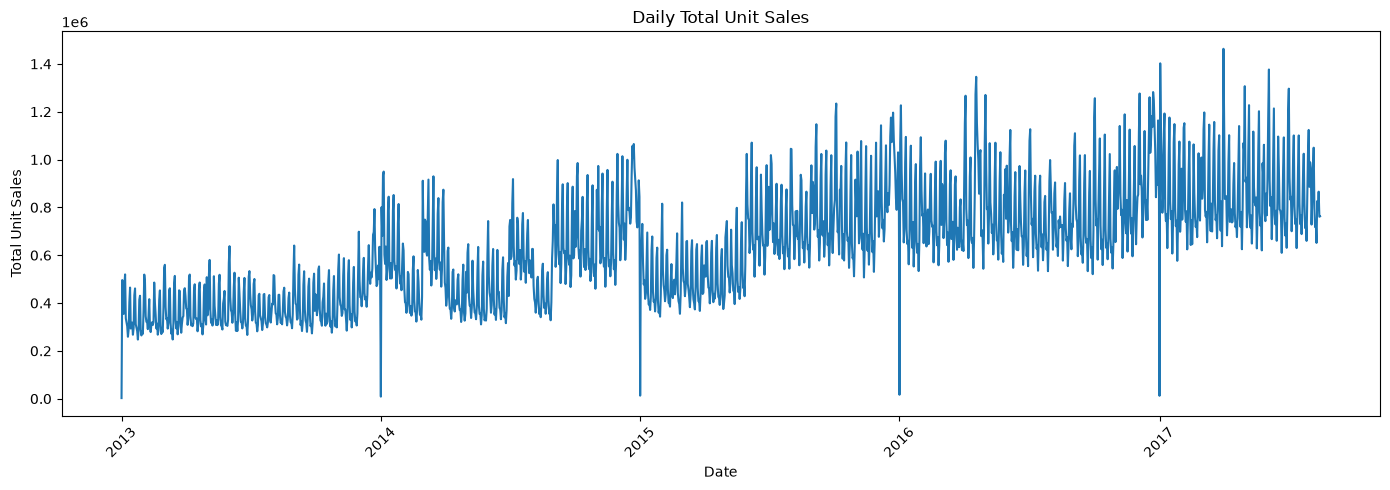

In [3]:
# Time Series - đọc train.csv theo chunks để tiết kiệm RAM

chunk_size = 100_000
daily_sales = []

for chunk in pd.read_csv(
    "../data/raw/train.csv",
    usecols=["date", "unit_sales"],
    chunksize=chunk_size
):
    # Tổng unit_sales theo ngày trong từng chunk
    chunk_daily = (
        chunk.groupby("date", as_index=False)["unit_sales"]
             .sum()
    )
    
    daily_sales.append(chunk_daily)

# Gộp kết quả từ tất cả các chunks
df_ts = (
    pd.concat(daily_sales, ignore_index=True)
      .groupby("date", as_index=False)["unit_sales"]
      .sum()
      .sort_values("date")
)

# Chuyển date sang datetime
df_ts["date"] = pd.to_datetime(df_ts["date"])

print(f"Số ngày: {len(df_ts)}")
print(f"Khoảng thời gian: {df_ts['date'].min().date()} → {df_ts['date'].max().date()}")

# Vẽ time series
plt.figure(figsize=(14, 5))

plt.plot(
    df_ts["date"],
    df_ts["unit_sales"]
)

plt.title("Daily Total Unit Sales")
plt.xlabel("Date")
plt.ylabel("Total Unit Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

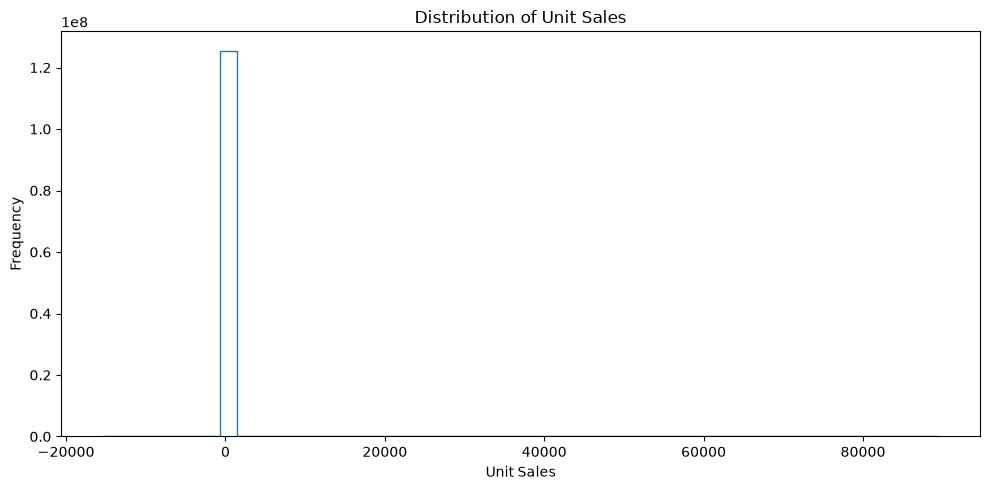

In [4]:
# Histogram - tính theo chunks

chunk_size = 100_000
bins = 50

# Tìm min/max
min_sales = float("inf")
max_sales = float("-inf")

for chunk in pd.read_csv(
    "../data/raw/train.csv",
    usecols=["unit_sales"],
    chunksize=chunk_size
):
    min_sales = min(min_sales, chunk["unit_sales"].min())
    max_sales = max(max_sales, chunk["unit_sales"].max())

# Tạo bin
bin_edges = np.linspace(min_sales, max_sales, bins + 1)

# Lưu số lượng quan sát trong mỗi bin
hist_counts = np.zeros(bins, dtype=np.int64)

# Tính histogram theo từng chunk
for chunk in pd.read_csv(
    "../data/raw/train.csv",
    usecols=["unit_sales"],
    chunksize=chunk_size
):
    counts, _ = np.histogram(
        chunk["unit_sales"],
        bins=bin_edges
    )
    
    hist_counts += counts

# Vẽ histogram
plt.figure(figsize=(10, 5))

plt.stairs(
    hist_counts,
    bin_edges
)

plt.title("Distribution of Unit Sales")
plt.xlabel("Unit Sales")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

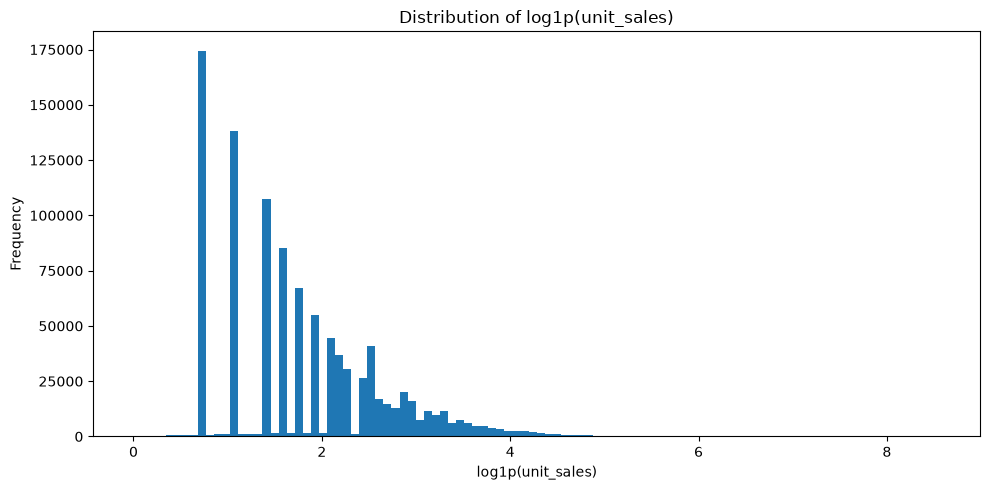

In [5]:
# Distribution của unit_sales trên log scale
import numpy as np
import matplotlib.pyplot as plt

sample_sales = []

reader = pd.read_csv(
    "../data/raw/train.csv",
    usecols=["unit_sales"],
    chunksize=100_000
)

for chunk in reader:
    sample_sales.append(
        chunk["unit_sales"].dropna()
    )

    if sum(len(x) for x in sample_sales) >= 1_000_000:
        break

sample_sales = pd.concat(
    sample_sales,
    ignore_index=True
)

log_sales = np.log1p(
    sample_sales.clip(lower=0)
)

plt.figure(figsize=(10, 5))
plt.hist(log_sales, bins=100)
plt.xlabel("log1p(unit_sales)")
plt.ylabel("Frequency")
plt.title("Distribution of log1p(unit_sales)")
plt.tight_layout()
plt.show()

In [6]:
# Kiểm tra phân phối của unit_sales theo chunks

chunk_size = 100_000

min_sales = float("inf")
max_sales = float("-inf")
total_rows = 0

for chunk in pd.read_csv(
    "../data/raw/train.csv",
    usecols=["unit_sales"],
    chunksize=chunk_size
):
    sales = chunk["unit_sales"]
    
    min_sales = min(min_sales, sales.min())
    max_sales = max(max_sales, sales.max())
    total_rows += len(sales)

print(f"Number of rows : {total_rows:,}")
print(f"Minimum        : {min_sales}")
print(f"Maximum        : {max_sales}")

Number of rows : 125,497,040
Minimum        : -15372.0
Maximum        : 89440.0


In [7]:
# Lấy sample từ từng chunk để ước lượng percentile
chunk_size = 100_000
sample_fraction = 0.01

samples = []

for chunk in pd.read_csv(
    "../data/raw/train.csv",
    usecols=["unit_sales"],
    chunksize=chunk_size
):
    samples.append(
        chunk["unit_sales"].sample(
            frac=sample_fraction,
            random_state=42
        )
    )

sales_sample = pd.concat(samples, ignore_index=True)

upper_limit = sales_sample.quantile(0.995)

print(f"Estimated 99.5th percentile: {upper_limit:.2f}")

Estimated 99.5th percentile: 100.00


In [8]:
# Tìm giá trị mất mát (Missing Values) theo chunks

chunk_size = 100_000

# Biến lưu tổng số missing của từng cột
missing_count = None

# Tổng số dòng của train.csv
total_rows = 0

# Đọc train.csv theo từng chunk
for chunk in pd.read_csv(
    "../data/raw/train.csv",
    chunksize=chunk_size
):
    # Đếm missing trong chunk hiện tại
    chunk_missing = chunk.isnull().sum()

    # Cộng dồn kết quả
    if missing_count is None:
        missing_count = chunk_missing
    else:
        missing_count += chunk_missing

    # Cộng số dòng
    total_rows += len(chunk)

# Tạo bảng tổng hợp
missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": (
        missing_count / total_rows * 100
    ).round(2)
})

# Chỉ giữ những cột có missing
missing_summary = (
    missing_summary[
        missing_summary["missing_count"] > 0
    ]
    .sort_values(
        "missing_count",
        ascending=False
    )
)

print(f"Total rows: {total_rows:,}")
print("\nMissing values:")

display(missing_summary)

if missing_summary.empty:
    print("No missing values found in train.csv.")

Total rows: 125,497,040

Missing values:


,missing_count,missing_percent
onpromotion,21657651,17.26


Heatmap shape (stores × months): (54, 56)
Tổng unit_sales: 1,073,610,269


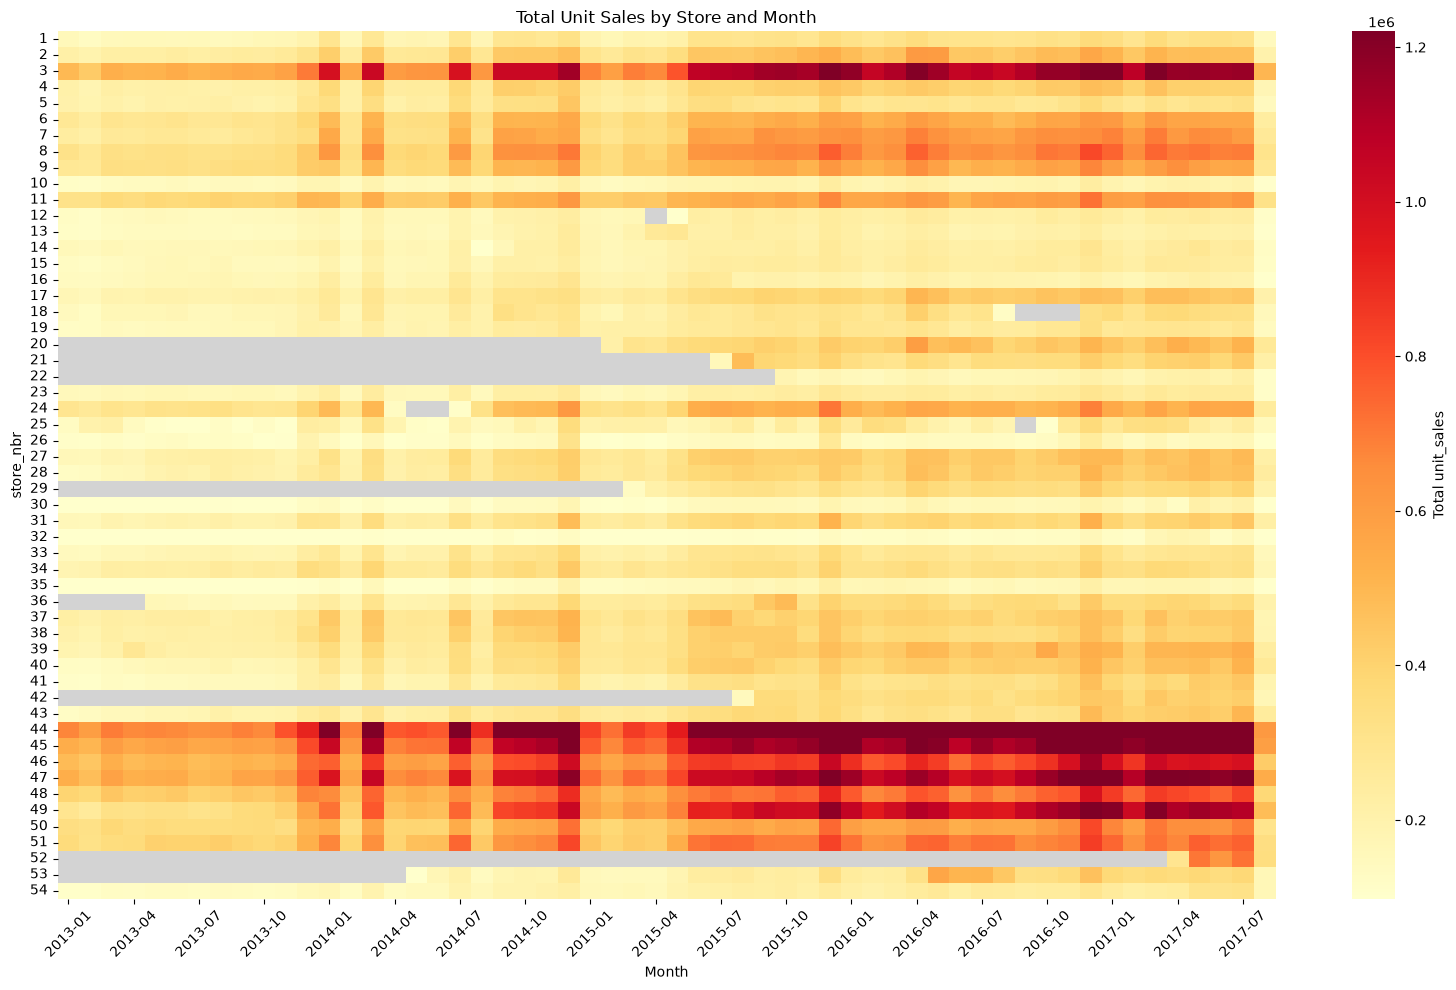

In [9]:
# Heatmap - train.csv: tổng unit_sales theo store_nbr × tháng
# Đọc train.csv theo chunks, chỉ giữ 3 cột cần thiết để tiết kiệm RAM

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

chunk_size = 100_000
partials = []

for chunk in pd.read_csv(
    "../data/raw/train.csv",
    usecols=["date", "store_nbr", "unit_sales"],
    chunksize=chunk_size
):
    # "2013-01-05" -> "2013-01" (nhanh hơn to_datetime trên 125M dòng)
    chunk["month"] = chunk["date"].str[:7]

    partials.append(
        chunk.groupby(["store_nbr", "month"], as_index=False)["unit_sales"]
             .sum()
    )

# Gộp kết quả từ tất cả các chunks
df_heat = (
    pd.concat(partials, ignore_index=True)
      .groupby(["store_nbr", "month"], as_index=False)["unit_sales"]
      .sum()
)

heat_train = df_heat.pivot(
    index="store_nbr",
    columns="month",
    values="unit_sales"
)

print(f"Heatmap shape (stores × months): {heat_train.shape}")
print(f"Tổng unit_sales: {heat_train.sum().sum():,.0f}")

# Vẽ heatmap
fig, ax = plt.subplots(figsize=(16, 10))

sns.heatmap(
    heat_train,
    cmap="YlOrRd",
    robust=True,            # dùng percentile 2–98 để outlier không làm nhạt cả biểu đồ
    xticklabels=3,          # hiện nhãn mỗi 3 tháng
    cbar_kws={"label": "Total unit_sales"},
    ax=ax
)

ax.set_facecolor("lightgrey")   # ô xám = store chưa có dữ liệu trong tháng đó
ax.set_title("Total Unit Sales by Store and Month")
ax.set_xlabel("Month")
ax.set_ylabel("store_nbr")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

chunk_size = 500_000
partials = []

# Đọc toàn bộ train.csv theo chunks
for chunk in pd.read_csv(
    "../data/raw/train.csv",
    usecols=["date", "store_nbr", "unit_sales"],
    chunksize=chunk_size,
):
    chunk["month"] = chunk["date"].str[:7]

    partial = (
        chunk.groupby(["store_nbr", "month"], as_index=False)["unit_sales"]
        .sum()
    )

    partials.append(partial)

# Gộp kết quả giữa các chunk
df_heat = (
    pd.concat(partials, ignore_index=True)
    .groupby(["store_nbr", "month"], as_index=False)["unit_sales"]
    .sum()
)

# Pivot: store × month
heat_train = df_heat.pivot(
    index="store_nbr",
    columns="month",
    values="unit_sales"
)

# Format số
heat_train_formatted = (
    heat_train
    .map(lambda x: f"{x:,.0f}" if pd.notnull(x) else "-")
    .reset_index()
    .rename(columns={"store_nbr": "Store / Month"})
)

heat_train_formatted.columns.name = None

# Tự tạo Markdown table, không cần tabulate
headers = heat_train_formatted.columns.tolist()

md_lines = []

# Header
md_lines.append("| " + " | ".join(map(str, headers)) + " |")

# Separator
md_lines.append(
    "| " + " | ".join(["---"] * len(headers)) + " |"
)

# Rows
for row in heat_train_formatted.itertuples(index=False, name=None):
    md_lines.append(
        "| " + " | ".join(map(str, row)) + " |"
    )

md_table = "\n".join(md_lines)

# Xuất file Markdown
output_path = "heatmap_unit_sales.md"

with open(output_path, "w", encoding="utf-8") as f:
    f.write("# Total Unit Sales by Store and Month\n\n")
    f.write(f"- **Tổng số cửa hàng:** {heat_train.shape[0]}\n")
    f.write(f"- **Số tháng:** {heat_train.shape[1]}\n")
    f.write(f"- **Tổng unit_sales:** {heat_train.sum().sum():,.0f}\n\n")
    f.write(md_table)

print(f"Đã lưu bảng heatmap vào file: {output_path}")

# Hiển thị 10 store × 10 tháng đầu tiên
preview = heat_train_formatted.iloc[:10, :10]

preview_headers = preview.columns.tolist()

preview_lines = [
    "| " + " | ".join(map(str, preview_headers)) + " |",
    "| " + " | ".join(["---"] * len(preview_headers)) + " |"
]

for row in preview.itertuples(index=False, name=None):
    preview_lines.append(
        "| " + " | ".join(map(str, row)) + " |"
    )

display(
    Markdown(
        "\n".join(preview_lines)
        + "\n\n*(Hiển thị mẫu 10 store × 10 tháng đầu tiên trên notebook)*"
    )
)

Đã lưu bảng heatmap vào file: heatmap_unit_sales.md


| Store / Month | 2013-01 | 2013-02 | 2013-03 | 2013-04 | 2013-05 | 2013-06 | 2013-07 | 2013-08 | 2013-09 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 1 | 156,864 | 129,814 | 151,666 | 155,848 | 154,966 | 154,051 | 156,757 | 149,183 | 152,075 |
| 2 | 218,535 | 195,285 | 229,065 | 225,229 | 228,265 | 239,086 | 229,390 | 234,817 | 250,349 |
| 3 | 496,574 | 429,619 | 531,686 | 512,072 | 518,197 | 544,388 | 517,336 | 532,538 | 553,040 |
| 4 | 209,296 | 183,875 | 222,347 | 208,460 | 214,307 | 219,864 | 211,088 | 205,759 | 216,418 |
| 5 | 206,885 | 189,681 | 211,222 | 198,402 | 215,297 | 209,828 | 213,844 | 223,534 | 203,217 |
| 6 | 277,175 | 241,864 | 296,197 | 282,872 | 290,726 | 299,640 | 281,006 | 278,803 | 301,429 |
| 7 | 241,522 | 219,497 | 265,404 | 263,721 | 274,149 | 275,549 | 261,549 | 253,880 | 277,449 |
| 8 | 315,457 | 274,554 | 330,302 | 320,261 | 329,159 | 331,005 | 319,031 | 320,113 | 331,419 |
| 9 | 275,783 | 270,773 | 335,130 | 331,207 | 327,241 | 338,970 | 322,130 | 339,127 | 353,910 |
| 10 | 115,863 | 111,732 | 131,225 | 138,870 | 140,866 | 146,942 | 135,711 | 144,899 | 142,392 |

*(Hiển thị mẫu 10 store × 10 tháng đầu tiên trên notebook)*

## Transaction.csv

In [11]:
df = pd.read_csv("../data/raw/transactions.csv", nrows=5000)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (5000, 3)


,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


Number of stores: 54
Date range: 2013-01-01 → 2017-08-15


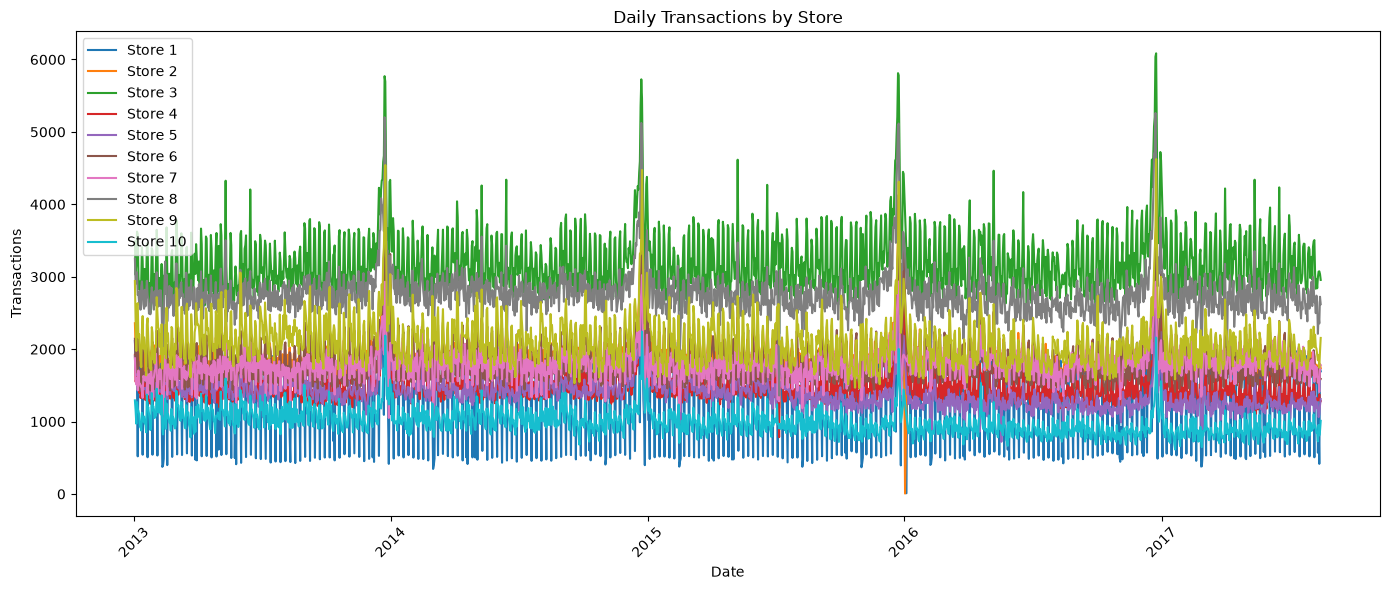

In [12]:
# Time Series - Transactions theo store_nbr
# Đọc transactions.csv theo chunks để tiết kiệm RAM

chunk_size = 100_000

daily_store = []

for chunk in pd.read_csv(
    "../data/raw/transactions.csv",
    usecols=["date", "store_nbr", "transactions"],
    chunksize=chunk_size
):
    chunk["date"] = pd.to_datetime(chunk["date"])

    # Tổng transactions theo ngày và store
    chunk_daily = (
        chunk.groupby(["date", "store_nbr"], as_index=False)["transactions"]
             .sum()
    )

    daily_store.append(chunk_daily)

# Gộp các chunks
df_ts_store = (
    pd.concat(daily_store, ignore_index=True)
      .groupby(["date", "store_nbr"], as_index=False)["transactions"]
      .sum()
      .sort_values(["date", "store_nbr"])
)

print(f"Number of stores: {df_ts_store['store_nbr'].nunique()}")
print(f"Date range: {df_ts_store['date'].min().date()} → {df_ts_store['date'].max().date()}")

# Chọn một số store để quan sát
stores_to_plot = sorted(
    df_ts_store["store_nbr"].unique()
)[:10]

plt.figure(figsize=(14, 6))

for store in stores_to_plot:
    store_data = df_ts_store[
        df_ts_store["store_nbr"] == store
    ]

    plt.plot(
        store_data["date"],
        store_data["transactions"],
        label=f"Store {store}"
    )

plt.title("Daily Transactions by Store")
plt.xlabel("Date")
plt.ylabel("Transactions")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Minimum transactions: 5
Maximum transactions: 8359


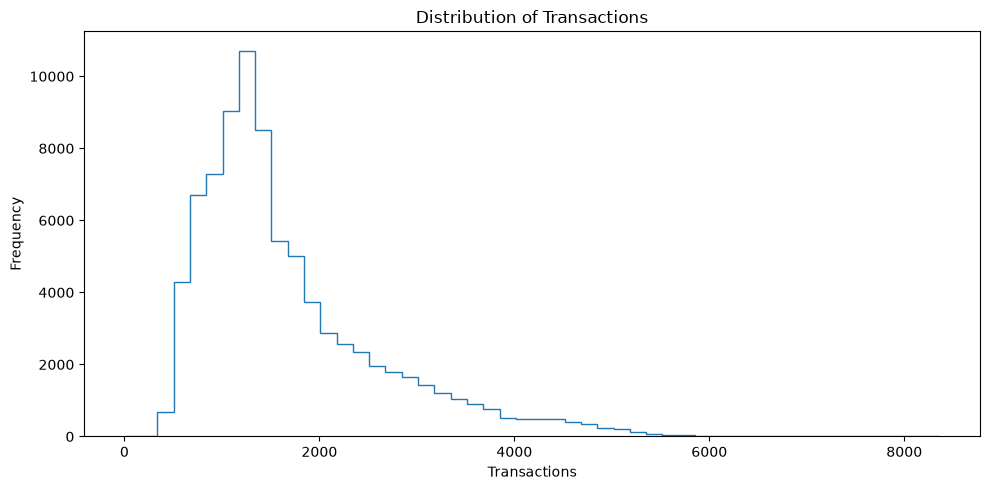

In [13]:
# Histogram - Transactions
# Tính histogram theo chunks, không giữ toàn bộ dữ liệu trong RAM

chunk_size = 100_000
bins = 50

# Tìm min/max
min_transactions = float("inf")
max_transactions = float("-inf")

for chunk in pd.read_csv(
    "../data/raw/transactions.csv",
    usecols=["transactions"],
    chunksize=chunk_size
):
    min_transactions = min(
        min_transactions,
        chunk["transactions"].min()
    )

    max_transactions = max(
        max_transactions,
        chunk["transactions"].max()
    )

print(f"Minimum transactions: {min_transactions}")
print(f"Maximum transactions: {max_transactions}")

# Tạo các bin
bin_edges = np.linspace(
    min_transactions,
    max_transactions,
    bins + 1
)

hist_counts = np.zeros(
    bins,
    dtype=np.int64
)

# Tính histogram theo từng chunk
for chunk in pd.read_csv(
    "../data/raw/transactions.csv",
    usecols=["transactions"],
    chunksize=chunk_size
):
    counts, _ = np.histogram(
        chunk["transactions"],
        bins=bin_edges
    )

    hist_counts += counts

# Vẽ histogram
plt.figure(figsize=(10, 5))

plt.stairs(
    hist_counts,
    bin_edges
)

plt.title("Distribution of Transactions")
plt.xlabel("Transactions")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [14]:
# Missing Values - transactions.csv
# Đọc file theo chunks để tiết kiệm RAM

chunk_size = 100_000

missing_count = None
total_rows = 0

for chunk in pd.read_csv(
    "../data/raw/transactions.csv",
    chunksize=chunk_size
):
    # Đếm missing trong chunk hiện tại
    chunk_missing = chunk.isnull().sum()

    # Cộng dồn missing
    if missing_count is None:
        missing_count = chunk_missing
    else:
        missing_count += chunk_missing

    total_rows += len(chunk)

# Tạo bảng tổng hợp
missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": (
        missing_count / total_rows * 100
    ).round(2)
})

# Chỉ hiển thị các cột có missing
missing_summary = (
    missing_summary[
        missing_summary["missing_count"] > 0
    ]
    .sort_values(
        "missing_count",
        ascending=False
    )
)

print(f"Total rows: {total_rows:,}")
print("\nMissing values:")

display(missing_summary)

if missing_summary.empty:
    print("No missing values found in transactions.csv.")

Total rows: 83,488

Missing values:


,missing_count,missing_percent


No missing values found in transactions.csv.


Heatmap shape (stores × months): (54, 56)


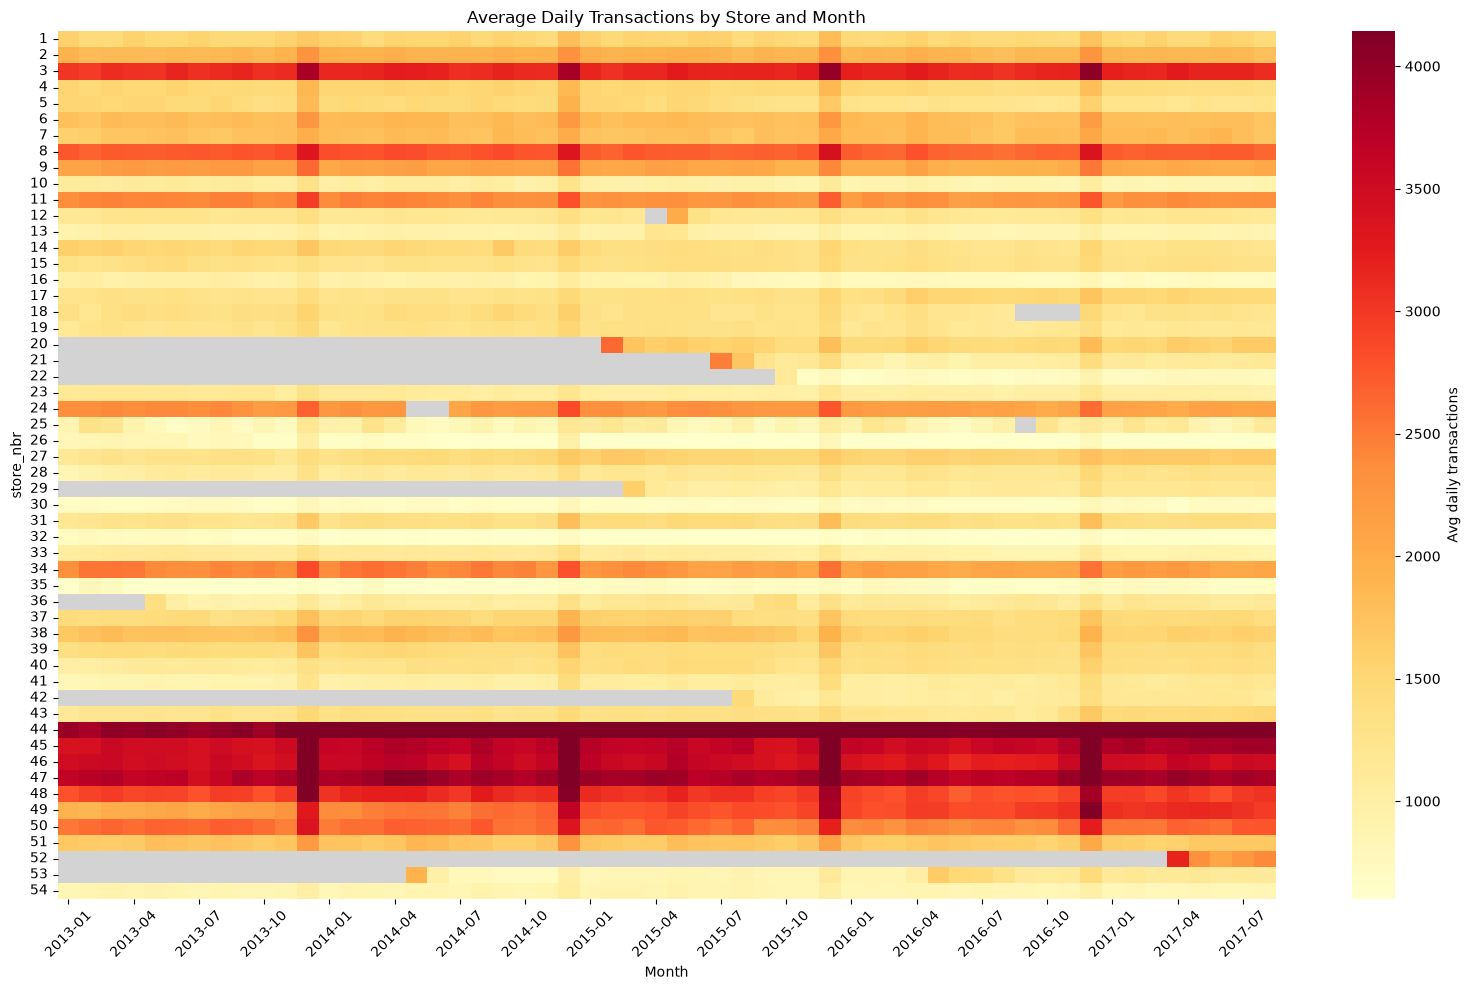

In [15]:
# Heatmap - transactions.csv: transactions trung bình / ngày theo store_nbr × tháng
# Đọc theo chunks; tính trung bình = tổng / số ngày để đúng khi 1 tháng bị chia qua nhiều chunk

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

chunk_size = 100_000
partials = []

for chunk in pd.read_csv(
    "../data/raw/transactions.csv",
    usecols=["date", "store_nbr", "transactions"],
    chunksize=chunk_size
):
    chunk["month"] = chunk["date"].str[:7]

    partials.append(
        chunk.groupby(["store_nbr", "month"])["transactions"]
             .agg(total="sum", n_days="size")
             .reset_index()
    )

df_heat = (
    pd.concat(partials, ignore_index=True)
      .groupby(["store_nbr", "month"], as_index=False)[["total", "n_days"]]
      .sum()
)

df_heat["avg_transactions"] = df_heat["total"] / df_heat["n_days"]

heat_trans = df_heat.pivot(
    index="store_nbr",
    columns="month",
    values="avg_transactions"
)

print(f"Heatmap shape (stores × months): {heat_trans.shape}")

fig, ax = plt.subplots(figsize=(16, 10))

sns.heatmap(
    heat_trans,
    cmap="YlOrRd",
    robust=True,
    xticklabels=3,
    cbar_kws={"label": "Avg daily transactions"},
    ax=ax
)

ax.set_facecolor("lightgrey")
ax.set_title("Average Daily Transactions by Store and Month")
ax.set_xlabel("Month")
ax.set_ylabel("store_nbr")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
# Transactions - Average daily transactions by store × month
# Đọc toàn bộ transactions.csv theo chunks
# Tính average = tổng transactions / số ngày có dữ liệu

import pandas as pd
from IPython.display import Markdown, display

chunk_size = 100_000
partials = []

# ============================================================
# 1. Đọc dữ liệu theo chunks
# ============================================================

for chunk in pd.read_csv(
    "../data/raw/transactions.csv",
    usecols=["date", "store_nbr", "transactions"],
    chunksize=chunk_size
):
    chunk["month"] = chunk["date"].str[:7]

    partial = (
        chunk
        .groupby(["store_nbr", "month"])["transactions"]
        .agg(
            total="sum",
            n_days="size"
        )
        .reset_index()
    )

    partials.append(partial)


# ============================================================
# 2. Gộp kết quả giữa các chunks
# ============================================================

df_heat = (
    pd.concat(partials, ignore_index=True)
    .groupby(
        ["store_nbr", "month"],
        as_index=False
    )[["total", "n_days"]]
    .sum()
)

# Average transactions / day
df_heat["avg_transactions"] = (
    df_heat["total"] / df_heat["n_days"]
)


# ============================================================
# 3. Pivot thành Store × Month
# ============================================================

heat_trans = df_heat.pivot(
    index="store_nbr",
    columns="month",
    values="avg_transactions"
)

print(
    f"Heatmap shape (stores × months): "
    f"{heat_trans.shape}"
)


# ============================================================
# 4. Format số để hiển thị dạng bảng
# ============================================================

heat_trans_formatted = (
    heat_trans
    .map(
        lambda x:
            f"{x:,.2f}" if pd.notnull(x) else "-"
    )
    .reset_index()
    .rename(columns={
        "store_nbr": "Store / Month"
    })
)

# Bỏ tên index của columns
heat_trans_formatted.columns.name = None


# ============================================================
# 5. Tạo Markdown table
# Không cần package tabulate
# ============================================================

headers = heat_trans_formatted.columns.tolist()

md_lines = []

# Header
md_lines.append(
    "| " + " | ".join(map(str, headers)) + " |"
)

# Separator
md_lines.append(
    "| " + " | ".join(["---"] * len(headers)) + " |"
)

# Data
for row in heat_trans_formatted.itertuples(
    index=False,
    name=None
):
    md_lines.append(
        "| " + " | ".join(map(str, row)) + " |"
    )

md_table = "\n".join(md_lines)


# ============================================================
# 6. Xuất file Markdown
# ============================================================

output_path = "heatmap_transactions.md"

with open(
    output_path,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "# Average Daily Transactions by Store and Month\n\n"
    )

    f.write(
        f"- **Tổng số cửa hàng:** "
        f"{heat_trans.shape[0]}\n"
    )

    f.write(
        f"- **Số tháng:** "
        f"{heat_trans.shape[1]}\n"
    )

    f.write(
        f"- **Tổng transactions:** "
        f"{df_heat['total'].sum():,.0f}\n\n"
    )

    f.write(md_table)


print(
    f"Đã lưu bảng heatmap vào file: "
    f"{output_path}"
)


# ============================================================
# 7. Hiển thị trực tiếp trong Notebook
# ============================================================

display(
    Markdown(md_table)
)

Heatmap shape (stores × months): (54, 56)
Đã lưu bảng heatmap vào file: heatmap_transactions.md


| Store / Month | 2013-01 | 2013-02 | 2013-03 | 2013-04 | 2013-05 | 2013-06 | 2013-07 | 2013-08 | 2013-09 | 2013-10 | 2013-11 | 2013-12 | 2014-01 | 2014-02 | 2014-03 | 2014-04 | 2014-05 | 2014-06 | 2014-07 | 2014-08 | 2014-09 | 2014-10 | 2014-11 | 2014-12 | 2015-01 | 2015-02 | 2015-03 | 2015-04 | 2015-05 | 2015-06 | 2015-07 | 2015-08 | 2015-09 | 2015-10 | 2015-11 | 2015-12 | 2016-01 | 2016-02 | 2016-03 | 2016-04 | 2016-05 | 2016-06 | 2016-07 | 2016-08 | 2016-09 | 2016-10 | 2016-11 | 2016-12 | 2017-01 | 2017-02 | 2017-03 | 2017-04 | 2017-05 | 2017-06 | 2017-07 | 2017-08 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 1 | 1,582.37 | 1,449.54 | 1,461.26 | 1,558.00 | 1,493.10 | 1,495.87 | 1,544.32 | 1,477.06 | 1,484.67 | 1,497.55 | 1,559.43 | 1,670.33 | 1,580.57 | 1,564.96 | 1,429.39 | 1,534.50 | 1,523.39 | 1,522.67 | 1,556.55 | 1,486.00 | 1,547.13 | 1,501.13 | 1,434.57 | 1,784.40 | 1,576.73 | 1,481.18 | 1,541.74 | 1,537.97 | 1,510.90 | 1,595.67 | 1,573.00 | 1,440.52 | 1,539.40 | 1,478.55 | 1,429.87 | 1,814.37 | 1,484.71 | 1,470.79 | 1,491.74 | 1,559.03 | 1,464.03 | 1,520.30 | 1,459.94 | 1,448.87 | 1,496.63 | 1,471.77 | 1,441.37 | 1,736.33 | 1,514.70 | 1,459.57 | 1,565.48 | 1,446.53 | 1,465.35 | 1,582.63 | 1,530.87 | 1,426.33 |
| 2 | 1,919.60 | 1,831.04 | 1,833.84 | 1,839.60 | 1,830.26 | 1,853.57 | 1,838.29 | 1,851.94 | 1,889.10 | 1,838.97 | 1,923.60 | 2,295.97 | 1,943.80 | 1,924.07 | 1,928.90 | 1,960.80 | 1,905.87 | 1,913.53 | 1,903.10 | 1,905.35 | 1,958.30 | 1,919.81 | 1,936.67 | 2,325.73 | 1,963.20 | 1,908.86 | 1,935.45 | 1,928.17 | 1,952.52 | 1,946.33 | 1,901.87 | 1,845.71 | 1,909.07 | 1,881.35 | 1,892.20 | 2,351.97 | 1,871.39 | 1,900.72 | 1,879.87 | 1,984.07 | 1,911.81 | 1,898.10 | 1,823.42 | 1,780.26 | 1,865.47 | 1,854.26 | 1,846.63 | 2,286.53 | 1,897.90 | 1,864.64 | 1,876.00 | 1,864.87 | 1,870.13 | 1,882.97 | 1,848.90 | 1,772.93 |
| 3 | 3,031.53 | 2,969.11 | 3,092.97 | 3,051.90 | 3,039.06 | 3,161.83 | 3,076.90 | 3,107.19 | 3,173.30 | 3,076.03 | 3,117.97 | 3,834.77 | 3,143.97 | 3,137.43 | 3,165.61 | 3,234.10 | 3,228.48 | 3,190.93 | 3,090.52 | 3,093.10 | 3,178.67 | 3,119.58 | 3,109.87 | 3,864.87 | 3,167.43 | 3,062.32 | 3,154.81 | 3,154.33 | 3,242.94 | 3,181.00 | 3,169.81 | 3,183.81 | 3,175.47 | 3,151.61 | 3,237.77 | 3,968.33 | 3,205.26 | 3,170.48 | 3,160.97 | 3,256.47 | 3,174.81 | 3,103.30 | 3,114.52 | 3,042.68 | 3,109.27 | 3,161.35 | 3,185.47 | 4,026.77 | 3,214.33 | 3,163.07 | 3,142.55 | 3,246.80 | 3,184.42 | 3,185.20 | 3,183.68 | 3,101.47 |
| 4 | 1,531.33 | 1,470.75 | 1,539.10 | 1,499.90 | 1,499.65 | 1,555.33 | 1,490.65 | 1,464.74 | 1,475.47 | 1,451.65 | 1,470.47 | 1,861.60 | 1,516.97 | 1,523.29 | 1,502.74 | 1,557.87 | 1,537.03 | 1,542.97 | 1,486.39 | 1,521.35 | 1,563.93 | 1,509.74 | 1,486.00 | 1,853.87 | 1,530.47 | 1,494.71 | 1,508.19 | 1,492.93 | 1,526.48 | 1,514.40 | 1,443.35 | 1,448.23 | 1,485.07 | 1,459.61 | 1,468.63 | 1,854.00 | 1,517.07 | 1,474.52 | 1,496.19 | 1,501.73 | 1,434.06 | 1,420.50 | 1,418.77 | 1,373.06 | 1,414.60 | 1,422.81 | 1,433.33 | 1,797.70 | 1,458.37 | 1,455.89 | 1,432.39 | 1,411.83 | 1,381.90 | 1,389.40 | 1,397.19 | 1,338.07 |
| 5 | 1,511.83 | 1,505.86 | 1,495.42 | 1,500.13 | 1,510.19 | 1,463.07 | 1,446.90 | 1,517.81 | 1,438.97 | 1,358.10 | 1,403.50 | 1,838.23 | 1,452.03 | 1,494.54 | 1,451.26 | 1,392.80 | 1,492.58 | 1,448.20 | 1,448.42 | 1,510.23 | 1,466.57 | 1,442.35 | 1,454.83 | 1,930.13 | 1,534.03 | 1,502.96 | 1,491.26 | 1,406.80 | 1,508.10 | 1,474.27 | 1,414.00 | 1,338.61 | 1,294.97 | 1,275.71 | 1,270.13 | 1,652.77 | 1,277.46 | 1,263.90 | 1,252.74 | 1,236.33 | 1,282.71 | 1,263.40 | 1,264.94 | 1,249.35 | 1,228.10 | 1,182.48 | 1,217.33 | 1,564.57 | 1,253.03 | 1,254.54 | 1,249.61 | 1,196.80 | 1,251.97 | 1,231.10 | 1,233.77 | 1,252.80 |
| 6 | 1,763.40 | 1,718.14 | 1,826.00 | 1,778.13 | 1,793.94 | 1,842.83 | 1,773.74 | 1,778.97 | 1,823.53 | 1,771.77 | 1,795.30 | 2,263.93 | 1,825.37 | 1,838.64 | 1,835.13 | 1,883.13 | 1,866.71 | 1,872.77 | 1,773.42 | 1,803.35 | 1,852.97 | 1,803.65 | 1,818.80 | 2,222.77 | 1,849.03 | 1,769.36 | 1,818.90 | 1,825.17 | 1,848.29 | 1,807.43 | 1,786.71 | 1,762.42 | 1,788.87 | 1,762.87 | 1,770.40 | 2,238.70 | 1,848.59 | 1,811.28 | 1,810.87 | 1,891.23 | 1,816.87 | 1,785.67 | 1,758.10 | 1,683.55 | 1,741.37 | 1,750.90 | 1,753.60 | 2,178.77 | 1,802.90 | 1,798.25 | 1,763.03 | 1,794.37 | 1,773.68 | 1,792.20 | 1,781.52 | 1,707.93 |
| 7 | 1,575.90 | 1,614.68 | 1,696.35 | 1,720.90 | 1,742.48 | 1,763.97 | 1,708.35 | 1,672.58 | 1,760.33 | 1,762.19 | 1,791.90 | 1,973.50 | 1,812.83 | 1,795.32 | 1,771.42 | 1,845.80 | 1,807.58 | 1,823.47 | 1,751.65 | 1,734.52 | 1,870.17 | 1,813.61 | 1,763.80 | 2,012.03 | 1,745.03 | 1,697.68 | 1,726.13 | 1,773.30 | 1,770.42 | 1,778.67 | 1,703.55 | 1,645.16 | 1,801.83 | 1,740.39 | 1,760.33 | 2,041.30 | 1,818.70 | 1,819.41 | 1,780.35 | 1,897.13 | 1,810.03 | 1,808.30 | 1,732.84 | 1,693.13 | 1,806.93 | 1,807.84 | 1,791.60 | 2,055.27 | 1,825.23 | 1,827.93 | 1,859.35 | 1,803.90 | 1,836.48 | 1,896.60 | 1,792.94 | 1,706.27 |
| 8 | 2,748.90 | 2,662.86 | 2,736.19 | 2,719.47 | 2,710.23 | 2,737.27 | 2,747.84 | 2,743.26 | 2,783.80 | 2,755.58 | 2,821.73 | 3,336.60 | 2,826.00 | 2,797.39 | 2,782.90 | 2,850.57 | 2,817.00 | 2,745.20 | 2,741.55 | 2,789.58 | 2,848.03 | 2,770.52 | 2,749.20 | 3,338.20 | 2,724.77 | 2,673.64 | 2,765.52 | 2,727.77 | 2,716.71 | 2,706.90 | 2,647.61 | 2,671.55 | 2,699.93 | 2,671.61 | 2,733.30 | 3,402.67 | 2,724.00 | 2,657.31 | 2,628.03 | 2,788.00 | 2,665.32 | 2,622.13 | 2,618.68 | 2,570.81 | 2,623.33 | 2,669.58 | 2,657.03 | 3,365.83 | 2,730.83 | 2,687.68 | 2,712.10 | 2,696.63 | 2,703.19 | 2,731.10 | 2,727.35 | 2,643.80 |
| 9 | 2,104.57 | 2,101.64 | 2,199.32 | 2,224.13 | 2,179.26 | 2,208.83 | 2,179.65 | 2,220.06 | 2,222.67 | 2,147.77 | 2,146.43 | 2,626.23 | 2,035.10 | 2,114.86 | 2,108.35 | 2,155.90 | 2,164.10 | 2,087.40 | 2,075.71 | 2,133.55 | 2,119.30 | 2,074.16 | 2,079.60 | 2,562.50 | 2,077.27 | 2,051.00 | 2,063.77 | 2,155.00 | 2,131.52 | 2,052.77 | 2,036.16 | 2,067.35 | 2,049.73 | 1,916.52 | 1,906.97 | 2,407.13 | 1,965.96 | 1,981.24 | 1,970.74 | 2,145.27 | 1,971.45 | 1,913.57 | 1,916.55 | 1,931.32 | 1,952.07 | 1,937.42 | 1,999.13 | 2,517.77 | 2,028.07 | 2,021.46 | 1,994.39 | 2,052.40 | 2,001.77 | 1,971.40 | 1,962.74 | 2,040.33 |
| 10 | 1,085.63 | 1,086.50 | 1,062.58 | 1,103.30 | 1,089.58 | 1,120.07 | 1,072.35 | 1,087.32 | 1,103.47 | 1,049.42 | 1,036.67 | 1,283.87 | 1,021.23 | 1,052.36 | 1,015.52 | 1,071.70 | 1,061.58 | 1,060.37 | 1,021.26 | 1,063.00 | 1,046.93 | 944.81 | 1,007.03 | 1,270.27 | 1,003.70 | 974.54 | 945.87 | 985.23 | 991.68 | 986.37 | 945.94 | 969.00 | 971.70 | 901.58 | 885.20 | 1,109.80 | 881.26 | 898.21 | 901.03 | 969.93 | 912.26 | 868.97 | 846.23 | 872.06 | 879.13 | 850.97 | 829.20 | 1,069.33 | 844.90 | 850.43 | 844.13 | 884.87 | 873.68 | 868.63 | 876.45 | 907.47 |
| 11 | 2,370.83 | 2,416.93 | 2,446.35 | 2,414.57 | 2,435.97 | 2,413.23 | 2,389.45 | 2,457.74 | 2,458.30 | 2,381.45 | 2,407.97 | 2,964.57 | 2,378.53 | 2,474.96 | 2,440.06 | 2,463.97 | 2,431.03 | 2,394.73 | 2,335.48 | 2,435.23 | 2,365.37 | 2,307.48 | 2,335.23 | 2,810.30 | 2,288.03 | 2,312.86 | 2,278.65 | 2,318.80 | 2,357.68 | 2,246.87 | 2,271.45 | 2,344.77 | 2,282.27 | 2,224.65 | 2,187.03 | 2,716.73 | 2,167.52 | 2,332.45 | 2,262.52 | 2,360.23 | 2,324.10 | 2,156.13 | 2,184.94 | 2,242.68 | 2,271.07 | 2,222.52 | 2,274.53 | 2,759.03 | 2,218.07 | 2,341.14 | 2,328.19 | 2,395.20 | 2,357.29 | 2,296.70 | 2,324.90 | 2,351.20 |
| 12 | 1,164.63 | 1,193.50 | 1,240.32 | 1,251.57 | 1,250.10 | 1,252.27 | 1,249.87 | 1,202.81 | 1,235.87 | 1,216.16 | 1,229.50 | 1,350.53 | 1,156.43 | 1,177.71 | 1,188.00 | 1,235.73 | 1,199.00 | 1,196.30 | 1,184.23 | 1,149.39 | 1,178.40 | 1,179.74 | 1,215.77 | 1,353.43 | 1,204.70 | 1,210.93 | 1,192.72 | - | 2,014.67 | 1,299.53 | 1,199.87 | 1,183.45 | 1,159.60 | 1,185.13 | 1,171.07 | 1,353.57 | 1,227.70 | 1,220.86 | 1,208.23 | 1,280.07 | 1,235.48 | 1,178.57 | 1,151.32 | 1,118.26 | 1,136.23 | 1,151.29 | 1,175.10 | 1,323.40 | 1,177.77 | 1,197.43 | 1,168.55 | 1,215.57 | 1,219.84 | 1,214.60 | 1,191.32 | 1,152.60 |
| 13 | 913.43 | 938.29 | 989.68 | 990.03 | 982.84 | 983.00 | 974.55 | 949.68 | 943.93 | 927.39 | 943.80 | 1,066.40 | 909.73 | 930.46 | 950.06 | 978.93 | 954.45 | 936.83 | 931.26 | 932.42 | 916.27 | 930.87 | 946.27 | 1,097.57 | 932.77 | 942.36 | 954.52 | 1,225.07 | 1,208.61 | 961.00 | 935.71 | 941.10 | 901.70 | 873.35 | 852.10 | 996.10 | 879.78 | 891.03 | 893.84 | 934.27 | 905.61 | 851.90 | 862.32 | 845.90 | 868.83 | 871.94 | 873.10 | 1,001.80 | 860.37 | 889.18 | 867.77 | 919.03 | 902.74 | 873.43 | 891.77 | 876.13 |
| 14 | 1,586.37 | 1,548.43 | 1,577.26 | 1,520.30 | 1,492.00 | 1,510.93 | 1,484.87 | 1,441.61 | 1,516.07 | 1,487.39 | 1,486.10 | 1,702.90 | 1,483.03 | 1,469.14 | 1,457.68 | 1,501.47 | 1,472.58 | 1,440.47 | 1,437.71 | 1,390.00 | 1,661.25 | 1,434.19 | 1,413.20 | 1,629.20 | 1,419.77 | 1,347.68 | 1,350.13 | 1,365.43 | 1,404.10 | 1,377.83 | 1,337.32 | 1,328.39 | 1,362.97 | 1,306.71 | 1,268.13 | 1,521.77 | 1,324.89 | 1,300.93 | 1,280.81 | 1,375.47 | 1,299.16 | 1,251.67 | 1,233.90 | 1,225.81 | 1,280.10 | 1,249.39 | 1,226.97 | 1,503.53 | 1,278.20 | 1,252.21 | 1,253.39 | 1,299.83 | 1,302.45 | 1,284.37 | 1,244.32 | 1,223.27 |
| 15 | 1,298.67 | 1,262.46 | 1,292.52 | 1,360.10 | 1,412.94 | 1,426.17 | 1,341.52 | 1,302.55 | 1,318.97 | 1,272.42 | 1,259.93 | 1,345.60 | 1,243.80 | 1,248.21 | 1,225.55 | 1,290.07 | 1,300.65 | 1,275.57 | 1,271.52 | 1,274.39 | 1,322.53 | 1,275.65 | 1,248.10 | 1,465.27 | 1,324.70 | 1,292.57 | 1,321.94 | 1,340.97 | 1,380.52 | 1,382.47 | 1,370.19 | 1,350.58 | 1,360.30 | 1,316.81 | 1,267.67 | 1,488.57 | 1,288.07 | 1,302.72 | 1,320.45 | 1,382.07 | 1,332.77 | 1,287.00 | 1,259.29 | 1,255.19 | 1,311.13 | 1,277.06 | 1,271.93 | 1,488.57 | 1,292.07 | 1,274.29 | 1,326.65 | 1,343.27 | 1,353.97 | 1,318.73 | 1,306.10 | 1,291.13 |
| 16 | 1,008.97 | 1,030.57 | 957.58 | 975.80 | 1,012.77 | 1,015.90 | 1,005.55 | 1,033.77 | 998.80 | 957.06 | 973.20 | 1,099.53 | 943.30 | 975.14 | 945.94 | 908.07 | 945.94 | 947.77 | 939.71 | 982.06 | 933.50 | 887.84 | 907.77 | 1,075.10 | 915.97 | 932.29 | 908.81 | 898.10 | 970.32 | 950.40 | 895.06 | 797.39 | 787.43 | 754.65 | 759.50 | 888.40 | 764.25 | 753.14 | 764.13 | 782.63 | 775.84 | 757.40 | 763.74 | 753.87 | 736.93 | 716.71 | 734.10 | 835.73 | 704.60 | 742.18 | 698.35 | 723.60 | 744.87 | 726.70 | 715.42 | 719.20 |
| 17 | 1,245.40 | 1,256.07 | 1,309.90 | 1,289.47 | 1,300.10 | 1,332.17 | 1,271.58 | 1,239.35 | 1,271.97 | 1,247.84 | 1,244.47 | 1,408.40 | 1,239.77 | 1,271.25 | 1,250.42 | 1,284.13 | 1,281.81 | 1,301.03 | 1,239.48 | 1,258.97 | 1,304.00 | 1,278.35 | 1,306.00 | 1,483.40 | 1,303.43 | 1,293.64 | 1,308.74 | 1,325.77 | 1,350.26 | 1,328.50 | 1,297.39 | 1,332.71 | 1,357.17 | 1,288.77 | 1,303.47 | 1,519.53 | 1,333.11 | 1,348.00 | 1,456.21 | 1,607.73 | 1,522.32 | 1,502.93 | 1,491.32 | 1,468.87 | 1,499.97 | 1,502.81 | 1,478.87 | 1,727.23 | 1,510.67 | 1,526.96 | 1,490.71 | 1,545.60 | 1,486.52 | 1,479.77 | 1,471.77 | 1,467.47 |
| 18 | 1,316.27 | 1,205.11 | 1,324.16 | 1,396.57 | 1,348.16 | 1,376.17 | 1,317.39 | 1,304.13 | 1,367.53 | 1,358.03 | 1,363.13 | 1,550.67 | 1,334.00 | 1,299.11 | 1,321.26 | 1,424.80 | 1,381.77 | 1,378.50 | 1,320.39 | 1,393.00 | 1,519.07 | 1,432.32 | 1,348.00 | 1,590.53 | 1,311.60 | 1,244.46 | 1,307.29 | 1,322.83 | 1,324.94 | 1,328.53 | 1,232.97 | 1,225.00 | 1,303.33 | 1,254.10 | 1,253.07 | 1,481.90 | 1,249.19 | 1,187.66 | 1,255.90 | 1,357.03 | 1,235.00 | 1,223.37 | 1,177.87 | 1,120.00 | - | - | - | 1,482.61 | 1,246.87 | 1,200.68 | 1,290.19 | 1,305.37 | 1,278.23 | 1,305.30 | 1,238.94 | 1,216.53 |
| 19 | 1,143.13 | 1,259.57 | 1,294.16 | 1,261.43 | 1,219.13 | 1,254.70 | 1,239.06 | 1,251.10 | 1,289.57 | 1,226.90 | 1,302.43 | 1,481.83 | 1,208.63 | 1,276.00 | 1,281.10 | 1,294.33 | 1,320.58 | 1,266.37 | 1,262.39 | 1,306.35 | 1,308.07 | 1,278.00 | 1,321.07 | 1,520.47 | 1,283.03 | 1,322.11 | 1,312.68 | 1,338.47 | 1,329.35 | 1,279.23 | 1,288.39 | 1,314.00 | 1,263.93 | 1,265.32 | 1,263.03 | 1,423.27 | 1,159.67 | 1,246.66 | 1,234.35 | 1,312.40 | 1,245.45 | 1,147.93 | 1,181.19 | 1,128.71 | 1,121.47 | 1,178.87 | 1,199.40 | 1,374.43 | 1,116.30 | 1,158.93 | 1,136.55 | 1,202.97 | 1,168.97 | 1,159.93 | 1,183.00 | 1,160.73 |
| 20 | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | 2,631.81 | 1,729.71 | 1,602.33 | 1,662.29 | 1,576.53 | 1,552.52 | 1,593.90 | 1,536.93 | 1,400.32 | 1,396.13 | 1,800.60 | 1,448.14 | 1,466.03 | 1,480.19 | 1,599.77 | 1,501.74 | 1,453.70 | 1,431.71 | 1,406.87 | 1,469.90 | 1,477.06 | 1,471.13 | 1,821.37 | 1,496.37 | 1,519.07 | 1,494.32 | 1,627.57 | 1,578.90 | 1,532.37 | 1,642.39 | 1,652.13 |
| 21 | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | 2,478.75 | 1,697.90 | 1,242.07 | 1,117.97 | 1,160.37 | 1,396.27 | 1,019.71 | 971.24 | 867.45 | 964.43 | 996.19 | 915.00 | 1,015.42 | 1,007.65 | 1,025.27 | 1,044.19 | 1,066.03 | 1,408.00 | 1,106.60 | 1,139.89 | 1,077.03 | 1,109.60 | 1,115.19 | 1,088.90 | 1,119.94 | 1,141.53 |
| 22 | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | 1,122.48 | 696.10 | 788.57 | 631.82 | 668.24 | 718.13 | 763.60 | 715.29 | 690.30 | 699.16 | 672.65 | 716.23 | 707.84 | 726.80 | 899.77 | 738.83 | 722.00 | 760.42 | 807.70 | 789.16 | 792.00 | 779.87 | 755.87 |
| 23 | 1,148.67 | 1,167.32 | 1,171.35 | 1,174.93 | 1,163.35 | 1,178.23 | 1,154.13 | 1,154.19 | 1,191.40 | 1,168.81 | 1,057.00 | 1,306.33 | 1,124.70 | 1,111.04 | 1,118.61 | 1,141.53 | 1,087.58 | 1,077.97 | 1,069.10 | 1,027.90 | 1,072.57 | 1,040.84 | 1,035.87 | 1,233.90 | 1,052.27 | 1,018.11 | 1,021.42 | 1,026.40 | 1,046.39 | 1,014.17 | 1,000.42 | 982.68 | 1,012.90 | 1,010.16 | 987.03 | 1,191.70 | 1,021.03 | 1,001.76 | 991.42 | 1,048.37 | 1,023.42 | 994.70 | 997.84 | 959.13 | 994.24 | 996.10 | 993.73 | 1,199.83 | 990.90 | 1,003.71 | 1,000.84 | 997.27 | 1,002.26 | 986.50 | 969.90 | 947.53 |
| 24 | 2,355.23 | 2,347.07 | 2,395.77 | 2,369.93 | 2,387.03 | 2,395.03 | 2,368.29 | 2,412.03 | 2,297.27 | 2,198.81 | 2,222.43 | 2,687.13 | 2,238.37 | 2,304.25 | 2,251.48 | 2,270.00 | - | - | 2,089.62 | 2,233.74 | 2,196.53 | 2,206.06 | 2,226.67 | 2,852.83 | 2,320.97 | 2,349.93 | 2,274.61 | 2,211.63 | 2,352.13 | 2,376.90 | 2,327.97 | 2,269.06 | 2,220.67 | 2,209.00 | 2,212.90 | 2,768.40 | 2,232.66 | 2,164.52 | 2,155.84 | 2,168.87 | 2,178.77 | 2,165.13 | 2,097.68 | 2,136.71 | 2,082.07 | 2,007.39 | 2,067.63 | 2,597.90 | 2,113.37 | 2,102.82 | 2,091.97 | 2,009.53 | 2,111.55 | 2,133.67 | 2,088.29 | 2,095.67 |
| 25 | 872.52 | 1,299.57 | 1,223.68 | 917.87 | 769.97 | 673.27 | 725.97 | 844.03 | 702.60 | 849.81 | 734.57 | 1,188.17 | 934.19 | 955.11 | 1,277.33 | 1,093.90 | 776.03 | 731.07 | 814.65 | 911.48 | 740.87 | 884.00 | 809.17 | 1,168.97 | 1,101.71 | 1,198.64 | 1,061.90 | 1,103.27 | 840.35 | 742.10 | 817.03 | 955.03 | 725.43 | 890.90 | 796.73 | 1,083.63 | 926.17 | 1,202.45 | 1,112.68 | 895.17 | 791.74 | 706.07 | 828.48 | 963.05 | - | 1,241.60 | 1,008.07 | 1,139.67 | 1,002.13 | 1,230.79 | 1,093.68 | 1,140.67 | 902.52 | 801.20 | 898.77 | 1,110.07 |
| 26 | 813.63 | 843.50 | 876.55 | 836.20 | 845.32 | 830.67 | 756.87 | 797.03 | 790.90 | 658.03 | 665.73 | 1,012.87 | 664.03 | 684.86 | 726.68 | 664.80 | 674.35 | 646.03 | 606.94 | 615.55 | 586.67 | 589.94 | 608.17 | 967.83 | 591.90 | 585.11 | 586.03 | 560.47 | 585.55 | 538.87 | 542.58 | 534.61 | 516.27 | 530.97 | 521.67 | 805.60 | 531.52 | 524.28 | 505.84 | 540.93 | 529.55 | 542.23 | 506.71 | 480.55 | 466.63 | 480.81 | 577.30 | 777.67 | 547.40 | 547.50 | 567.61 | 518.93 | 564.61 | 553.90 | 549.55 | 535.73 |
| 27 | 1,131.43 | 1,226.21 | 1,284.26 | 1,228.47 | 1,271.61 | 1,278.73 | 1,265.81 | 1,314.16 | 1,317.43 | 1,304.74 | 1,185.77 | 1,394.97 | 1,287.00 | 1,345.54 | 1,419.71 | 1,404.20 | 1,441.55 | 1,464.10 | 1,384.65 | 1,452.29 | 1,406.17 | 1,448.13 | 1,508.13 | 1,686.23 | 1,582.70 | 1,668.71 | 1,662.29 | 1,570.60 | 1,553.68 | 1,504.87 | 1,500.97 | 1,524.23 | 1,476.70 | 1,473.00 | 1,498.93 | 1,648.53 | 1,542.54 | 1,525.69 | 1,527.19 | 1,579.90 | 1,577.10 | 1,531.87 | 1,561.19 | 1,554.61 | 1,530.70 | 1,520.39 | 1,590.17 | 1,754.47 | 1,642.43 | 1,675.43 | 1,656.74 | 1,655.60 | 1,658.87 | 1,605.37 | 1,638.52 | 1,651.73 |
| 28 | 834.97 | 926.86 | 984.52 | 1,009.67 | 1,085.68 | 1,114.47 | 1,061.94 | 1,117.19 | 1,109.97 | 1,040.13 | 1,034.57 | 1,279.87 | 1,051.47 | 1,125.86 | 1,160.74 | 1,096.10 | 1,147.45 | 1,141.83 | 1,103.77 | 1,165.29 | 1,120.83 | 1,108.55 | 1,146.80 | 1,377.77 | 1,141.90 | 1,196.46 | 1,196.03 | 1,143.60 | 1,221.74 | 1,165.13 | 1,159.19 | 1,199.71 | 1,172.30 | 1,146.06 | 1,110.90 | 1,343.87 | 1,172.04 | 1,161.86 | 1,184.65 | 1,283.33 | 1,245.32 | 1,184.83 | 1,197.16 | 1,191.71 | 1,171.47 | 1,162.90 | 1,197.63 | 1,489.40 | 1,251.27 | 1,297.25 | 1,246.87 | 1,268.97 | 1,323.81 | 1,283.47 | 1,283.84 | 1,282.00 |
| 29 | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | 1,608.42 | 1,119.33 | 1,060.84 | 1,003.53 | 1,017.00 | 1,050.77 | 1,019.27 | 967.68 | 993.93 | 1,183.33 | 1,050.04 | 1,074.93 | 1,084.52 | 1,142.67 | 1,128.29 | 1,084.90 | 1,112.58 | 1,113.65 | 1,116.87 | 1,105.19 | 1,098.10 | 1,370.90 | 1,176.27 | 1,191.00 | 1,177.45 | 1,177.80 | 1,229.23 | 1,175.20 | 1,184.65 | 1,211.67 |
| 30 | 694.20 | 709.89 | 691.16 | 687.83 | 706.97 | 732.13 | 763.88 | 755.71 | 720.60 | 681.35 | 695.50 | 811.87 | 710.67 | 725.64 | 703.06 | 673.83 | 719.90 | 715.30 | 683.23 | 699.10 | 689.70 | 674.10 | 683.77 | 815.97 | 687.27 | 705.96 | 685.81 | 674.93 | 703.71 | 705.93 | 690.94 | 704.87 | 698.30 | 674.87 | 680.40 | 815.27 | 699.90 | 719.83 | 709.55 | 721.10 | 685.71 | 674.50 | 674.97 | 678.77 | 678.07 | 667.00 | 686.60 | 812.40 | 720.53 | 742.00 | 734.45 | 604.60 | 735.71 | 733.33 | 716.74 | 710.87 |
| 31 | 1,184.97 | 1,228.61 | 1,277.13 | 1,260.97 | 1,286.84 | 1,307.30 | 1,260.13 | 1,257.81 | 1,202.57 | 1,223.29 | 1,273.37 | 1,666.43 | 1,276.67 | 1,374.04 | 1,410.35 | 1,352.90 | 1,351.13 | 1,333.83 | 1,330.16 | 1,372.29 | 1,293.93 | 1,304.94 | 1,365.20 | 1,781.83 | 1,401.63 | 1,432.32 | 1,427.29 | 1,379.90 | 1,478.45 | 1,417.93 | 1,418.84 | 1,449.00 | 1,362.63 | 1,357.81 | 1,363.87 | 1,813.07 | 1,413.48 | 1,382.48 | 1,363.00 | 1,391.77 | 1,393.48 | 1,318.27 | 1,342.26 | 1,303.13 | 1,293.70 | 1,327.94 | 1,305.20 | 1,801.83 | 1,391.70 | 1,376.25 | 1,343.48 | 1,366.97 | 1,402.77 | 1,392.50 | 1,404.97 | 1,382.53 |
| 32 | 699.03 | 740.43 | 736.65 | 706.50 | 738.35 | 720.90 | 697.03 | 702.55 | 655.20 | 639.90 | 637.80 | 725.57 | 594.62 | 630.68 | 632.68 | 614.03 | 619.87 | 585.93 | 575.29 | 619.77 | 587.70 | 574.03 | 604.33 | 725.40 | 594.17 | 617.75 | 622.52 | 623.50 | 644.52 | 612.90 | 609.74 | 614.48 | 594.50 | 580.13 | 578.27 | 696.30 | 601.62 | 682.86 | 640.61 | 663.07 | 651.16 | 594.00 | 596.65 | 587.10 | 570.90 | 565.10 | 577.67 | 724.97 | 597.20 | 629.46 | 641.35 | 632.73 | 637.32 | 601.07 | 611.32 | 601.87 |
| 33 | 1,047.57 | 1,076.25 | 1,113.94 | 1,112.57 | 1,139.61 | 1,157.87 | 1,101.35 | 1,100.68 | 1,077.77 | 1,070.97 | 1,080.87 | 1,303.80 | 1,113.90 | 1,138.93 | 1,131.90 | 1,101.63 | 1,137.68 | 1,118.03 | 1,101.87 | 1,152.81 | 1,107.53 | 1,088.48 | 1,130.10 | 1,343.47 | 1,068.87 | 1,067.82 | 1,099.71 | 1,054.73 | 1,084.26 | 1,063.77 | 1,039.42 | 1,042.94 | 1,012.37 | 970.39 | 957.07 | 1,199.03 | 976.90 | 956.79 | 965.32 | 963.20 | 940.32 | 905.73 | 909.10 | 863.58 | 862.53 | 853.16 | 863.63 | 1,112.40 | 910.70 | 884.50 | 884.55 | 897.17 | 925.90 | 921.67 | 906.87 | 881.87 |
| 34 | 2,343.27 | 2,540.61 | 2,542.58 | 2,517.43 | 2,390.29 | 2,360.30 | 2,332.94 | 2,429.65 | 2,379.10 | 2,424.16 | 2,359.87 | 2,855.10 | 2,383.13 | 2,529.96 | 2,588.29 | 2,533.00 | 2,470.77 | 2,358.77 | 2,412.90 | 2,515.58 | 2,400.37 | 2,445.65 | 2,274.03 | 2,787.63 | 2,260.63 | 2,318.29 | 2,388.90 | 2,321.23 | 2,259.00 | 2,120.83 | 2,101.23 | 2,197.55 | 2,140.77 | 2,167.81 | 2,063.57 | 2,569.17 | 2,103.79 | 2,196.66 | 2,147.16 | 2,125.07 | 2,064.00 | 2,019.63 | 2,067.45 | 2,098.52 | 2,053.67 | 2,064.94 | 2,075.53 | 2,562.77 | 2,168.53 | 2,259.68 | 2,202.90 | 2,255.83 | 2,156.13 | 2,049.67 | 2,039.10 | 2,083.13 |
| 35 | 616.67 | 802.25 | 738.00 | 564.27 | 546.29 | 543.62 | 539.55 | 576.97 | 580.20 | 606.26 | 578.23 | 667.43 | 585.50 | 620.32 | 727.13 | 646.00 | 617.74 | 605.57 | 616.23 | 644.55 | 619.37 | 635.29 | 642.07 | 706.90 | 668.33 | 734.43 | 716.45 | 747.20 | 706.61 | 684.03 | 699.58 | 729.45 | 691.00 | 703.52 | 686.13 | 762.90 | 684.75 | 774.62 | 744.68 | 726.63 | 716.03 | 637.30 | 667.68 | 663.10 | 651.53 | 640.74 | 681.20 | 772.63 | 700.30 | 758.43 | 722.55 | 730.83 | 708.52 | 668.20 | 683.58 | 691.80 |
| 36 | - | - | - | - | 1,357.17 | 990.73 | 892.58 | 938.58 | 902.60 | 924.94 | 906.83 | 1,151.80 | 944.16 | 1,053.86 | 1,157.48 | 1,086.60 | 1,055.58 | 1,040.10 | 1,034.58 | 1,086.74 | 1,024.17 | 1,040.68 | 1,053.00 | 1,307.20 | 1,096.43 | 1,174.79 | 1,173.90 | 1,214.40 | 1,200.55 | 1,129.07 | 1,123.16 | 1,139.81 | 1,382.30 | 1,428.81 | 1,083.37 | 1,314.60 | 1,115.32 | 1,167.38 | 1,153.58 | 1,148.60 | 1,121.77 | 1,055.10 | 1,090.87 | 1,127.94 | 1,200.23 | 1,159.90 | 1,069.67 | 1,329.47 | 1,125.37 | 1,221.32 | 1,194.35 | 1,183.17 | 1,159.87 | 1,094.40 | 1,095.58 | 1,129.87 |
| 37 | 1,425.67 | 1,376.86 | 1,404.68 | 1,394.37 | 1,435.52 | 1,447.47 | 1,445.00 | 1,316.13 | 1,374.03 | 1,378.74 | 1,496.93 | 1,765.20 | 1,519.07 | 1,528.68 | 1,471.06 | 1,552.70 | 1,554.42 | 1,528.63 | 1,521.65 | 1,416.35 | 1,507.83 | 1,509.29 | 1,516.97 | 1,895.40 | 1,596.73 | 1,568.64 | 1,555.29 | 1,569.40 | 1,594.97 | 1,555.80 | 1,581.87 | 1,395.26 | 1,345.30 | 1,366.84 | 1,358.93 | 1,711.43 | 1,430.62 | 1,411.45 | 1,399.45 | 1,431.93 | 1,400.84 | 1,405.80 | 1,425.52 | 1,315.42 | 1,399.33 | 1,395.29 | 1,424.87 | 1,730.40 | 1,482.13 | 1,434.68 | 1,471.10 | 1,436.03 | 1,467.71 | 1,474.90 | 1,491.68 | 1,379.80 |
| 38 | 1,690.77 | 1,749.75 | 1,829.87 | 1,746.50 | 1,761.06 | 1,750.20 | 1,721.71 | 1,732.52 | 1,720.10 | 1,736.48 | 1,813.23 | 2,291.37 | 1,800.10 | 1,844.68 | 1,826.94 | 1,902.40 | 1,873.16 | 1,809.70 | 1,762.06 | 1,822.19 | 1,709.53 | 1,738.97 | 1,802.27 | 2,249.13 | 1,821.17 | 1,806.29 | 1,783.55 | 1,823.13 | 1,856.55 | 1,737.67 | 1,754.45 | 1,749.68 | 1,706.77 | 1,661.71 | 1,516.13 | 1,937.27 | 1,612.00 | 1,540.34 | 1,546.19 | 1,592.43 | 1,542.39 | 1,465.20 | 1,464.90 | 1,416.55 | 1,393.70 | 1,405.16 | 1,463.77 | 1,920.63 | 1,530.13 | 1,506.04 | 1,505.39 | 1,595.43 | 1,573.77 | 1,553.77 | 1,598.39 | 1,559.80 |
| 39 | 1,343.43 | 1,409.18 | 1,434.23 | 1,435.87 | 1,408.13 | 1,445.03 | 1,420.03 | 1,404.77 | 1,393.47 | 1,390.32 | 1,384.60 | 1,723.97 | 1,399.30 | 1,465.61 | 1,482.39 | 1,502.80 | 1,476.23 | 1,440.97 | 1,404.00 | 1,387.10 | 1,387.83 | 1,363.90 | 1,393.93 | 1,736.93 | 1,385.67 | 1,429.82 | 1,390.10 | 1,411.40 | 1,436.65 | 1,399.40 | 1,402.10 | 1,393.61 | 1,395.50 | 1,338.10 | 1,329.23 | 1,701.70 | 1,378.21 | 1,405.52 | 1,383.03 | 1,438.97 | 1,409.45 | 1,365.33 | 1,402.19 | 1,340.45 | 1,366.67 | 1,350.94 | 1,318.47 | 1,716.50 | 1,408.20 | 1,393.36 | 1,365.65 | 1,392.90 | 1,404.03 | 1,416.90 | 1,450.77 | 1,385.27 |
| 40 | 1,021.43 | 1,026.32 | 1,063.19 | 1,107.53 | 1,151.58 | 1,125.67 | 1,128.58 | 1,131.26 | 1,092.30 | 1,072.68 | 1,115.93 | 1,313.40 | 1,212.77 | 1,263.79 | 1,238.90 | 1,258.53 | 1,336.10 | 1,307.50 | 1,310.45 | 1,345.39 | 1,315.97 | 1,275.13 | 1,325.23 | 1,540.53 | 1,358.57 | 1,372.36 | 1,429.52 | 1,405.77 | 1,465.87 | 1,436.67 | 1,424.10 | 1,441.42 | 1,336.90 | 1,252.32 | 1,231.37 | 1,502.13 | 1,309.57 | 1,335.38 | 1,358.45 | 1,404.93 | 1,380.61 | 1,337.43 | 1,324.13 | 1,325.48 | 1,318.33 | 1,302.81 | 1,290.73 | 1,576.53 | 1,367.97 | 1,355.00 | 1,355.42 | 1,316.07 | 1,384.58 | 1,359.00 | 1,364.58 | 1,346.47 |
| 41 | 812.03 | 848.29 | 868.39 | 855.93 | 893.32 | 879.03 | 870.84 | 918.26 | 908.40 | 898.52 | 935.17 | 1,254.90 | 935.93 | 980.82 | 996.81 | 1,014.67 | 1,036.84 | 1,010.70 | 1,001.13 | 1,038.06 | 982.33 | 985.42 | 1,029.37 | 1,406.57 | 1,058.03 | 1,068.32 | 1,057.42 | 1,054.50 | 1,120.90 | 1,053.03 | 1,044.71 | 1,096.35 | 1,041.10 | 1,035.94 | 1,064.83 | 1,395.30 | 1,050.25 | 1,039.41 | 1,022.52 | 1,042.17 | 1,121.45 | 1,074.57 | 1,071.26 | 1,090.84 | 1,056.60 | 1,088.45 | 1,142.00 | 1,437.40 | 1,161.47 | 1,148.79 | 1,095.32 | 1,128.37 | 1,184.87 | 1,172.27 | 1,212.23 | 1,190.47 |
| 42 | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | 1,467.64 | 1,092.93 | 1,016.81 | 986.37 | 1,185.07 | 1,033.50 | 1,033.97 | 1,025.61 | 1,057.43 | 1,067.61 | 1,049.73 | 1,080.94 | 996.16 | 1,065.83 | 1,088.71 | 1,101.47 | 1,372.97 | 1,194.00 | 1,157.68 | 1,158.68 | 1,171.57 | 1,186.68 | 1,206.67 | 1,194.84 | 1,089.73 |
| 43 | 1,132.13 | 1,225.54 | 1,226.26 | 1,231.83 | 1,245.16 | 1,210.45 | 1,215.23 | 1,294.55 | 1,223.90 | 1,226.16 | 1,237.70 | 1,498.90 | 1,293.03 | 1,366.89 | 1,348.06 | 1,322.97 | 1,305.97 | 1,281.83 | 1,285.16 | 1,320.84 | 1,245.80 | 1,274.81 | 1,276.57 | 1,464.40 | 1,282.43 | 1,307.82 | 1,328.90 | 1,292.07 | 1,344.16 | 1,320.03 | 1,314.29 | 1,370.55 | 1,315.10 | 1,317.19 | 1,269.03 | 1,445.87 | 1,238.21 | 1,258.52 | 1,234.90 | 1,231.47 | 1,168.00 | 1,140.53 | 1,182.55 | 1,164.48 | 1,083.70 | 1,154.32 | 1,350.31 | 1,673.23 | 1,425.30 | 1,473.11 | 1,436.94 | 1,438.40 | 1,464.97 | 1,426.03 | 1,489.03 | 1,524.60 |
| 44 | 3,959.53 | 3,843.04 | 4,021.16 | 3,981.30 | 4,048.19 | 4,015.97 | 3,946.55 | 4,007.68 | 4,077.30 | 3,911.39 | 4,205.10 | 5,372.23 | 4,146.30 | 4,200.68 | 4,312.35 | 4,402.63 | 4,410.81 | 4,263.80 | 4,153.68 | 4,659.52 | 4,667.73 | 4,443.32 | 4,407.33 | 5,566.13 | 4,353.97 | 4,186.25 | 4,352.94 | 4,291.80 | 4,455.23 | 4,233.70 | 4,141.97 | 4,335.48 | 4,259.50 | 4,179.23 | 4,386.20 | 5,504.77 | 4,311.43 | 4,164.93 | 4,167.97 | 4,344.93 | 4,273.13 | 4,101.63 | 4,107.84 | 4,156.81 | 4,203.23 | 4,288.61 | 4,528.60 | 5,566.83 | 4,464.13 | 4,315.14 | 4,294.94 | 4,217.30 | 4,461.87 | 4,418.77 | 4,474.84 | 4,289.00 |
| 45 | 3,385.93 | 3,412.61 | 3,559.90 | 3,483.97 | 3,497.84 | 3,500.33 | 3,408.94 | 3,511.71 | 3,439.03 | 3,405.61 | 3,524.50 | 4,596.30 | 3,622.10 | 3,598.86 | 3,704.61 | 3,819.47 | 3,781.03 | 3,686.97 | 3,638.23 | 3,820.77 | 3,630.30 | 3,600.52 | 3,701.90 | 4,702.83 | 3,733.10 | 3,649.50 | 3,629.52 | 3,654.13 | 3,740.97 | 3,574.63 | 3,634.58 | 3,708.13 | 3,397.07 | 3,384.23 | 3,569.20 | 4,554.30 | 3,646.14 | 3,604.66 | 3,467.77 | 3,567.13 | 3,537.39 | 3,439.30 | 3,586.58 | 3,649.65 | 3,606.20 | 3,552.00 | 3,772.50 | 4,784.60 | 3,801.47 | 3,870.32 | 3,740.90 | 3,791.10 | 3,860.71 | 3,842.17 | 3,915.55 | 3,916.33 |
| 46 | 3,481.43 | 3,538.71 | 3,557.39 | 3,469.33 | 3,508.84 | 3,475.77 | 3,412.61 | 3,557.55 | 3,491.00 | 3,362.19 | 3,467.23 | 4,833.53 | 3,569.77 | 3,575.21 | 3,669.45 | 3,725.23 | 3,698.29 | 3,543.23 | 3,418.74 | 3,719.06 | 3,617.90 | 3,514.74 | 3,618.03 | 4,782.87 | 3,685.70 | 3,567.25 | 3,508.58 | 3,567.03 | 3,782.10 | 3,606.97 | 3,547.77 | 3,483.65 | 3,405.13 | 3,328.03 | 3,436.07 | 4,453.53 | 3,408.75 | 3,329.55 | 3,261.68 | 3,450.30 | 3,309.55 | 3,127.80 | 3,237.74 | 3,205.61 | 3,234.47 | 3,260.97 | 3,549.73 | 4,545.93 | 3,507.03 | 3,481.07 | 3,431.74 | 3,640.90 | 3,580.90 | 3,447.37 | 3,540.74 | 3,515.53 |
| 47 | 3,655.60 | 3,703.79 | 3,770.10 | 3,619.03 | 3,662.32 | 3,687.90 | 3,467.94 | 3,612.94 | 3,815.60 | 3,696.29 | 3,814.53 | 5,006.80 | 3,806.33 | 3,827.68 | 3,928.10 | 4,099.20 | 4,074.13 | 3,946.60 | 3,823.29 | 3,933.84 | 3,851.73 | 3,765.84 | 3,899.87 | 4,912.37 | 3,948.17 | 3,863.79 | 3,867.19 | 3,948.30 | 3,897.10 | 3,693.80 | 3,749.48 | 3,848.61 | 3,765.83 | 3,797.16 | 3,918.80 | 4,991.57 | 3,875.75 | 3,832.14 | 3,761.26 | 3,901.53 | 3,735.45 | 3,617.97 | 3,700.77 | 3,683.39 | 3,734.20 | 3,749.74 | 3,952.90 | 4,978.90 | 3,933.33 | 3,901.93 | 3,842.65 | 3,972.47 | 3,901.32 | 3,805.70 | 3,889.94 | 3,836.07 |
| 48 | 2,788.57 | 2,911.21 | 2,967.61 | 2,871.40 | 2,918.39 | 2,904.73 | 2,792.00 | 2,955.06 | 2,933.43 | 2,800.03 | 2,974.10 | 4,207.00 | 3,045.37 | 3,187.11 | 3,224.06 | 3,216.93 | 3,235.29 | 3,113.77 | 3,000.16 | 3,256.58 | 3,124.23 | 3,036.42 | 3,100.20 | 4,087.53 | 3,128.77 | 3,052.43 | 3,010.90 | 3,060.60 | 3,189.45 | 2,999.33 | 3,066.97 | 3,065.35 | 2,925.50 | 2,888.32 | 3,017.93 | 3,892.90 | 2,913.18 | 2,848.34 | 2,788.26 | 2,965.13 | 2,870.19 | 2,692.03 | 2,819.77 | 2,780.00 | 2,810.83 | 2,774.35 | 2,919.03 | 3,867.23 | 2,953.17 | 2,976.25 | 2,858.87 | 3,031.87 | 2,932.10 | 2,823.97 | 2,989.06 | 3,039.67 |
| 49 | 1,902.17 | 1,884.07 | 1,995.61 | 1,990.57 | 2,034.35 | 2,075.33 | 2,013.68 | 2,090.06 | 2,162.73 | 2,165.16 | 2,278.00 | 3,295.80 | 2,376.73 | 2,369.04 | 2,478.65 | 2,515.03 | 2,545.23 | 2,527.27 | 2,448.97 | 2,574.81 | 2,616.47 | 2,587.65 | 2,678.73 | 3,668.70 | 2,822.27 | 2,759.68 | 2,770.58 | 2,812.70 | 2,910.97 | 2,816.83 | 2,761.90 | 2,843.35 | 2,838.03 | 2,793.32 | 2,905.03 | 3,842.37 | 2,887.86 | 2,807.07 | 2,825.29 | 2,974.47 | 2,953.42 | 2,841.77 | 2,853.84 | 2,839.23 | 2,978.47 | 2,986.16 | 3,075.20 | 4,116.13 | 3,089.80 | 3,022.96 | 3,061.19 | 3,119.67 | 3,150.00 | 3,124.77 | 3,052.35 | 2,978.47 |
| 50 | 2,513.73 | 2,599.57 | 2,658.35 | 2,599.30 | 2,670.10 | 2,648.23 | 2,606.71 | 2,715.13 | 2,680.20 | 2,598.48 | 2,467.77 | 3,375.40 | 2,508.93 | 2,590.25 | 2,590.00 | 2,699.97 | 2,686.06 | 2,653.50 | 2,610.03 | 2,755.03 | 2,552.30 | 2,545.81 | 2,630.40 | 3,345.33 | 2,628.93 | 2,651.86 | 2,586.68 | 2,755.50 | 2,718.03 | 2,606.97 | 2,545.03 | 2,646.03 | 2,359.90 | 2,379.68 | 2,448.80 | 3,208.70 | 2,378.50 | 2,400.14 | 2,297.77 | 2,442.73 | 2,410.90 | 2,341.97 | 2,410.74 | 2,415.71 | 2,329.17 | 2,380.87 | 2,596.73 | 3,232.10 | 2,531.57 | 2,537.29 | 2,514.06 | 2,675.93 | 2,647.58 | 2,588.93 | 2,751.68 | 2,772.40 |
| 51 | 1,692.07 | 1,639.89 | 1,636.48 | 1,660.00 | 1,781.90 | 1,758.67 | 1,702.61 | 1,758.81 | 1,706.60 | 1,648.03 | 1,719.53 | 2,206.60 | 1,721.70 | 1,732.54 | 1,660.26 | 1,717.37 | 1,880.87 | 1,840.33 | 1,747.10 | 1,695.84 | 1,600.13 | 1,607.55 | 1,705.73 | 2,294.70 | 1,724.40 | 1,682.89 | 1,626.77 | 1,637.67 | 1,810.68 | 1,746.23 | 1,710.06 | 1,728.87 | 1,666.40 | 1,615.10 | 1,695.07 | 2,149.80 | 1,695.25 | 1,618.21 | 1,589.52 | 1,659.33 | 1,725.19 | 1,666.17 | 1,631.13 | 1,602.45 | 1,591.93 | 1,535.19 | 1,611.37 | 2,029.07 | 1,631.23 | 1,593.86 | 1,553.74 | 1,570.47 | 1,687.19 | 1,676.63 | 1,690.39 | 1,684.53 |
| 52 | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | 3,175.18 | 2,324.42 | 2,092.53 | 2,252.10 | 2,387.87 |
| 53 | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | - | 1,918.33 | 975.53 | 767.19 | 791.58 | 718.27 | 717.71 | 734.87 | 991.50 | 806.00 | 836.07 | 824.03 | 828.70 | 883.52 | 851.73 | 845.68 | 893.32 | 833.80 | 834.23 | 829.73 | 1,107.53 | 866.11 | 887.17 | 856.77 | 1,020.63 | 1,648.19 | 1,490.30 | 1,471.52 | 1,305.81 | 1,103.77 | 1,087.45 | 1,121.93 | 1,424.67 | 1,112.30 | 1,170.71 | 1,114.10 | 1,122.90 | 1,161.06 | 1,108.63 | 1,123.35 | 1,105.53 |
| 54 | 840.10 | 887.82 | 908.58 | 874.63 | 898.94 | 890.48 | 823.87 | 880.90 | 846.73 | 826.65 | 851.13 | 1,014.00 | 820.53 | 866.36 | 863.35 | 844.77 | 878.55 | 877.53 | 850.03 | 916.74 | 856.23 | 840.39 | 886.13 | 1,045.20 | 873.57 | 894.82 | 892.23 | 856.83 | 927.71 | 875.90 | 860.45 | 895.97 | 857.83 | 849.48 | 843.13 | 1,000.33 | 835.64 | 837.79 | 824.71 | 853.47 | 872.29 | 843.50 | 852.03 | 833.77 | 822.77 | 821.97 | 832.83 | 987.43 | 813.23 | 836.04 | 781.77 | 806.97 | 849.81 | 818.93 | 808.94 | 823.07 |

## Items.csv

In [17]:
df = pd.read_csv("../data/raw/items.csv")
print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (4100, 4)


,item_nbr,family,class,perishable
0,96995,GROCERY I,1093,0
1,99197,GROCERY I,1067,0
2,103501,CLEANING,3008,0
3,103520,GROCERY I,1028,0
4,103665,BREAD/BAKERY,2712,1


Number of unique items: 4,100


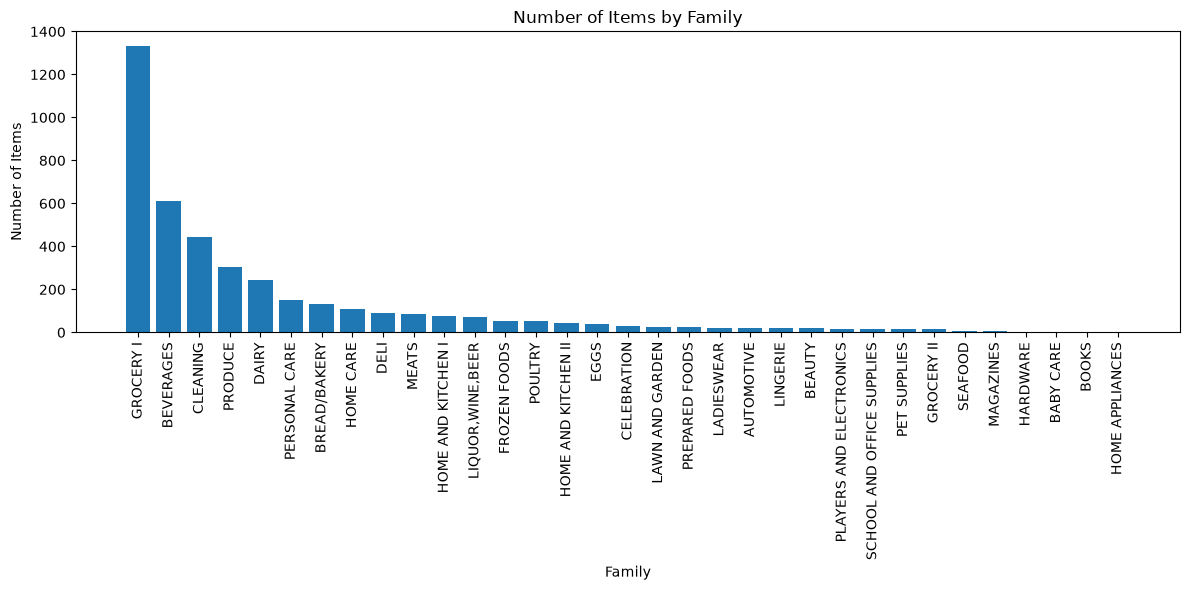

In [18]:
# Phân bố số lượng item theo family
# Đọc items.csv theo chunks


family_counts = {}

for chunk in [pd.read_csv(
    "../data/raw/items.csv",
    usecols=["item_nbr", "family"]
)]:
    counts = chunk.groupby("family")["item_nbr"].nunique()

    for family, count in counts.items():
        family_counts[family] = (
            family_counts.get(family, 0) + count
        )

df_family = (
    pd.DataFrame(
        list(family_counts.items()),
        columns=["family", "item_count"]
    )
    .sort_values("item_count", ascending=False)
)

print(f"Number of unique items: {sum(family_counts.values()):,}")

plt.figure(figsize=(12, 6))

plt.bar(
    df_family["family"],
    df_family["item_count"]
)

plt.title("Number of Items by Family")
plt.xlabel("Family")
plt.ylabel("Number of Items")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


Minimum item_nbr: 96995
Maximum item_nbr: 2134244


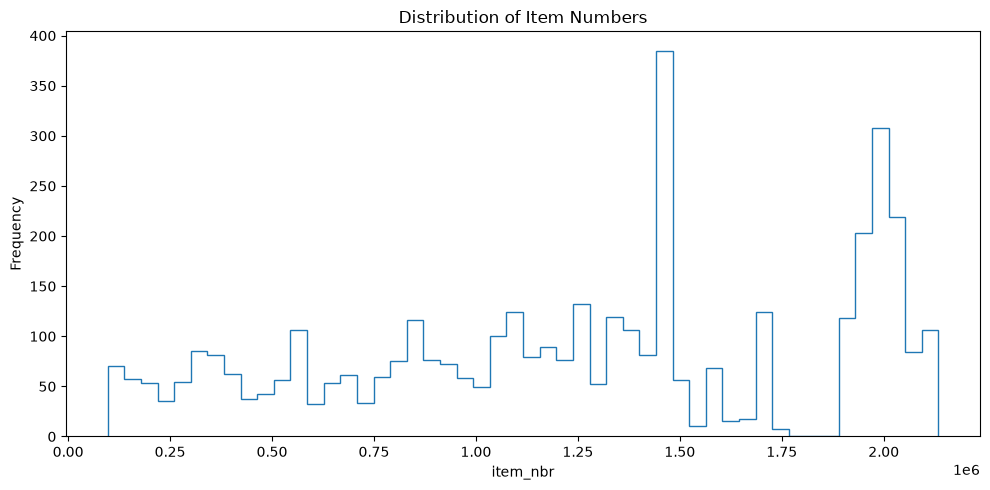

In [19]:
# Histogram của item_nbr theo chunks

bins = 50

min_item = float("inf")
max_item = float("-inf")

# Tìm min/max
for chunk in [pd.read_csv(
    "../data/raw/items.csv",
    usecols=["item_nbr"]
)]:
    min_item = min(min_item, chunk["item_nbr"].min())
    max_item = max(max_item, chunk["item_nbr"].max())

print(f"Minimum item_nbr: {min_item}")
print(f"Maximum item_nbr: {max_item}")

# Tạo bins
bin_edges = np.linspace(
    min_item,
    max_item,
    bins + 1
)

hist_counts = np.zeros(
    bins,
    dtype=np.int64
)

# Tính histogram theo chunks
for chunk in [pd.read_csv(
    "../data/raw/items.csv",
    usecols=["item_nbr"]
)]:
    counts, _ = np.histogram(
        chunk["item_nbr"],
        bins=bin_edges
    )

    hist_counts += counts

# Vẽ
plt.figure(figsize=(10, 5))

plt.stairs(
    hist_counts,
    bin_edges
)

plt.title("Distribution of Item Numbers")
plt.xlabel("item_nbr")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


In [20]:
# Missing Values - items.csv
# Đọc theo chunks để tiết kiệm RAM


missing_count = None
total_rows = 0

for chunk in [pd.read_csv(
    "../data/raw/items.csv"
)]:
    chunk_missing = chunk.isnull().sum()

    if missing_count is None:
        missing_count = chunk_missing
    else:
        missing_count += chunk_missing

    total_rows += len(chunk)

# Tạo bảng tổng hợp
missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": (
        missing_count / total_rows * 100
    ).round(2)
})

# Chỉ hiển thị cột có missing
missing_summary = (
    missing_summary[
        missing_summary["missing_count"] > 0
    ]
    .sort_values(
        "missing_count",
        ascending=False
    )
)

print(f"Total rows: {total_rows:,}")
print("\nMissing values:")

display(missing_summary)

if missing_summary.empty:
    print("No missing values found in items.csv.")


Total rows: 4,100

Missing values:


,missing_count,missing_percent


No missing values found in items.csv.


Tổng số item: 4,100


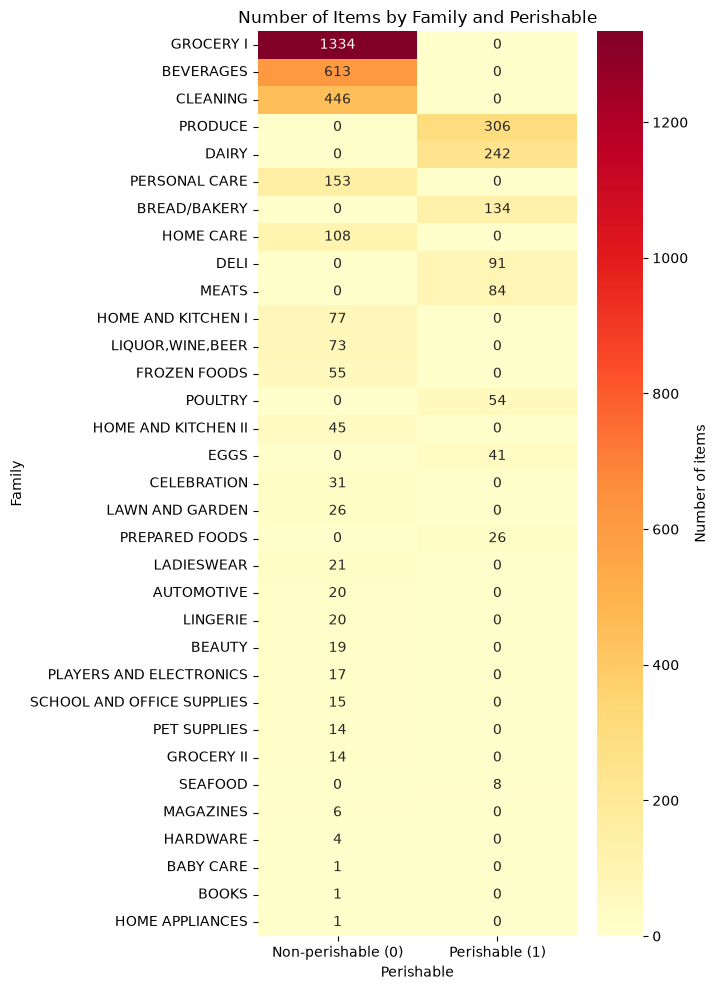

In [21]:
# Heatmap - items.csv: số lượng item theo family × perishable
# Đọc theo chunks

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

partials = []

for chunk in [pd.read_csv(
    "../data/raw/items.csv",
    usecols=["family", "perishable"]
)]:
    partials.append(
        chunk.groupby(["family", "perishable"]).size()
    )

# Gộp các chunks -> bảng family × perishable
family_perishable = (
    pd.concat(partials)
      .groupby(level=[0, 1])
      .sum()
      .unstack(fill_value=0)
)

family_perishable.columns = [
    "Non-perishable (0)" if c == 0 else "Perishable (1)"
    for c in family_perishable.columns
]

# Sắp xếp family theo tổng số item giảm dần
family_perishable = family_perishable.loc[
    family_perishable.sum(axis=1).sort_values(ascending=False).index
]

print(f"Tổng số item: {family_perishable.sum().sum():,}")

fig, ax = plt.subplots(figsize=(7, 10))

sns.heatmap(
    family_perishable,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    cbar_kws={"label": "Number of items"},
    ax=ax
)

ax.set_title("Number of Items by Family and Perishable")
ax.set_xlabel("Perishable")
ax.set_ylabel("Family")

plt.tight_layout()
plt.show()


In [22]:
# Items - Number of items by family × perishable
# Đọc toàn bộ items.csv theo chunks
# Xuất kết quả dưới dạng Markdown table

import pandas as pd
from IPython.display import Markdown, display

partials = []

# ============================================================
# 1. Đọc dữ liệu theo chunks
# ============================================================

for chunk in [pd.read_csv(
    "../data/raw/items.csv",
    usecols=["family", "perishable"]
)]:
    partial = (
        chunk
        .groupby(["family", "perishable"])
        .size()
        .reset_index(name="item_count")
    )

    partials.append(partial)


# ============================================================
# 2. Gộp kết quả giữa các chunks
# ============================================================

family_perishable = (
    pd.concat(partials, ignore_index=True)
    .groupby(
        ["family", "perishable"],
        as_index=False
    )["item_count"]
    .sum()
)


# ============================================================
# 3. Pivot thành Family × Perishable
# ============================================================

family_perishable = family_perishable.pivot(
    index="family",
    columns="perishable",
    values="item_count"
).fillna(0)


# Đảm bảo luôn có cả hai cột 0 và 1
for col in [0, 1]:
    if col not in family_perishable.columns:
        family_perishable[col] = 0

family_perishable = family_perishable[[0, 1]]

# Đổi tên cột
family_perishable.columns = [
    "Non-perishable (0)",
    "Perishable (1)"
]


# ============================================================
# 4. Sắp xếp family theo tổng số item giảm dần
# ============================================================

family_perishable = family_perishable.loc[
    family_perishable.sum(axis=1)
    .sort_values(ascending=False)
    .index
]


print(
    f"Tổng số item: "
    f"{family_perishable.sum().sum():,.0f}"
)

print(
    f"Số family: "
    f"{family_perishable.shape[0]:,}"
)


# ============================================================
# 5. Format thành bảng
# ============================================================

family_perishable_formatted = (
    family_perishable
    .astype(int)
    .map(lambda x: f"{x:,}")
    .reset_index()
)

family_perishable_formatted = (
    family_perishable_formatted
    .rename(columns={"family": "Family"})
)

family_perishable_formatted.columns.name = None


# ============================================================
# 6. Tạo Markdown table
# Không cần package tabulate
# ============================================================

headers = family_perishable_formatted.columns.tolist()

md_lines = []

# Header
md_lines.append(
    "| " + " | ".join(map(str, headers)) + " |"
)

# Separator
md_lines.append(
    "| " + " | ".join(["---"] * len(headers)) + " |"
)

# Data
for row in family_perishable_formatted.itertuples(
    index=False,
    name=None
):
    md_lines.append(
        "| " + " | ".join(map(str, row)) + " |"
    )

md_table = "\n".join(md_lines)


# ============================================================
# 7. Xuất file Markdown
# ============================================================

output_path = "heatmap_items_family_perishable.md"

with open(
    output_path,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "# Number of Items by Family and Perishable\n\n"
    )

    f.write(
        f"- **Tổng số item:** "
        f"{family_perishable.sum().sum():,.0f}\n"
    )

    f.write(
        f"- **Số family:** "
        f"{family_perishable.shape[0]:,}\n\n"
    )

    f.write(md_table)


print(
    f"Đã lưu bảng heatmap vào file: "
    f"{output_path}"
)


# ============================================================
# 8. Hiển thị trực tiếp trong Jupyter Notebook
# ============================================================

display(
    Markdown(md_table)
)


Tổng số item: 4,100
Số family: 33
Đã lưu bảng heatmap vào file: heatmap_items_family_perishable.md


| Family | Non-perishable (0) | Perishable (1) |
| --- | --- | --- |
| GROCERY I | 1,334 | 0 |
| BEVERAGES | 613 | 0 |
| CLEANING | 446 | 0 |
| PRODUCE | 0 | 306 |
| DAIRY | 0 | 242 |
| PERSONAL CARE | 153 | 0 |
| BREAD/BAKERY | 0 | 134 |
| HOME CARE | 108 | 0 |
| DELI | 0 | 91 |
| MEATS | 0 | 84 |
| HOME AND KITCHEN I | 77 | 0 |
| LIQUOR,WINE,BEER | 73 | 0 |
| FROZEN FOODS | 55 | 0 |
| POULTRY | 0 | 54 |
| HOME AND KITCHEN II | 45 | 0 |
| EGGS | 0 | 41 |
| CELEBRATION | 31 | 0 |
| LAWN AND GARDEN | 26 | 0 |
| PREPARED FOODS | 0 | 26 |
| LADIESWEAR | 21 | 0 |
| AUTOMOTIVE | 20 | 0 |
| LINGERIE | 20 | 0 |
| BEAUTY | 19 | 0 |
| PLAYERS AND ELECTRONICS | 17 | 0 |
| SCHOOL AND OFFICE SUPPLIES | 15 | 0 |
| PET SUPPLIES | 14 | 0 |
| GROCERY II | 14 | 0 |
| SEAFOOD | 0 | 8 |
| MAGAZINES | 6 | 0 |
| HARDWARE | 4 | 0 |
| BABY CARE | 1 | 0 |
| BOOKS | 1 | 0 |
| HOME APPLIANCES | 1 | 0 |

## Stores.csv

In [23]:
df = pd.read_csv("../data/raw/stores.csv")
print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (54, 5)


,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


Number of unique stores: 54


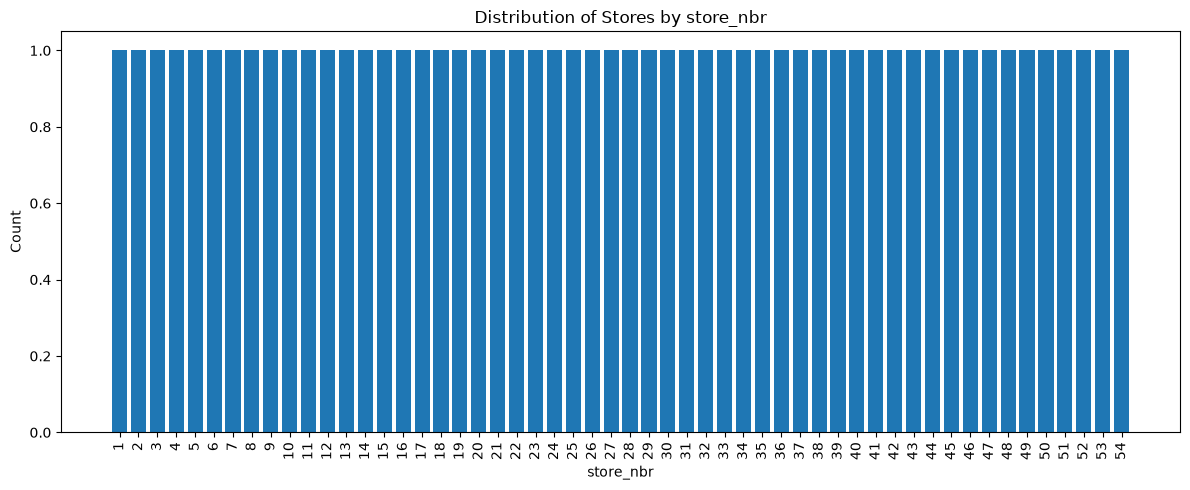

In [24]:
# Phân bố số lượng Store theo store_nbr
# Đọc stores.csv theo chunks


store_nbr_set = set()

for chunk in [pd.read_csv(
    "../data/raw/stores.csv",
    usecols=["store_nbr"]
)]:
    store_nbr_set.update(
        chunk["store_nbr"].dropna().unique()
    )

store_nbr_values = sorted(store_nbr_set)

print(f"Number of unique stores: {len(store_nbr_values)}")

plt.figure(figsize=(12, 5))

plt.bar(
    [str(x) for x in store_nbr_values],
    [1] * len(store_nbr_values)
)

plt.title("Distribution of Stores by store_nbr")
plt.xlabel("store_nbr")
plt.ylabel("Count")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


Minimum store_nbr: 1
Maximum store_nbr: 54


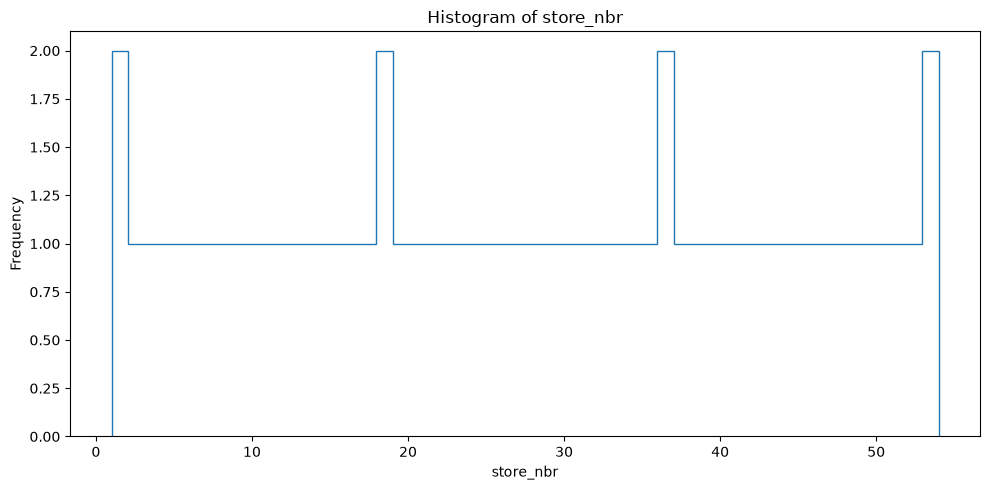

In [25]:
# Histogram của store_nbr theo chunks

bins = 50

min_store = float("inf")
max_store = float("-inf")

# Tìm min/max
for chunk in [pd.read_csv(
    "../data/raw/stores.csv",
    usecols=["store_nbr"]
)]:
    min_store = min(
        min_store,
        chunk["store_nbr"].min()
    )

    max_store = max(
        max_store,
        chunk["store_nbr"].max()
    )

print(f"Minimum store_nbr: {min_store}")
print(f"Maximum store_nbr: {max_store}")

# Tạo bins
bin_edges = np.linspace(
    min_store,
    max_store,
    bins + 1
)

hist_counts = np.zeros(
    bins,
    dtype=np.int64
)

# Tính histogram theo chunks
for chunk in [pd.read_csv(
    "../data/raw/stores.csv",
    usecols=["store_nbr"]
)]:
    counts, _ = np.histogram(
        chunk["store_nbr"].dropna(),
        bins=bin_edges
    )

    hist_counts += counts

# Vẽ histogram
plt.figure(figsize=(10, 5))

plt.stairs(
    hist_counts,
    bin_edges
)

plt.title("Histogram of store_nbr")
plt.xlabel("store_nbr")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


    cluster  store_count
8         1            3
12        2            2
0         3            7
7         4            3
15        5            1
1         6            6
11        7            2
6         8            3
10        9            2
2        10            6
9        11            3
13       12            1
4        13            4
5        14            4
3        15            5
14       16            1
16       17            1


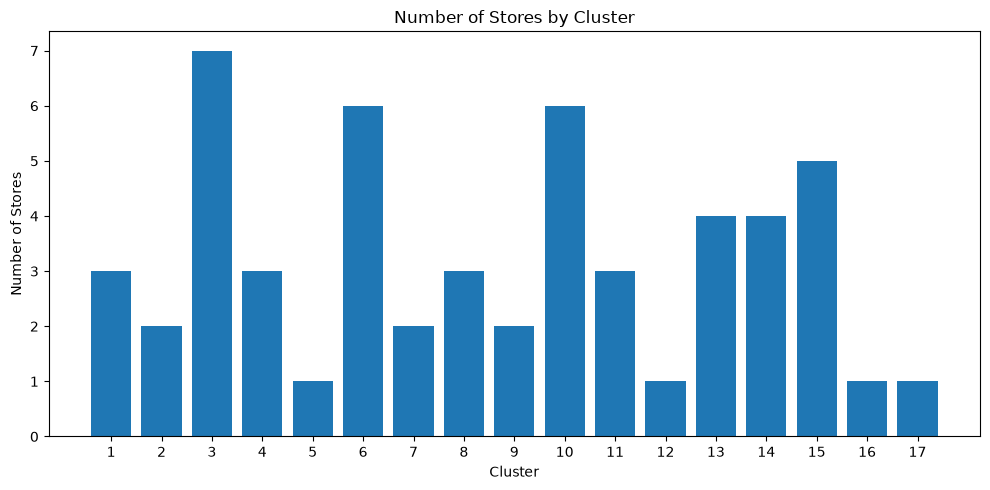

In [26]:
# Phân bố số lượng Store theo cluster
# Đọc stores.csv theo chunks


cluster_counts = {}

for chunk in [pd.read_csv(
    "../data/raw/stores.csv",
    usecols=["cluster"]
)]:
    counts = chunk["cluster"].value_counts()

    for cluster, count in counts.items():
        cluster_counts[cluster] = (
            cluster_counts.get(cluster, 0) + count
        )

df_cluster = (
    pd.DataFrame(
        list(cluster_counts.items()),
        columns=["cluster", "store_count"]
    )
    .sort_values("cluster")
)

print(df_cluster)

plt.figure(figsize=(10, 5))

plt.bar(
    df_cluster["cluster"].astype(str),
    df_cluster["store_count"]
)

plt.title("Number of Stores by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Stores")

plt.tight_layout()
plt.show()


Minimum cluster: 1
Maximum cluster: 17


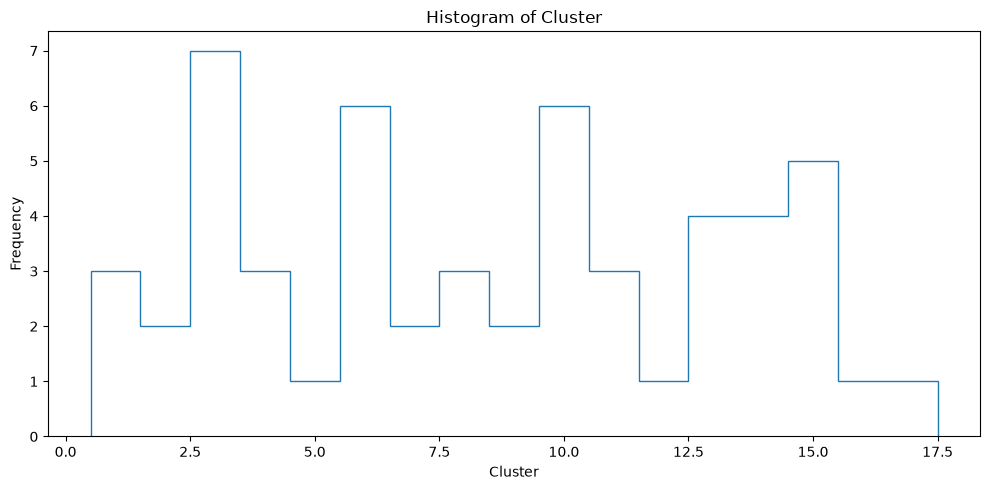

In [27]:
# Histogram của cluster theo chunks

bins = 20

min_cluster = float("inf")
max_cluster = float("-inf")

# Tìm min/max
for chunk in [pd.read_csv(
    "../data/raw/stores.csv",
    usecols=["cluster"]
)]:
    min_cluster = min(
        min_cluster,
        chunk["cluster"].min()
    )

    max_cluster = max(
        max_cluster,
        chunk["cluster"].max()
    )

print(f"Minimum cluster: {min_cluster}")
print(f"Maximum cluster: {max_cluster}")

# Tạo bins
bin_edges = np.arange(
    min_cluster - 0.5,
    max_cluster + 1.5,
    1
)

hist_counts = np.zeros(
    len(bin_edges) - 1,
    dtype=np.int64
)

# Tính histogram theo chunks
for chunk in [pd.read_csv(
    "../data/raw/stores.csv",
    usecols=["cluster"]
)]:
    values = chunk["cluster"].dropna()

    counts, _ = np.histogram(
        values,
        bins=bin_edges
    )

    hist_counts += counts

# Vẽ
plt.figure(figsize=(10, 5))

plt.stairs(
    hist_counts,
    bin_edges
)

plt.title("Histogram of Cluster")
plt.xlabel("Cluster")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


In [28]:
# Missing Values - stores.csv
# Đọc toàn bộ file theo chunks


missing_count = None
total_rows = 0

for chunk in [pd.read_csv(
    "../data/raw/stores.csv"
)]:
    chunk_missing = chunk.isnull().sum()

    if missing_count is None:
        missing_count = chunk_missing
    else:
        missing_count += chunk_missing

    total_rows += len(chunk)

# Tạo bảng tổng hợp
missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": (
        missing_count / total_rows * 100
    ).round(2)
})

# Chỉ hiển thị những cột có missing
missing_summary = (
    missing_summary[
        missing_summary["missing_count"] > 0
    ]
    .sort_values(
        "missing_count",
        ascending=False
    )
)

print(f"Total rows: {total_rows:,}")
print("\nMissing values:")

display(missing_summary)

if missing_summary.empty:
    print("No missing values found in stores.csv.")


Total rows: 54

Missing values:


,missing_count,missing_percent


No missing values found in stores.csv.


Tổng số store: 54


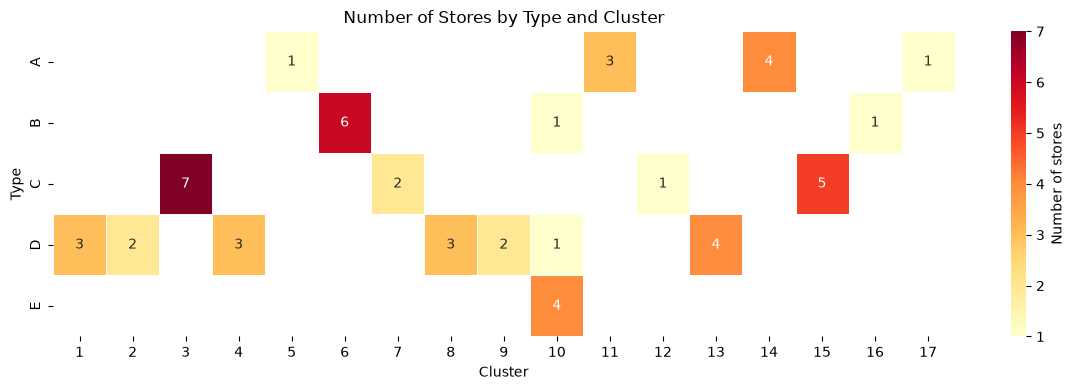

In [29]:
# Heatmap - stores.csv: số lượng store theo type × cluster
# Đọc theo chunks

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

partials = []

for chunk in [pd.read_csv(
    "../data/raw/stores.csv",
    usecols=["type", "cluster"]
)]:
    partials.append(
        chunk.groupby(["type", "cluster"]).size()
    )

type_cluster = (
    pd.concat(partials)
      .groupby(level=[0, 1])
      .sum()
      .unstack(fill_value=0)
)

print(f"Tổng số store: {type_cluster.sum().sum():,}")

fig, ax = plt.subplots(figsize=(12, 4))

sns.heatmap(
    type_cluster,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    mask=(type_cluster == 0),      # ẩn ô 0 cho dễ đọc
    linewidths=0.5,
    cbar_kws={"label": "Number of stores"},
    ax=ax
)

ax.set_title("Number of Stores by Type and Cluster")
ax.set_xlabel("Cluster")
ax.set_ylabel("Type")

plt.tight_layout()
plt.show()


In [30]:
# Heatmap - stores.csv: số lượng store theo type × cluster
# Đọc theo chunks và xuất thành Markdown table

import pandas as pd
from IPython.display import Markdown, display

partials = []

for chunk in [pd.read_csv(
    "../data/raw/stores.csv",
    usecols=["type", "cluster"]
)]:
    partial = (
        chunk
        .groupby(["type", "cluster"])
        .size()
        .reset_index(name="store_count")
    )
    partials.append(partial)

# Gộp kết quả từ các chunks
type_cluster = (
    pd.concat(partials, ignore_index=True)
      .groupby(["type", "cluster"], as_index=False)["store_count"]
      .sum()
      .pivot(index="type", columns="cluster", values="store_count")
      .fillna(0)
)

# Đảm bảo giá trị là số nguyên
type_cluster = type_cluster.astype(int)

print(f"Tổng số store: {type_cluster.sum().sum():,}")
print(f"Số loại store (type): {type_cluster.shape[0]:,}")
print(f"Số cluster: {type_cluster.shape[1]:,}")

# Sắp xếp type theo tổng số store giảm dần
type_cluster = type_cluster.loc[
    type_cluster.sum(axis=1).sort_values(ascending=False).index
]

# Format số có dấu phẩy
type_cluster_formatted = (
    type_cluster
    .map(lambda x: f"{x:,}" if x != 0 else "-")
    .reset_index()
    .rename(columns={"type": "Store Type"})
)

type_cluster_formatted.columns.name = None

# Tạo Markdown table thủ công, không cần tabulate
headers = type_cluster_formatted.columns.tolist()

md_lines = [
    "| " + " | ".join(map(str, headers)) + " |",
    "| " + " | ".join(["---"] * len(headers)) + " |"
]

for row in type_cluster_formatted.itertuples(index=False, name=None):
    md_lines.append(
        "| " + " | ".join(map(str, row)) + " |"
    )

md_table = "\n".join(md_lines)

# Lưu ra file Markdown
output_path = "heatmap_stores_type_cluster.md"

with open(output_path, "w", encoding="utf-8") as f:
    f.write("# Number of Stores by Type and Cluster\n\n")
    f.write(f"- **Tổng số store:** {type_cluster.sum().sum():,}\n")
    f.write(f"- **Số loại store:** {type_cluster.shape[0]:,}\n")
    f.write(f"- **Số cluster:** {type_cluster.shape[1]:,}\n\n")
    f.write(md_table)

print(f"Đã lưu bảng vào file: {output_path}")

# Hiển thị trong notebook
display(Markdown(md_table))


Tổng số store: 54
Số loại store (type): 5
Số cluster: 17
Đã lưu bảng vào file: heatmap_stores_type_cluster.md


| Store Type | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 | 12 | 13 | 14 | 15 | 16 | 17 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| D | 3 | 2 | - | 3 | - | - | - | 3 | 2 | 1 | - | - | 4 | - | - | - | - |
| C | - | - | 7 | - | - | - | 2 | - | - | - | - | 1 | - | - | 5 | - | - |
| A | - | - | - | - | 1 | - | - | - | - | - | 3 | - | - | 4 | - | - | 1 |
| B | - | - | - | - | - | 6 | - | - | - | 1 | - | - | - | - | - | 1 | - |
| E | - | - | - | - | - | - | - | - | - | 4 | - | - | - | - | - | - | - |

stores.csv
│
├── store_nbr
│   ├── Phân bố số lượng store
│   └── Histogram
│
├── cluster
│   ├── Số lượng store / cluster
│   └── Histogram
│
└── Missing values

## Oil.csv

In [31]:
df = pd.read_csv("../data/raw/oil.csv")
print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (1218, 2)


,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


Number of rows: 1,218
Date range: 2013-01-01 → 2017-08-31


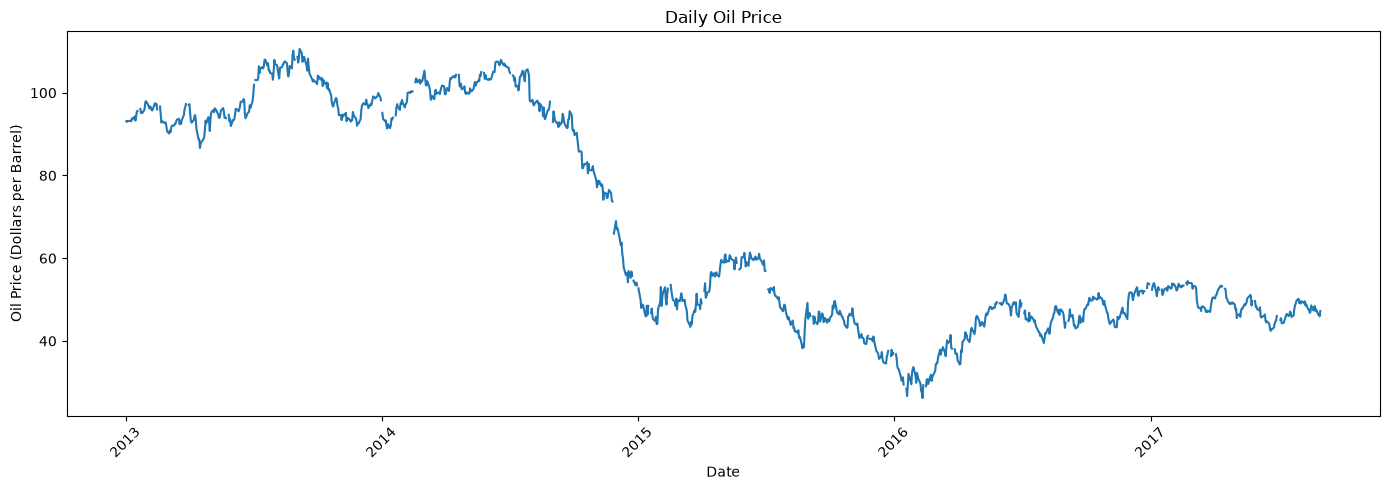

In [32]:
# Time Series - Oil Price
# Đọc oil.csv theo chunks để tiết kiệm RAM


oil_data = []

for chunk in [pd.read_csv(
    "../data/raw/oil.csv",
    usecols=["date", "dcoilwtico"]
)]:
    chunk["date"] = pd.to_datetime(chunk["date"])

    oil_data.append(chunk)

# Gộp các chunks
df_oil_ts = (
    pd.concat(oil_data, ignore_index=True)
      .sort_values("date")
)

print(f"Number of rows: {len(df_oil_ts):,}")
print(
    f"Date range: "
    f"{df_oil_ts['date'].min().date()} → "
    f"{df_oil_ts['date'].max().date()}"
)

# Vẽ Time Series
plt.figure(figsize=(14, 5))

plt.plot(
    df_oil_ts["date"],
    df_oil_ts["dcoilwtico"]
)

plt.title("Daily Oil Price")
plt.xlabel("Date")
plt.ylabel("Oil Price (Dollars per Barrel)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Minimum oil price: 26.19
Maximum oil price: 110.62


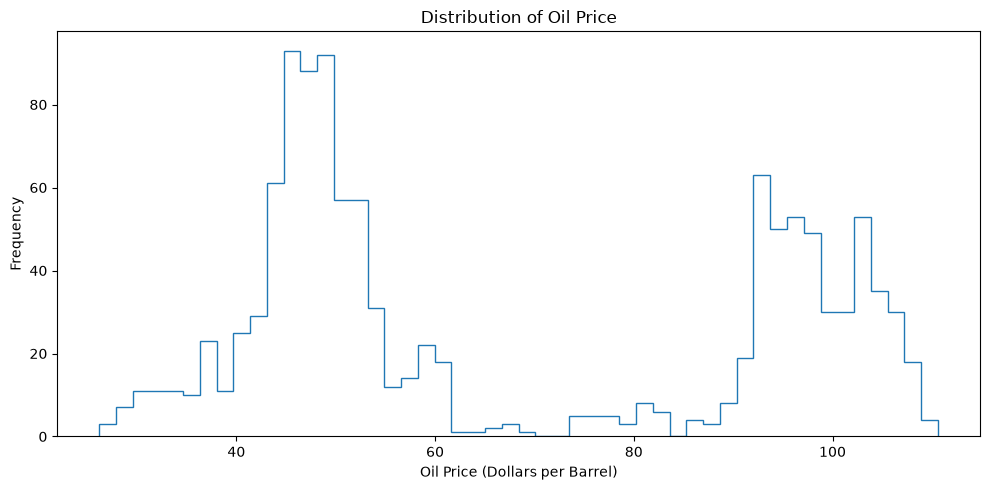

In [33]:
# Histogram - Oil Price
# Tính histogram theo chunks

bins = 50

min_oil = float("inf")
max_oil = float("-inf")

# Tìm min/max
for chunk in [pd.read_csv(
    "../data/raw/oil.csv",
    usecols=["dcoilwtico"]
)]:
    values = chunk["dcoilwtico"].dropna()

    if len(values) > 0:
        min_oil = min(min_oil, values.min())
        max_oil = max(max_oil, values.max())

print(f"Minimum oil price: {min_oil}")
print(f"Maximum oil price: {max_oil}")

# Tạo bins
bin_edges = np.linspace(
    min_oil,
    max_oil,
    bins + 1
)

hist_counts = np.zeros(
    bins,
    dtype=np.int64
)

# Tính histogram theo từng chunk
for chunk in [pd.read_csv(
    "../data/raw/oil.csv",
    usecols=["dcoilwtico"]
)]:
    values = chunk["dcoilwtico"].dropna()

    counts, _ = np.histogram(
        values,
        bins=bin_edges
    )

    hist_counts += counts

# Vẽ histogram
plt.figure(figsize=(10, 5))

plt.stairs(
    hist_counts,
    bin_edges
)

plt.title("Distribution of Oil Price")
plt.xlabel("Oil Price (Dollars per Barrel)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


In [34]:
# Missing Values - oil.csv
# Đọc oil.csv theo chunks


missing_count = None
total_rows = 0

for chunk in [pd.read_csv(
    "../data/raw/oil.csv"
)]:
    chunk_missing = chunk.isnull().sum()

    if missing_count is None:
        missing_count = chunk_missing
    else:
        missing_count += chunk_missing

    total_rows += len(chunk)

# Tạo bảng tổng hợp
missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": (
        missing_count / total_rows * 100
    ).round(2)
})

# Chỉ hiển thị những cột có missing
missing_summary = (
    missing_summary[
        missing_summary["missing_count"] > 0
    ]
    .sort_values(
        "missing_count",
        ascending=False
    )
)

print(f"Total rows: {total_rows:,}")
print("\nMissing values:")

display(missing_summary)

if missing_summary.empty:
    print("No missing values found in oil.csv.")


Total rows: 1,218

Missing values:


,missing_count,missing_percent
dcoilwtico,43,3.53


Heatmap shape (years × months): (5, 12)


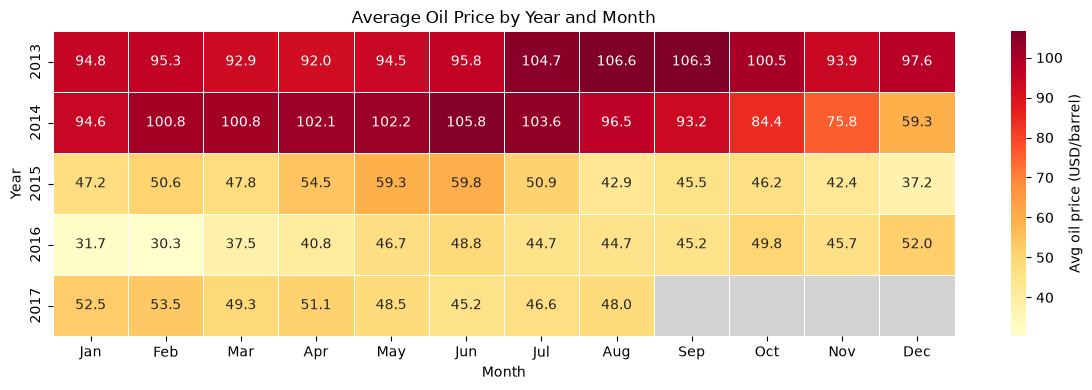

In [35]:
# Heatmap - oil.csv: giá dầu trung bình theo năm × tháng
# Đọc theo chunks; mean = sum / count (count bỏ qua NaN)

import calendar
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

partials = []

for chunk in [pd.read_csv(
    "../data/raw/oil.csv",
    usecols=["date", "dcoilwtico"]
)]:
    chunk["date"] = pd.to_datetime(chunk["date"])
    chunk["year"] = chunk["date"].dt.year
    chunk["month"] = chunk["date"].dt.month

    partials.append(
        chunk.groupby(["year", "month"])["dcoilwtico"]
             .agg(["sum", "count"])
    )

oil_ym = pd.concat(partials).groupby(level=[0, 1]).sum()
oil_ym["mean_price"] = oil_ym["sum"] / oil_ym["count"]

heat_oil = oil_ym["mean_price"].unstack("month")
heat_oil.columns = [calendar.month_abbr[m] for m in heat_oil.columns]

print(f"Heatmap shape (years × months): {heat_oil.shape}")

fig, ax = plt.subplots(figsize=(12, 4))

sns.heatmap(
    heat_oil,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Avg oil price (USD/barrel)"},
    ax=ax
)

ax.set_facecolor("lightgrey")   # ô xám = tháng không có dữ liệu
ax.set_title("Average Oil Price by Year and Month")
ax.set_xlabel("Month")
ax.set_ylabel("Year")

plt.tight_layout()
plt.show()


In [36]:
# Heatmap - oil.csv: giá dầu trung bình theo năm × tháng
# Đọc theo chunks; mean = sum / count (count bỏ qua NaN)

import calendar
import pandas as pd
from IPython.display import Markdown, display

partials = []

for chunk in [pd.read_csv(
    "../data/raw/oil.csv",
    usecols=["date", "dcoilwtico"]
)]:
    chunk["date"] = pd.to_datetime(chunk["date"])
    chunk["year"] = chunk["date"].dt.year
    chunk["month"] = chunk["date"].dt.month

    partial = (
        chunk
        .groupby(["year", "month"])["dcoilwtico"]
        .agg(["sum", "count"])
        .reset_index()
    )

    partials.append(partial)

# Gộp các chunks
oil_ym = (
    pd.concat(partials, ignore_index=True)
      .groupby(["year", "month"], as_index=False)[["sum", "count"]]
      .sum()
)

# Tính giá dầu trung bình
oil_ym["mean_price"] = (
    oil_ym["sum"] / oil_ym["count"]
)

# Pivot: Year × Month
heat_oil = (
    oil_ym
    .pivot(index="year", columns="month", values="mean_price")
    .reindex(columns=range(1, 13))
)

# Đổi số tháng thành tên tháng
heat_oil.columns = [
    calendar.month_abbr[m] for m in heat_oil.columns
]

print(f"Heatmap shape (years × months): {heat_oil.shape}")

# Format giá trị
heat_oil_formatted = (
    heat_oil
    .map(lambda x: f"{x:.1f}" if pd.notnull(x) else "-")
    .reset_index()
    .rename(columns={"year": "Year"})
)

heat_oil_formatted.columns.name = None

# Tạo Markdown table thủ công
headers = heat_oil_formatted.columns.tolist()

md_lines = [
    "| " + " | ".join(map(str, headers)) + " |",
    "| " + " | ".join(["---"] * len(headers)) + " |"
]

for row in heat_oil_formatted.itertuples(index=False, name=None):
    md_lines.append(
        "| " + " | ".join(map(str, row)) + " |"
    )

md_table = "\n".join(md_lines)

# Lưu file Markdown
output_path = "heatmap_oil_year_month.md"

with open(output_path, "w", encoding="utf-8") as f:
    f.write("# Average Oil Price by Year and Month\n\n")
    f.write(
        "- **Metric:** Mean `dcoilwtico` (USD/barrel)\n"
        "- **Aggregation:** Year × Month\n"
        "- **Missing values:** `-`\n\n"
    )
    f.write(md_table)

print(f"Đã lưu bảng vào file: {output_path}")

# Hiển thị trong notebook
display(Markdown(md_table))


Heatmap shape (years × months): (5, 12)
Đã lưu bảng vào file: heatmap_oil_year_month.md


| Year | Jan | Feb | Mar | Apr | May | Jun | Jul | Aug | Sep | Oct | Nov | Dec |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 2013 | 94.8 | 95.3 | 92.9 | 92.0 | 94.5 | 95.8 | 104.7 | 106.6 | 106.3 | 100.5 | 93.9 | 97.6 |
| 2014 | 94.6 | 100.8 | 100.8 | 102.1 | 102.2 | 105.8 | 103.6 | 96.5 | 93.2 | 84.4 | 75.8 | 59.3 |
| 2015 | 47.2 | 50.6 | 47.8 | 54.5 | 59.3 | 59.8 | 50.9 | 42.9 | 45.5 | 46.2 | 42.4 | 37.2 |
| 2016 | 31.7 | 30.3 | 37.5 | 40.8 | 46.7 | 48.8 | 44.7 | 44.7 | 45.2 | 49.8 | 45.7 | 52.0 |
| 2017 | 52.5 | 53.5 | 49.3 | 51.1 | 48.5 | 45.2 | 46.6 | 48.0 | - | - | - | - |

## Holidays event

In [37]:
df = pd.read_csv("../data/raw/holidays_events.csv")
print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (350, 6)


,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False


Number of dates: 312
Date range: 2012-03-02 → 2017-12-26


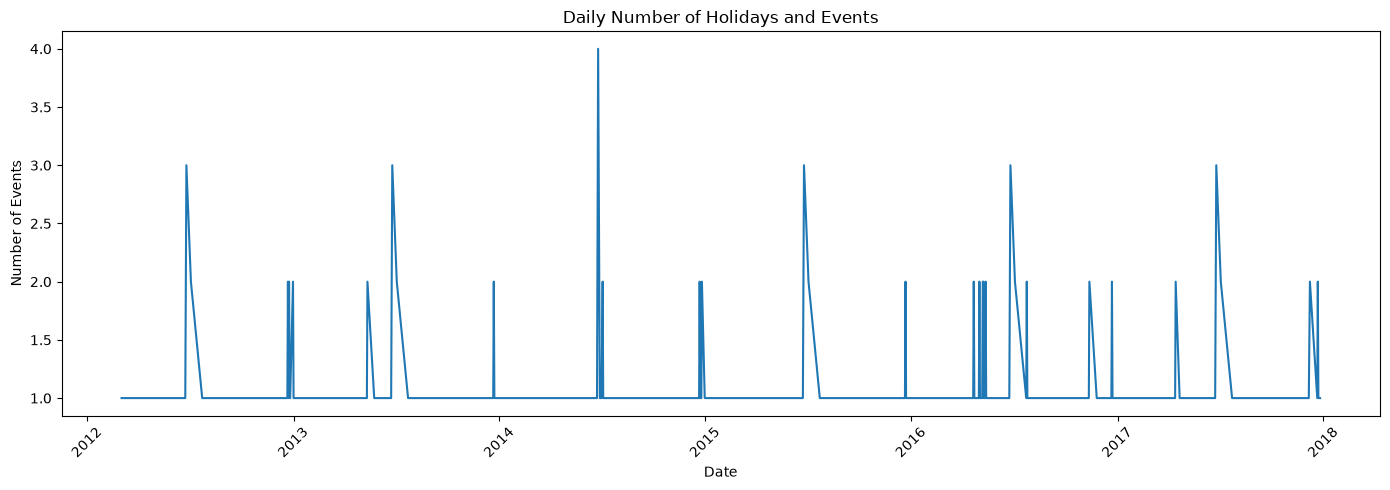

In [38]:
# Time Series - Số lượng Holiday/Event theo ngày
# Đọc holidays_events.csv theo chunks


daily_events = []

for chunk in [pd.read_csv(
    "../data/raw/holidays_events.csv",
    usecols=["date"]
)]:
    chunk["date"] = pd.to_datetime(chunk["date"])

    # Đếm số event trong từng ngày
    chunk_daily = (
        chunk.groupby("date")
             .size()
             .reset_index(name="event_count")
    )

    daily_events.append(chunk_daily)

# Gộp các chunks
df_events_ts = (
    pd.concat(daily_events, ignore_index=True)
      .groupby("date", as_index=False)["event_count"]
      .sum()
      .sort_values("date")
)

print(f"Number of dates: {len(df_events_ts):,}")
print(
    f"Date range: "
    f"{df_events_ts['date'].min().date()} → "
    f"{df_events_ts['date'].max().date()}"
)

# Vẽ
plt.figure(figsize=(14, 5))

plt.plot(
    df_events_ts["date"],
    df_events_ts["event_count"]
)

plt.title("Daily Number of Holidays and Events")
plt.xlabel("Date")
plt.ylabel("Number of Events")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


         type  count
0     Holiday    221
1       Event     56
2  Additional     51
3    Transfer     12
4      Bridge      5
5    Work Day      5


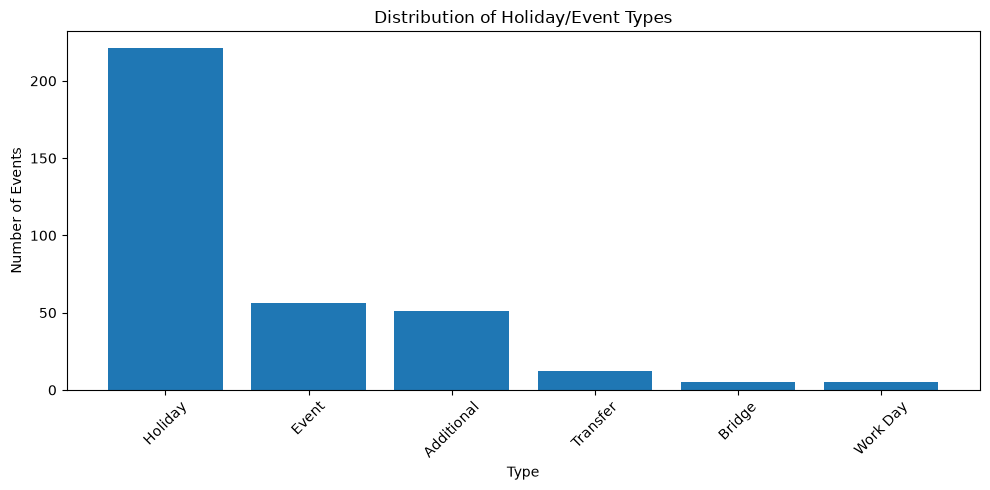

In [39]:
# Phân bố số lượng Holiday/Event theo type
# Đọc theo chunks


type_counts = {}

for chunk in [pd.read_csv(
    "../data/raw/holidays_events.csv",
    usecols=["type"]
)]:
    counts = chunk["type"].value_counts()

    for event_type, count in counts.items():
        type_counts[event_type] = (
            type_counts.get(event_type, 0) + count
        )

df_type = (
    pd.DataFrame(
        list(type_counts.items()),
        columns=["type", "count"]
    )
    .sort_values("count", ascending=False)
)

print(df_type)

# Vẽ phân bố
plt.figure(figsize=(10, 5))

plt.bar(
    df_type["type"],
    df_type["count"]
)

plt.title("Distribution of Holiday/Event Types")
plt.xlabel("Type")
plt.ylabel("Number of Events")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [40]:
# Missing Values - holidays_events.csv
# Đọc theo chunks


missing_count = None
total_rows = 0

for chunk in [pd.read_csv(
    "../data/raw/holidays_events.csv"
)]:
    chunk_missing = chunk.isnull().sum()

    if missing_count is None:
        missing_count = chunk_missing
    else:
        missing_count += chunk_missing

    total_rows += len(chunk)

# Tạo bảng tổng hợp
missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": (
        missing_count / total_rows * 100
    ).round(2)
})

# Chỉ hiển thị cột có missing
missing_summary = (
    missing_summary[
        missing_summary["missing_count"] > 0
    ]
    .sort_values(
        "missing_count",
        ascending=False
    )
)

print(f"Total rows: {total_rows:,}")
print("\nMissing values:")

display(missing_summary)

if missing_summary.empty:
    print("No missing values found in holidays_events.csv.")


Total rows: 350

Missing values:


,missing_count,missing_percent


No missing values found in holidays_events.csv.


Tổng số dòng: 350


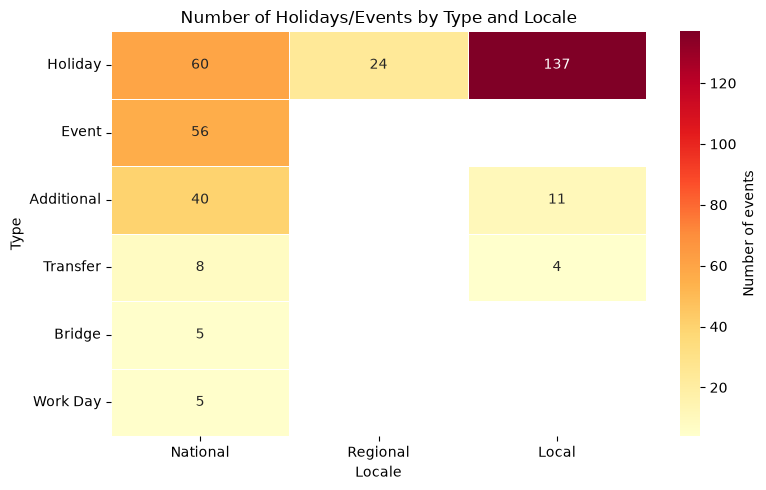

In [41]:
# Heatmap - holidays_events.csv: số lượng sự kiện theo type × locale
# Đọc theo chunks

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

partials = []

for chunk in [pd.read_csv(
    "../data/raw/holidays_events.csv",
    usecols=["type", "locale"]
)]:
    partials.append(
        chunk.groupby(["type", "locale"]).size()
    )

type_locale = (
    pd.concat(partials)
      .groupby(level=[0, 1])
      .sum()
      .unstack(fill_value=0)
)

# Sắp xếp: locale từ rộng -> hẹp, type theo tổng giảm dần
locale_order = [c for c in ["National", "Regional", "Local"] if c in type_locale.columns]
type_locale = type_locale[locale_order]
type_locale = type_locale.loc[
    type_locale.sum(axis=1).sort_values(ascending=False).index
]

print(f"Tổng số dòng: {type_locale.sum().sum():,}")

fig, ax = plt.subplots(figsize=(8, 5))

sns.heatmap(
    type_locale,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    mask=(type_locale == 0),
    linewidths=0.5,
    cbar_kws={"label": "Number of events"},
    ax=ax
)

ax.set_title("Number of Holidays/Events by Type and Locale")
ax.set_xlabel("Locale")
ax.set_ylabel("Type")

plt.tight_layout()
plt.show()


In [42]:
# Heatmap - holidays_events.csv: số lượng sự kiện theo type × locale
# Đọc theo chunks và xuất thành Markdown table

import pandas as pd
from IPython.display import Markdown, display

partials = []

for chunk in [pd.read_csv(
    "../data/raw/holidays_events.csv",
    usecols=["type", "locale"]
)]:
    partial = (
        chunk
        .groupby(["type", "locale"])
        .size()
        .reset_index(name="event_count")
    )
    partials.append(partial)

# Gộp kết quả từ các chunks
type_locale = (
    pd.concat(partials, ignore_index=True)
      .groupby(["type", "locale"], as_index=False)["event_count"]
      .sum()
      .pivot(index="type", columns="locale", values="event_count")
      .fillna(0)
)

# Đảm bảo đủ 3 loại locale theo thứ tự National → Regional → Local
locale_order = [
    c for c in ["National", "Regional", "Local"]
    if c in type_locale.columns
]

type_locale = type_locale[locale_order].astype(int)

# Sắp xếp type theo tổng số event giảm dần
type_locale = type_locale.loc[
    type_locale.sum(axis=1).sort_values(ascending=False).index
]

print(f"Tổng số dòng: {type_locale.sum().sum():,}")
print(f"Số loại event: {type_locale.shape[0]:,}")
print(f"Số locale: {type_locale.shape[1]:,}")

# Format số
type_locale_formatted = (
    type_locale
    .map(lambda x: f"{x:,}" if x != 0 else "-")
    .reset_index()
    .rename(columns={"type": "Event Type"})
)

type_locale_formatted.columns.name = None

# Tạo Markdown table thủ công
headers = type_locale_formatted.columns.tolist()

md_lines = [
    "| " + " | ".join(map(str, headers)) + " |",
    "| " + " | ".join(["---"] * len(headers)) + " |"
]

for row in type_locale_formatted.itertuples(index=False, name=None):
    md_lines.append(
        "| " + " | ".join(map(str, row)) + " |"
    )

md_table = "\n".join(md_lines)

# Lưu file Markdown
output_path = "heatmap_holidays_type_locale.md"

with open(output_path, "w", encoding="utf-8") as f:
    f.write("# Number of Holidays/Events by Type and Locale\n\n")
    f.write(f"- **Tổng số dòng:** {type_locale.sum().sum():,}\n")
    f.write(f"- **Số loại event:** {type_locale.shape[0]:,}\n")
    f.write(f"- **Số locale:** {type_locale.shape[1]:,}\n\n")
    f.write(md_table)

print(f"Đã lưu bảng vào file: {output_path}")

# Hiển thị trong notebook
display(Markdown(md_table))


Tổng số dòng: 350
Số loại event: 6
Số locale: 3
Đã lưu bảng vào file: heatmap_holidays_type_locale.md


| Event Type | National | Regional | Local |
| --- | --- | --- | --- |
| Holiday | 60 | 24 | 137 |
| Event | 56 | - | - |
| Additional | 40 | - | 11 |
| Transfer | 8 | - | 4 |
| Bridge | 5 | - | - |
| Work Day | 5 | - | - |

date
  │
  ├── type
  ├── locale
  ├── locale_name
  ├── description
  └── transferred

## Sample submssion

In [43]:
df = pd.read_csv("../data/raw/sample_submission.csv", nrows=5000)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (5000, 2)


,id,unit_sales
0,125497040,0
1,125497041,0
2,125497042,0
3,125497043,0
4,125497044,0


In [44]:
import pandas as pd

chunk_size = 100_000

total_rows = 0
missing_count = None
id_unique = set()
sample_parts = []

for chunk in pd.read_csv(
    "../data/raw/sample_submission.csv",
    chunksize=chunk_size
):
    total_rows += len(chunk)

    # Missing values
    chunk_missing = chunk.isnull().sum()
    if missing_count is None:
        missing_count = chunk_missing
    else:
        missing_count += chunk_missing

    # Check duplicate ID
    id_unique.update(chunk["id"])

    # Giữ một phần nhỏ để xem dữ liệu
    if len(sample_parts) == 0:
        sample_parts.append(chunk.head(5))

print(f"Total rows: {total_rows:,}")
print(f"Number of unique IDs: {len(id_unique):,}")

print("\nMissing values:")
display(missing_count[missing_count > 0])

print("\nSample:")
display(pd.concat(sample_parts, ignore_index=True))

Total rows: 3,370,464
Number of unique IDs: 3,370,464

Missing values:


Series([], dtype: int64)


Sample:


,id,unit_sales
0,125497040,0
1,125497041,0
2,125497042,0
3,125497043,0
4,125497044,0


Number of chunks: 34


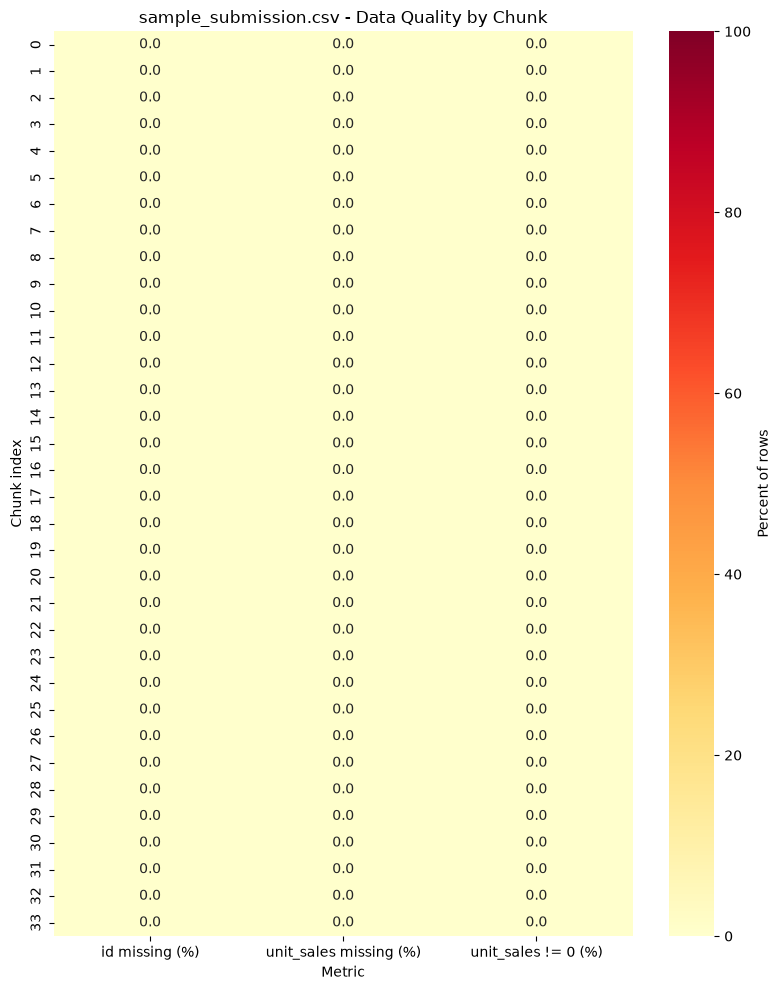

In [45]:
# Heatmap - sample_submission.csv: kiểm tra chất lượng dữ liệu theo từng chunk
# (file chỉ có id + unit_sales toàn 0 nên heatmap ở đây chủ yếu dùng để sanity check)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

chunk_size = 100_000
records = []

for i, chunk in enumerate(pd.read_csv(
    "../data/raw/sample_submission.csv",
    chunksize=chunk_size
)):
    records.append({
        "chunk": i,
        "id missing (%)": chunk["id"].isnull().mean() * 100,
        "unit_sales missing (%)": chunk["unit_sales"].isnull().mean() * 100,
        "unit_sales != 0 (%)": (chunk["unit_sales"].fillna(0) != 0).mean() * 100,
    })

df_quality = pd.DataFrame(records).set_index("chunk")

print(f"Number of chunks: {len(df_quality)}")

fig, ax = plt.subplots(figsize=(8, 10))

sns.heatmap(
    df_quality,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    vmin=0,
    vmax=100,                       # cố định 0–100% để nhìn ra bất thường
    cbar_kws={"label": "Percent of rows"},
    ax=ax
)

ax.set_title("sample_submission.csv - Data Quality by Chunk")
ax.set_xlabel("Metric")
ax.set_ylabel("Chunk index")

plt.tight_layout()
plt.show()

In [46]:
# Heatmap - sample_submission.csv: kiểm tra chất lượng dữ liệu theo từng chunk
# Đọc theo chunks và xuất thành Markdown table
# sample_submission.csv chỉ có id + unit_sales

import pandas as pd
from IPython.display import Markdown, display

chunk_size = 100_000
records = []

for i, chunk in enumerate(
    pd.read_csv(
        "../data/raw/sample_submission.csv",
        chunksize=chunk_size
    )
):
    records.append({
        "chunk": i,
        "id missing (%)": chunk["id"].isnull().mean() * 100,
        "unit_sales missing (%)": chunk["unit_sales"].isnull().mean() * 100,
        "unit_sales != 0 (%)": (
            chunk["unit_sales"].fillna(0) != 0
        ).mean() * 100,
    })

df_quality = pd.DataFrame(records).set_index("chunk")

print(f"Number of chunks: {len(df_quality):,}")

# Format phần trăm
df_quality_formatted = (
    df_quality
    .map(lambda x: f"{x:.1f}%")
    .reset_index()
    .rename(columns={"chunk": "Chunk"})
)

df_quality_formatted.columns.name = None

# Tạo Markdown table thủ công
headers = df_quality_formatted.columns.tolist()

md_lines = [
    "| " + " | ".join(map(str, headers)) + " |",
    "| " + " | ".join(["---"] * len(headers)) + " |"
]

for row in df_quality_formatted.itertuples(index=False, name=None):
    md_lines.append(
        "| " + " | ".join(map(str, row)) + " |"
    )

md_table = "\n".join(md_lines)

# Lưu file Markdown
output_path = "heatmap_sample_submission_quality.md"

with open(output_path, "w", encoding="utf-8") as f:
    f.write("# sample_submission.csv - Data Quality by Chunk\n\n")
    f.write(
        "- `id missing (%)`: tỷ lệ ID bị thiếu\n"
        "- `unit_sales missing (%)`: tỷ lệ target bị thiếu\n"
        "- `unit_sales != 0 (%)`: tỷ lệ giá trị unit_sales khác 0\n\n"
    )
    f.write(md_table)

print(f"Đã lưu bảng vào file: {output_path}")

# Hiển thị trong notebook
display(Markdown(md_table))

Number of chunks: 34
Đã lưu bảng vào file: heatmap_sample_submission_quality.md


| Chunk | id missing (%) | unit_sales missing (%) | unit_sales != 0 (%) |
| --- | --- | --- | --- |
| 0 | 0.0% | 0.0% | 0.0% |
| 1 | 0.0% | 0.0% | 0.0% |
| 2 | 0.0% | 0.0% | 0.0% |
| 3 | 0.0% | 0.0% | 0.0% |
| 4 | 0.0% | 0.0% | 0.0% |
| 5 | 0.0% | 0.0% | 0.0% |
| 6 | 0.0% | 0.0% | 0.0% |
| 7 | 0.0% | 0.0% | 0.0% |
| 8 | 0.0% | 0.0% | 0.0% |
| 9 | 0.0% | 0.0% | 0.0% |
| 10 | 0.0% | 0.0% | 0.0% |
| 11 | 0.0% | 0.0% | 0.0% |
| 12 | 0.0% | 0.0% | 0.0% |
| 13 | 0.0% | 0.0% | 0.0% |
| 14 | 0.0% | 0.0% | 0.0% |
| 15 | 0.0% | 0.0% | 0.0% |
| 16 | 0.0% | 0.0% | 0.0% |
| 17 | 0.0% | 0.0% | 0.0% |
| 18 | 0.0% | 0.0% | 0.0% |
| 19 | 0.0% | 0.0% | 0.0% |
| 20 | 0.0% | 0.0% | 0.0% |
| 21 | 0.0% | 0.0% | 0.0% |
| 22 | 0.0% | 0.0% | 0.0% |
| 23 | 0.0% | 0.0% | 0.0% |
| 24 | 0.0% | 0.0% | 0.0% |
| 25 | 0.0% | 0.0% | 0.0% |
| 26 | 0.0% | 0.0% | 0.0% |
| 27 | 0.0% | 0.0% | 0.0% |
| 28 | 0.0% | 0.0% | 0.0% |
| 29 | 0.0% | 0.0% | 0.0% |
| 30 | 0.0% | 0.0% | 0.0% |
| 31 | 0.0% | 0.0% | 0.0% |
| 32 | 0.0% | 0.0% | 0.0% |
| 33 | 0.0% | 0.0% | 0.0% |

## Test.csv

In [47]:
df = pd.read_csv("../data/raw/test.csv", nrows=5000)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (5000, 5)


,id,date,store_nbr,item_nbr,onpromotion
0,125497040,2017-08-16,1,96995,False
1,125497041,2017-08-16,1,99197,False
2,125497042,2017-08-16,1,103501,False
3,125497043,2017-08-16,1,103520,False
4,125497044,2017-08-16,1,103665,False


Number of dates: 16
Date range: 2017-08-16 → 2017-08-31


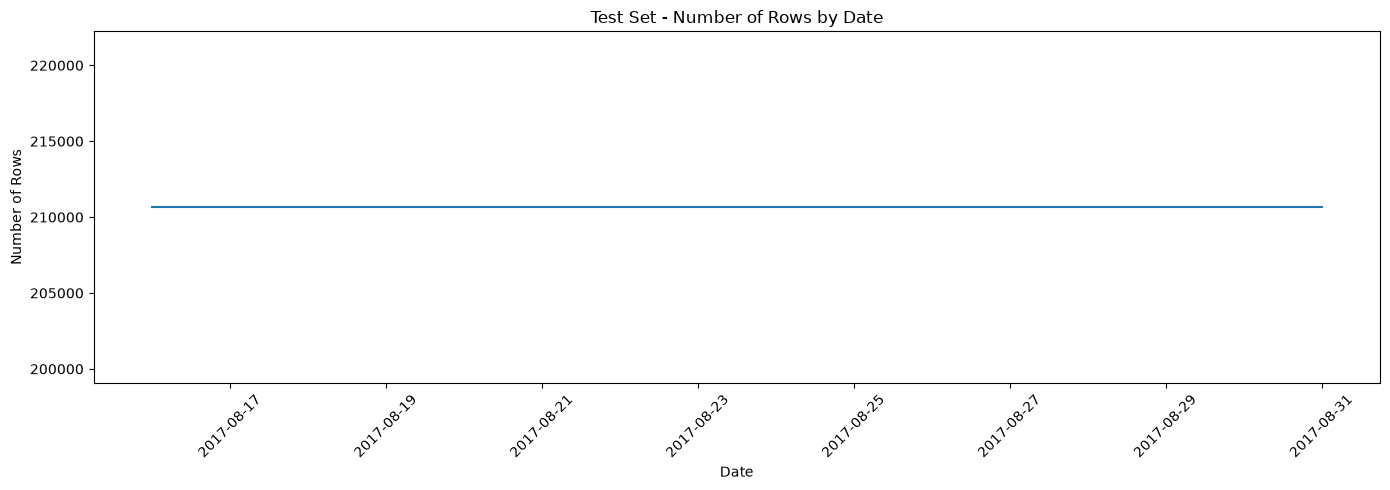

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

chunk_size = 100_000

daily_count = []

for chunk in pd.read_csv(
    "../data/raw/test.csv",
    usecols=["date"],
    chunksize=chunk_size
):
    chunk["date"] = pd.to_datetime(chunk["date"])

    chunk_daily = (
        chunk.groupby("date")
        .size()
        .reset_index(name="row_count")
    )

    daily_count.append(chunk_daily)

# Gộp kết quả từ các chunk
df_test_ts = (
    pd.concat(daily_count, ignore_index=True)
    .groupby("date", as_index=False)["row_count"]
    .sum()
    .sort_values("date")
)

print(f"Number of dates: {len(df_test_ts):,}")
print(
    f"Date range: "
    f"{df_test_ts['date'].min().date()} → "
    f"{df_test_ts['date'].max().date()}"
)

plt.figure(figsize=(14, 5))
plt.plot(df_test_ts["date"], df_test_ts["row_count"])

plt.title("Test Set - Number of Rows by Date")
plt.xlabel("Date")
plt.ylabel("Number of Rows")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

chunk_size = 100_000

columns = ["store_nbr", "item_nbr", "onpromotion"]

# Tìm min/max trên toàn bộ test.csv
min_values = {col: float("inf") for col in columns}
max_values = {col: float("-inf") for col in columns}

for chunk in pd.read_csv(
    "../data/raw/test.csv",
    usecols=columns,
    chunksize=chunk_size
):
    for col in columns:
        min_values[col] = min(min_values[col], chunk[col].min())
        max_values[col] = max(max_values[col], chunk[col].max())

print("Min / Max:")
for col in columns:
    print(f"{col}: {min_values[col]} → {max_values[col]}")

Min / Max:
store_nbr: 1 → 54
item_nbr: 96995 → 2134244
onpromotion: False → True


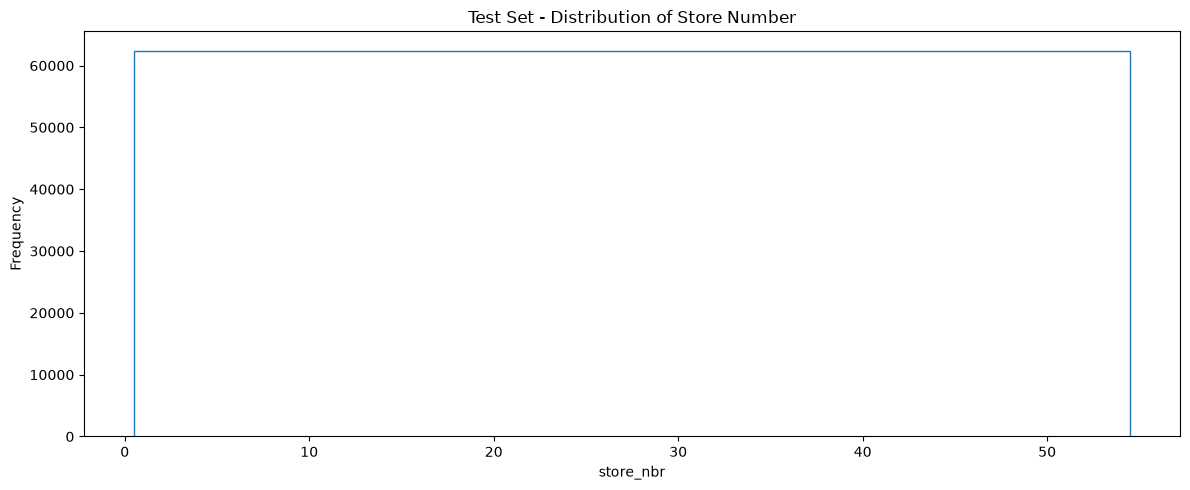

In [50]:
bins = int(max_values["store_nbr"] - min_values["store_nbr"] + 1)

hist_counts = np.zeros(bins, dtype=np.int64)

for chunk in pd.read_csv(
    "../data/raw/test.csv",
    usecols=["store_nbr"],
    chunksize=chunk_size
):
    values = chunk["store_nbr"].dropna()

    counts, _ = np.histogram(
        values,
        bins=np.arange(
            min_values["store_nbr"] - 0.5,
            max_values["store_nbr"] + 1.5,
            1
        )
    )

    hist_counts += counts

bin_edges = np.arange(
    min_values["store_nbr"] - 0.5,
    max_values["store_nbr"] + 1.5,
    1
)

plt.figure(figsize=(12, 5))
plt.stairs(hist_counts, bin_edges)

plt.title("Test Set - Distribution of Store Number")
plt.xlabel("store_nbr")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

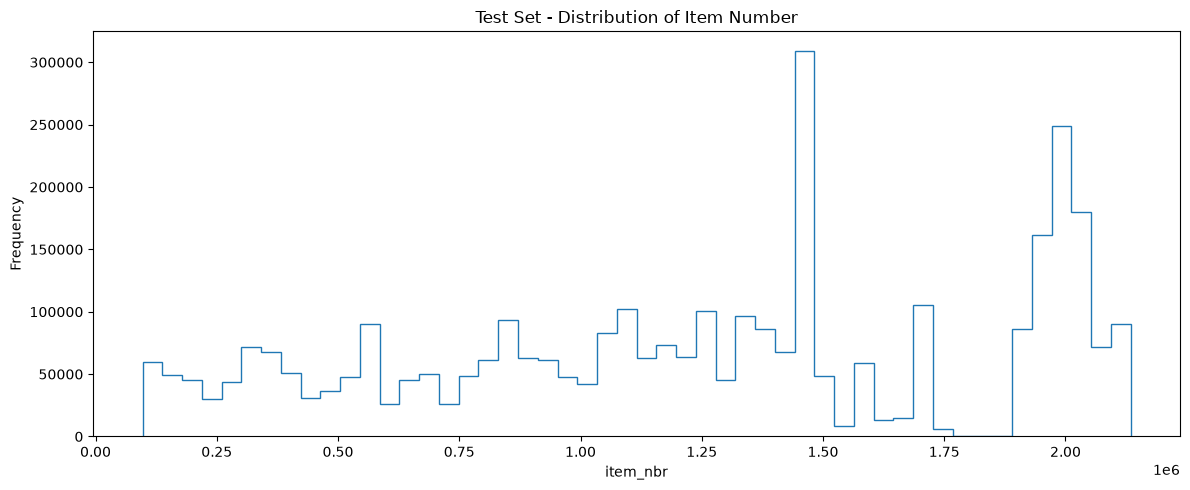

In [51]:
bins = 50

bin_edges = np.linspace(
    min_values["item_nbr"],
    max_values["item_nbr"],
    bins + 1
)

hist_counts = np.zeros(bins, dtype=np.int64)

for chunk in pd.read_csv(
    "../data/raw/test.csv",
    usecols=["item_nbr"],
    chunksize=chunk_size
):
    values = chunk["item_nbr"].dropna()

    counts, _ = np.histogram(
        values,
        bins=bin_edges
    )

    hist_counts += counts

plt.figure(figsize=(12, 5))
plt.stairs(hist_counts, bin_edges)

plt.title("Test Set - Distribution of Item Number")
plt.xlabel("item_nbr")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

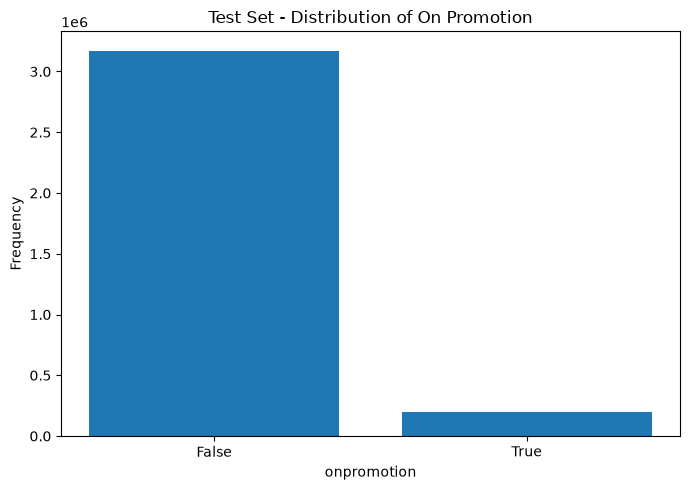

In [52]:
promotion_counts = pd.Series(dtype="int64")

for chunk in pd.read_csv(
    "../data/raw/test.csv",
    usecols=["onpromotion"],
    chunksize=chunk_size
):
    counts = chunk["onpromotion"].value_counts(dropna=False)
    promotion_counts = promotion_counts.add(counts, fill_value=0)

promotion_counts = promotion_counts.sort_index()

plt.figure(figsize=(7, 5))
plt.bar(
    promotion_counts.index.astype(str),
    promotion_counts.values
)

plt.title("Test Set - Distribution of On Promotion")
plt.xlabel("onpromotion")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [53]:
import pandas as pd

chunk_size = 100_000

missing_count = None
total_rows = 0

for chunk in pd.read_csv(
    "../data/raw/test.csv",
    usecols=["store_nbr", "item_nbr", "date", "onpromotion"],
    chunksize=chunk_size
):
    chunk_missing = chunk.isnull().sum()

    if missing_count is None:
        missing_count = chunk_missing
    else:
        missing_count += chunk_missing

    total_rows += len(chunk)

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": (
        missing_count / total_rows * 100
    ).round(2)
})

print(f"Total rows: {total_rows:,}")

display(missing_summary)

Total rows: 3,370,464


,missing_count,missing_percent
date,0,0.0
store_nbr,0,0.0
item_nbr,0,0.0
onpromotion,0,0.0


In [54]:
chunk_size = 100_000

series_set = set()

for chunk in pd.read_csv(
    "../data/raw/test.csv",
    usecols=["store_nbr", "item_nbr"],
    chunksize=chunk_size
):
    series_set.update(
        zip(chunk["store_nbr"], chunk["item_nbr"])
    )

print(f"Unique store-item series in test: {len(series_set):,}")

Unique store-item series in test: 210,654


Heatmap shape (stores × dates): (54, 16)
Tổng số dòng: 3,370,464


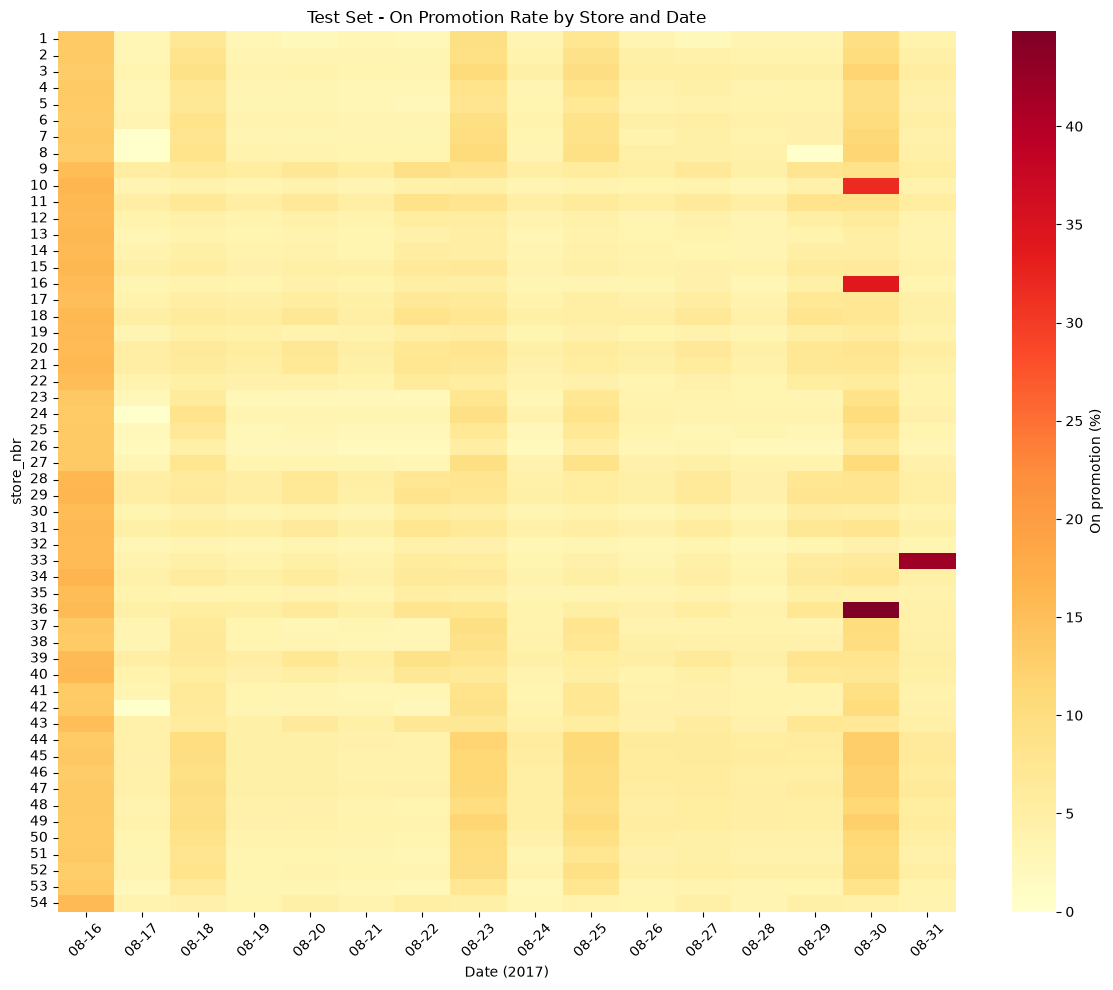

In [55]:
# Heatmap - test.csv: tỷ lệ onpromotion (%) theo store_nbr × ngày
# Đọc theo chunks; rate = tổng True / tổng số dòng

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

chunk_size = 100_000
partials = []

for chunk in pd.read_csv(
    "../data/raw/test.csv",
    usecols=["date", "store_nbr", "onpromotion"],
    chunksize=chunk_size
):
    chunk["onpromotion"] = chunk["onpromotion"].astype(int)

    partials.append(
        chunk.groupby(["store_nbr", "date"])["onpromotion"]
             .agg(["sum", "count"])
    )

promo = pd.concat(partials).groupby(level=[0, 1]).sum()
promo["promo_rate"] = promo["sum"] / promo["count"] * 100

heat_test = promo["promo_rate"].unstack("date")
heat_test.columns = [d[5:] for d in heat_test.columns]     # "2017-08-16" -> "08-16"

print(f"Heatmap shape (stores × dates): {heat_test.shape}")
print(f"Tổng số dòng: {int(promo['count'].sum()):,}")

fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(
    heat_test,
    cmap="YlOrRd",
    cbar_kws={"label": "On promotion (%)"},
    ax=ax
)

ax.set_title("Test Set - On Promotion Rate by Store and Date")
ax.set_xlabel("Date (2017)")
ax.set_ylabel("store_nbr")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [56]:
# Heatmap - test.csv: tỷ lệ onpromotion (%) theo store_nbr × ngày
# Đọc theo chunks; rate = tổng True / tổng số dòng

import pandas as pd
from IPython.display import Markdown, display

chunk_size = 100_000
partials = []

for chunk in pd.read_csv(
    "../data/raw/test.csv",
    usecols=["date", "store_nbr", "onpromotion"],
    chunksize=chunk_size
):
    # Đảm bảo onpromotion được xử lý như biến nhị phân
    chunk["onpromotion"] = chunk["onpromotion"].astype(int)

    partial = (
        chunk
        .groupby(["store_nbr", "date"])["onpromotion"]
        .agg(["sum", "count"])
        .reset_index()
    )

    partials.append(partial)

# Gộp kết quả từ các chunks
promo = (
    pd.concat(partials, ignore_index=True)
      .groupby(["store_nbr", "date"], as_index=False)[["sum", "count"]]
      .sum()
)

# Tính tỷ lệ promotion (%)
promo["promo_rate"] = (
    promo["sum"] / promo["count"] * 100
)

# Pivot: Store × Date
heat_test = (
    promo
    .pivot(index="store_nbr", columns="date", values="promo_rate")
    .sort_index()
)

# Đổi tên ngày: 2017-08-16 → 08-16
heat_test.columns = [
    str(d)[5:] for d in heat_test.columns
]

print(f"Heatmap shape (stores × dates): {heat_test.shape}")
print(f"Tổng số dòng: {int(promo['count'].sum()):,}")

# Format %
heat_test_formatted = (
    heat_test
    .map(lambda x: f"{x:.1f}%" if pd.notnull(x) else "-")
    .reset_index()
    .rename(columns={"store_nbr": "Store"})
)

heat_test_formatted.columns.name = None

# Tạo Markdown table thủ công
headers = heat_test_formatted.columns.tolist()

md_lines = [
    "| " + " | ".join(map(str, headers)) + " |",
    "| " + " | ".join(["---"] * len(headers)) + " |"
]

for row in heat_test_formatted.itertuples(index=False, name=None):
    md_lines.append(
        "| " + " | ".join(map(str, row)) + " |"
    )

md_table = "\n".join(md_lines)

# Lưu file Markdown
output_path = "heatmap_test_onpromotion_store_date.md"

with open(output_path, "w", encoding="utf-8") as f:
    f.write("# Test Set - On Promotion Rate by Store and Date\n\n")
    f.write(
        "- **Metric:** On-promotion rate (%)\n"
        "- **Rows:** Store\n"
        "- **Columns:** Date\n"
        "- **Aggregation:** Sum of `onpromotion` / total rows × 100\n\n"
    )
    f.write(md_table)

print(f"Đã lưu bảng vào file: {output_path}")

# Hiển thị trong notebook
display(Markdown(md_table))

Heatmap shape (stores × dates): (54, 16)
Tổng số dòng: 3,370,464
Đã lưu bảng vào file: heatmap_test_onpromotion_store_date.md


| Store | 08-16 | 08-17 | 08-18 | 08-19 | 08-20 | 08-21 | 08-22 | 08-23 | 08-24 | 08-25 | 08-26 | 08-27 | 08-28 | 08-29 | 08-30 | 08-31 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 1 | 13.4% | 2.9% | 7.1% | 3.1% | 2.3% | 3.0% | 2.6% | 9.3% | 3.3% | 7.5% | 3.4% | 2.3% | 3.3% | 3.4% | 9.5% | 4.0% |
| 2 | 13.5% | 3.1% | 8.2% | 3.5% | 3.5% | 3.5% | 3.2% | 9.2% | 4.0% | 8.7% | 4.8% | 4.5% | 3.9% | 4.0% | 10.2% | 4.7% |
| 3 | 13.1% | 3.6% | 8.9% | 3.8% | 3.9% | 3.5% | 3.4% | 10.7% | 4.7% | 9.8% | 5.0% | 5.2% | 4.7% | 4.8% | 11.8% | 5.6% |
| 4 | 13.4% | 2.9% | 7.5% | 3.3% | 3.2% | 3.1% | 2.9% | 8.3% | 3.4% | 8.4% | 4.2% | 4.6% | 3.7% | 4.0% | 9.5% | 4.8% |
| 5 | 13.2% | 2.9% | 7.0% | 3.3% | 3.3% | 3.1% | 2.6% | 7.8% | 3.6% | 6.9% | 3.8% | 4.1% | 4.0% | 3.9% | 9.5% | 4.3% |
| 6 | 13.0% | 3.4% | 8.3% | 3.7% | 3.8% | 3.5% | 3.3% | 9.3% | 3.9% | 8.5% | 4.9% | 5.2% | 4.5% | 4.4% | 10.2% | 5.1% |
| 7 | 13.5% | 0.0% | 7.7% | 3.4% | 3.2% | 3.3% | 3.2% | 9.9% | 3.6% | 8.5% | 3.9% | 4.6% | 4.0% | 4.4% | 11.2% | 4.5% |
| 8 | 13.1% | 0.0% | 8.3% | 3.9% | 3.7% | 3.5% | 3.6% | 10.5% | 3.4% | 9.2% | 4.7% | 4.8% | 4.4% | 0.0% | 11.5% | 4.8% |
| 9 | 15.4% | 5.4% | 6.6% | 5.6% | 7.2% | 5.6% | 8.9% | 8.1% | 5.0% | 6.0% | 5.2% | 6.7% | 4.7% | 7.9% | 8.5% | 5.7% |
| 10 | 16.1% | 3.3% | 4.1% | 3.6% | 4.1% | 3.4% | 4.5% | 4.6% | 3.4% | 3.9% | 3.5% | 3.9% | 3.1% | 4.4% | 31.7% | 4.1% |
| 11 | 15.9% | 5.3% | 6.9% | 5.3% | 6.7% | 5.1% | 8.4% | 7.8% | 4.9% | 6.3% | 4.9% | 6.5% | 5.0% | 8.2% | 8.1% | 5.8% |
| 12 | 15.6% | 4.0% | 4.5% | 4.0% | 4.5% | 3.9% | 5.8% | 5.5% | 3.7% | 4.4% | 3.5% | 4.3% | 3.3% | 5.2% | 6.2% | 4.0% |
| 13 | 16.0% | 3.1% | 4.0% | 3.6% | 3.8% | 3.6% | 4.4% | 5.4% | 3.0% | 4.1% | 3.6% | 3.9% | 3.4% | 4.0% | 5.2% | 3.8% |
| 14 | 15.7% | 3.7% | 4.7% | 4.0% | 4.1% | 3.7% | 5.4% | 5.3% | 3.4% | 4.5% | 3.9% | 3.6% | 3.4% | 5.0% | 5.4% | 3.9% |
| 15 | 16.1% | 4.7% | 5.8% | 4.2% | 4.7% | 4.6% | 6.3% | 6.8% | 3.8% | 4.6% | 4.1% | 4.3% | 4.1% | 6.2% | 6.4% | 4.5% |
| 16 | 15.5% | 3.2% | 3.9% | 3.5% | 4.3% | 3.9% | 5.1% | 5.0% | 3.2% | 3.4% | 3.2% | 4.3% | 2.9% | 4.9% | 34.0% | 3.7% |
| 17 | 15.2% | 4.0% | 5.4% | 4.6% | 5.6% | 4.6% | 6.8% | 6.6% | 4.0% | 5.2% | 4.3% | 5.5% | 3.7% | 6.9% | 7.0% | 4.9% |
| 18 | 15.8% | 5.1% | 6.3% | 5.7% | 7.1% | 5.1% | 8.4% | 7.4% | 4.6% | 5.2% | 5.1% | 6.7% | 4.4% | 8.0% | 7.4% | 4.8% |
| 19 | 15.6% | 3.3% | 4.6% | 4.4% | 3.9% | 4.1% | 5.2% | 5.5% | 3.3% | 4.3% | 3.6% | 4.1% | 3.4% | 5.2% | 5.9% | 4.1% |
| 20 | 15.6% | 5.3% | 6.4% | 5.6% | 7.2% | 5.2% | 7.4% | 7.9% | 4.7% | 6.0% | 4.9% | 6.7% | 4.7% | 7.3% | 7.8% | 5.5% |
| 21 | 15.8% | 5.4% | 6.2% | 5.2% | 6.9% | 4.7% | 7.6% | 7.2% | 4.2% | 5.7% | 4.8% | 6.0% | 4.4% | 7.2% | 7.3% | 4.8% |
| 22 | 15.4% | 3.7% | 4.8% | 4.3% | 4.4% | 4.0% | 6.2% | 5.5% | 3.7% | 4.2% | 3.7% | 4.2% | 3.6% | 5.7% | 6.1% | 4.0% |
| 23 | 13.6% | 2.6% | 6.2% | 2.7% | 2.8% | 2.5% | 2.4% | 7.6% | 3.1% | 7.3% | 3.8% | 3.9% | 3.6% | 3.4% | 8.6% | 4.0% |
| 24 | 13.3% | 0.0% | 8.2% | 3.4% | 3.4% | 3.3% | 3.3% | 9.1% | 3.7% | 8.4% | 4.1% | 3.8% | 3.7% | 3.7% | 10.1% | 4.4% |
| 25 | 13.3% | 2.4% | 6.8% | 2.7% | 2.9% | 2.6% | 2.6% | 7.0% | 2.6% | 7.0% | 3.5% | 3.1% | 3.3% | 3.1% | 8.3% | 3.6% |
| 26 | 13.4% | 1.9% | 4.8% | 2.5% | 2.5% | 1.9% | 2.0% | 5.3% | 2.1% | 5.4% | 3.1% | 3.2% | 2.4% | 2.4% | 6.3% | 3.0% |
| 27 | 13.4% | 2.9% | 7.6% | 3.5% | 3.7% | 3.2% | 2.8% | 9.4% | 3.7% | 8.5% | 4.3% | 4.7% | 3.9% | 4.0% | 10.4% | 4.2% |
| 28 | 16.1% | 5.3% | 6.3% | 5.4% | 6.8% | 5.0% | 7.3% | 7.7% | 4.4% | 5.6% | 4.7% | 6.4% | 4.3% | 7.3% | 7.9% | 5.1% |
| 29 | 16.2% | 5.3% | 6.4% | 5.3% | 6.8% | 4.9% | 8.2% | 7.4% | 4.6% | 5.6% | 4.7% | 6.5% | 4.3% | 7.8% | 7.8% | 5.0% |
| 30 | 15.4% | 3.6% | 4.2% | 3.5% | 3.9% | 3.2% | 5.7% | 5.0% | 3.2% | 3.9% | 2.8% | 4.1% | 2.9% | 5.5% | 5.1% | 3.9% |
| 31 | 15.6% | 4.7% | 5.6% | 5.2% | 6.3% | 4.6% | 7.5% | 6.6% | 4.5% | 5.3% | 4.3% | 5.9% | 4.1% | 7.1% | 7.9% | 4.8% |
| 32 | 15.5% | 3.0% | 3.4% | 3.1% | 3.6% | 2.9% | 4.5% | 4.4% | 3.0% | 3.3% | 3.1% | 3.7% | 2.7% | 3.6% | 4.2% | 3.3% |
| 33 | 15.5% | 3.7% | 4.8% | 4.0% | 4.6% | 3.9% | 6.0% | 5.7% | 3.6% | 4.3% | 3.5% | 4.6% | 3.6% | 5.8% | 6.4% | 42.0% |
| 34 | 16.4% | 4.5% | 5.9% | 4.6% | 6.1% | 4.5% | 6.5% | 6.5% | 4.2% | 5.1% | 4.1% | 5.3% | 3.9% | 6.5% | 7.2% | 4.6% |
| 35 | 15.3% | 3.9% | 3.7% | 3.6% | 3.7% | 3.5% | 5.3% | 4.8% | 3.4% | 3.3% | 3.4% | 3.8% | 2.8% | 4.8% | 4.5% | 4.1% |
| 36 | 15.6% | 4.7% | 5.7% | 5.2% | 6.5% | 4.7% | 8.0% | 7.5% | 4.0% | 5.1% | 4.4% | 5.7% | 4.1% | 7.2% | 44.8% | 4.4% |
| 37 | 13.6% | 3.4% | 6.6% | 3.5% | 3.1% | 3.2% | 3.1% | 9.4% | 3.9% | 7.8% | 3.8% | 3.9% | 3.9% | 3.8% | 10.3% | 4.5% |
| 38 | 13.2% | 3.2% | 6.7% | 3.5% | 3.4% | 3.1% | 3.1% | 8.6% | 4.1% | 7.2% | 4.7% | 4.5% | 4.5% | 4.3% | 9.8% | 4.6% |
| 39 | 15.7% | 5.3% | 6.3% | 5.4% | 7.2% | 5.2% | 8.8% | 7.9% | 4.6% | 5.6% | 4.9% | 6.6% | 4.7% | 7.9% | 7.7% | 5.1% |
| 40 | 15.8% | 3.9% | 5.7% | 4.3% | 5.1% | 4.5% | 7.0% | 6.5% | 3.8% | 5.0% | 3.9% | 4.8% | 3.7% | 6.8% | 7.1% | 4.6% |
| 41 | 13.2% | 3.2% | 6.6% | 3.5% | 3.4% | 3.1% | 2.9% | 8.4% | 3.7% | 7.2% | 4.2% | 4.3% | 3.9% | 3.9% | 9.2% | 4.1% |
| 42 | 13.3% | 0.0% | 6.3% | 3.2% | 3.4% | 3.2% | 2.6% | 8.7% | 3.7% | 7.4% | 4.2% | 4.2% | 3.9% | 3.7% | 10.3% | 4.3% |
| 43 | 15.0% | 4.4% | 5.9% | 4.8% | 6.3% | 4.6% | 7.2% | 7.2% | 4.4% | 5.7% | 4.3% | 5.9% | 4.2% | 7.3% | 6.8% | 4.7% |
| 44 | 13.3% | 4.5% | 9.8% | 4.9% | 4.7% | 4.3% | 4.2% | 11.8% | 5.9% | 11.0% | 6.2% | 6.3% | 5.8% | 5.8% | 12.9% | 6.5% |
| 45 | 13.5% | 4.2% | 9.6% | 4.7% | 4.7% | 4.2% | 4.1% | 11.4% | 5.5% | 10.7% | 6.1% | 6.2% | 5.8% | 5.7% | 12.8% | 6.5% |
| 46 | 13.1% | 4.4% | 9.1% | 4.7% | 4.8% | 4.1% | 4.2% | 11.3% | 5.0% | 10.0% | 6.0% | 6.1% | 5.0% | 5.0% | 12.1% | 6.1% |
| 47 | 13.4% | 4.4% | 9.7% | 4.8% | 4.7% | 4.5% | 4.3% | 11.1% | 5.2% | 10.0% | 5.5% | 5.9% | 5.3% | 5.9% | 12.2% | 6.5% |
| 48 | 13.4% | 3.8% | 9.0% | 4.4% | 4.3% | 3.8% | 3.6% | 9.8% | 5.2% | 9.5% | 5.4% | 5.7% | 5.3% | 5.0% | 11.4% | 5.8% |
| 49 | 13.2% | 4.1% | 9.3% | 4.3% | 4.5% | 3.9% | 3.8% | 11.6% | 4.9% | 10.6% | 5.6% | 5.6% | 5.4% | 5.2% | 12.5% | 6.0% |
| 50 | 13.2% | 3.7% | 8.4% | 3.9% | 3.9% | 3.7% | 3.7% | 10.3% | 4.3% | 9.2% | 4.9% | 4.9% | 4.5% | 4.4% | 11.3% | 5.1% |
| 51 | 13.4% | 3.2% | 7.9% | 3.6% | 3.7% | 3.3% | 3.1% | 9.9% | 3.2% | 7.5% | 4.3% | 4.9% | 4.2% | 4.1% | 10.7% | 4.5% |
| 52 | 12.8% | 3.4% | 8.3% | 3.7% | 3.7% | 3.5% | 3.3% | 9.6% | 3.8% | 9.3% | 4.8% | 4.9% | 4.6% | 4.6% | 10.8% | 5.2% |
| 53 | 13.3% | 2.6% | 6.4% | 3.2% | 3.2% | 3.1% | 2.7% | 7.5% | 2.8% | 7.6% | 3.5% | 3.8% | 3.4% | 3.5% | 8.4% | 3.9% |
| 54 | 15.7% | 3.7% | 4.4% | 3.6% | 4.8% | 3.8% | 5.0% | 4.6% | 3.0% | 3.8% | 3.5% | 4.7% | 3.5% | 4.7% | 4.5% | 3.7% |

## Bổ sung phân tích quan hệ cho Tuần 3

**Yêu cầu (theo mục 5, Hướng dẫn ML - Tuần 3):** 
Cần bổ sung 6-8 biểu đồ phân tích quan hệ: 
- Tổng sales 
- Zero/negative rate 
- Promo effect 
- Weekday 
- Store/family 
- Holiday

**Mục tiêu:** Rút ra 3 phát hiện có bằng chứng. Không kết luận nhân quả từ biểu đồ; chỉ nêu quan sát và giả thuyết.

### 3.1 Nạp dữ liệu Interim cho EDA Tuần 3
Thay vì quét file gốc 4.7 GB, ta sẽ dùng các bảng profile đã được tổng hợp từ `checking_stage.ipynb`.

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

# 1. Đọc daily profile
df_daily = pd.read_csv('../data/interim/train_daily_profile.csv')
df_daily['date'] = pd.to_datetime(df_daily['date'])
df_daily = df_daily.set_index('date')

# 2. Đọc series profile (cho Store/Family)
df_series = pd.read_csv('../data/interim/train_series_profile.csv')

# 3. Đọc các bảng phụ
df_items = pd.read_csv('../data/raw/items.csv')
df_stores = pd.read_csv('../data/raw/stores.csv')
df_holidays = pd.read_csv('../data/raw/holidays_events.csv')
df_holidays['date'] = pd.to_datetime(df_holidays['date'])

display(df_daily.head(3))
display(df_series.head(3))

,n_rows,n_stores,n_items,sales_sum,n_negative,n_promo_nan,n_promo_true
date,,,,,,,
2013-01-01,578,1,578,2511.619,0,0,0
2013-01-02,41676,46,1583,496092.400,1,0,0
2013-01-03,40100,46,1586,361429.220,5,0,0


,store_nbr,item_nbr,first_date,last_date,n_days
0,1,96995,2013-01-10,2017-08-10,187
1,1,99197,2014-08-20,2017-08-09,185
2,1,103520,2013-01-04,2017-08-13,1119


### 3.2 Biểu đồ 1: Tổng Sales theo thời gian (Total Sales)

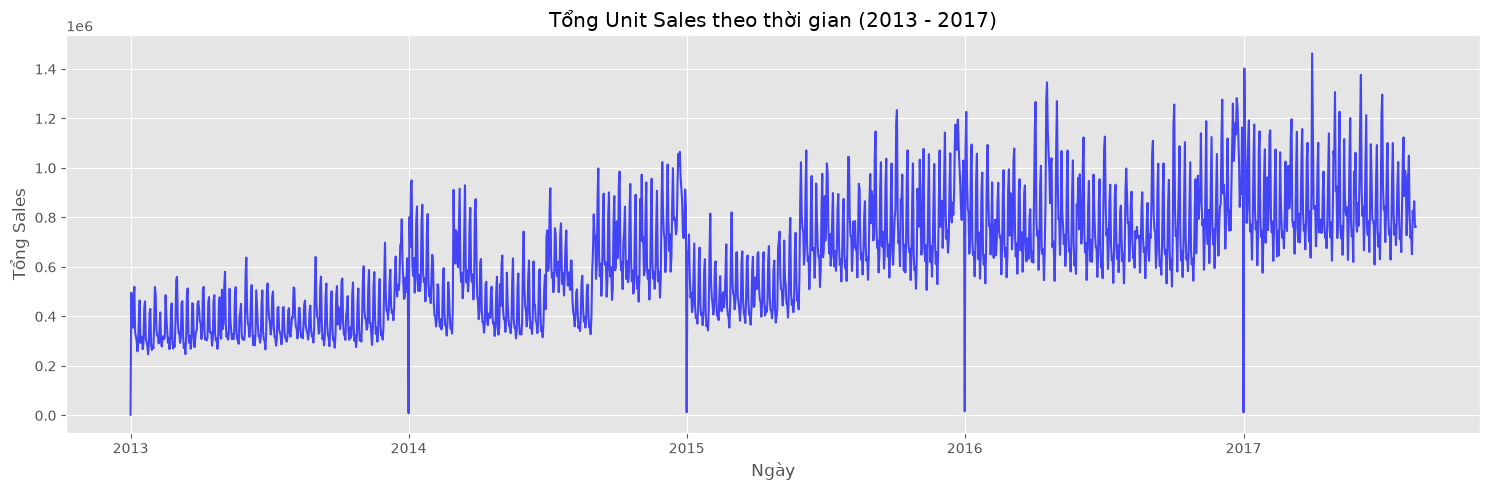

In [58]:
plt.figure(figsize=(15, 5))
plt.plot(df_daily.index, df_daily['sales_sum'], color='blue', alpha=0.7)
plt.title('Tổng Unit Sales theo thời gian (2013 - 2017)')
plt.xlabel('Ngày')
plt.ylabel('Tổng Sales')
plt.tight_layout()
plt.show()

### 3.3 Biểu đồ 2: Tỷ lệ Negative / Zero theo thời gian

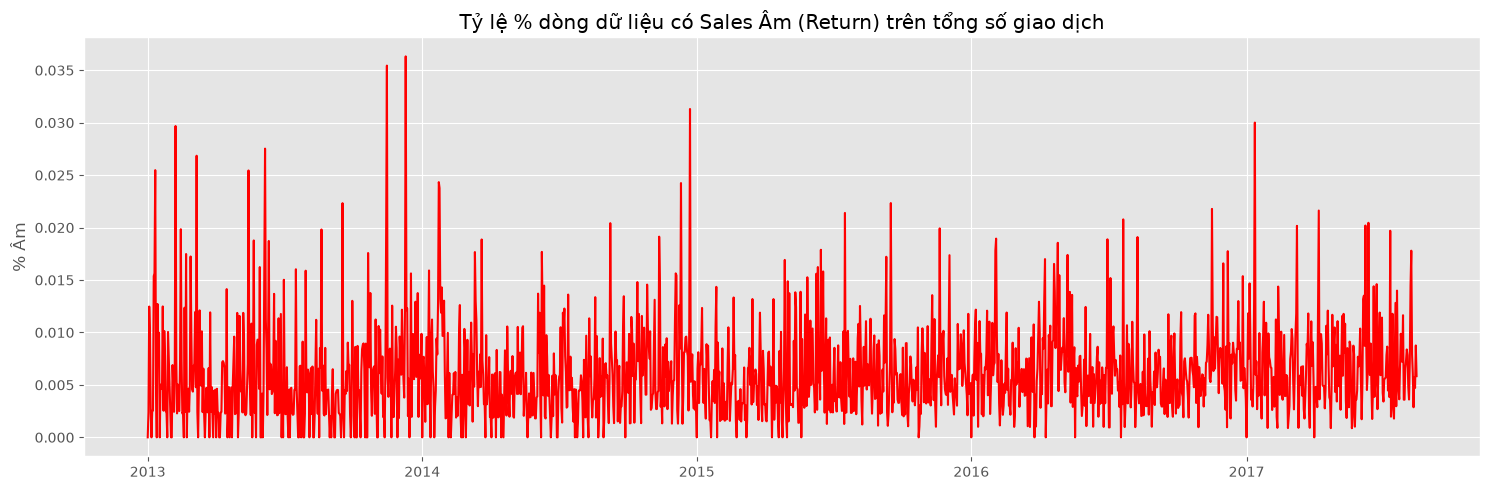

In [59]:
df_daily['negative_rate'] = df_daily['n_negative'] / df_daily['n_rows'] * 100

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df_daily.index, df_daily['negative_rate'], color='red')
ax.set_title('Tỷ lệ % dòng dữ liệu có Sales Âm (Return) trên tổng số giao dịch')
ax.set_ylabel('% Âm')
plt.tight_layout()
plt.show()

### 3.4 Biểu đồ 3: Hiệu ứng Khuyến mãi (Promo Effect)

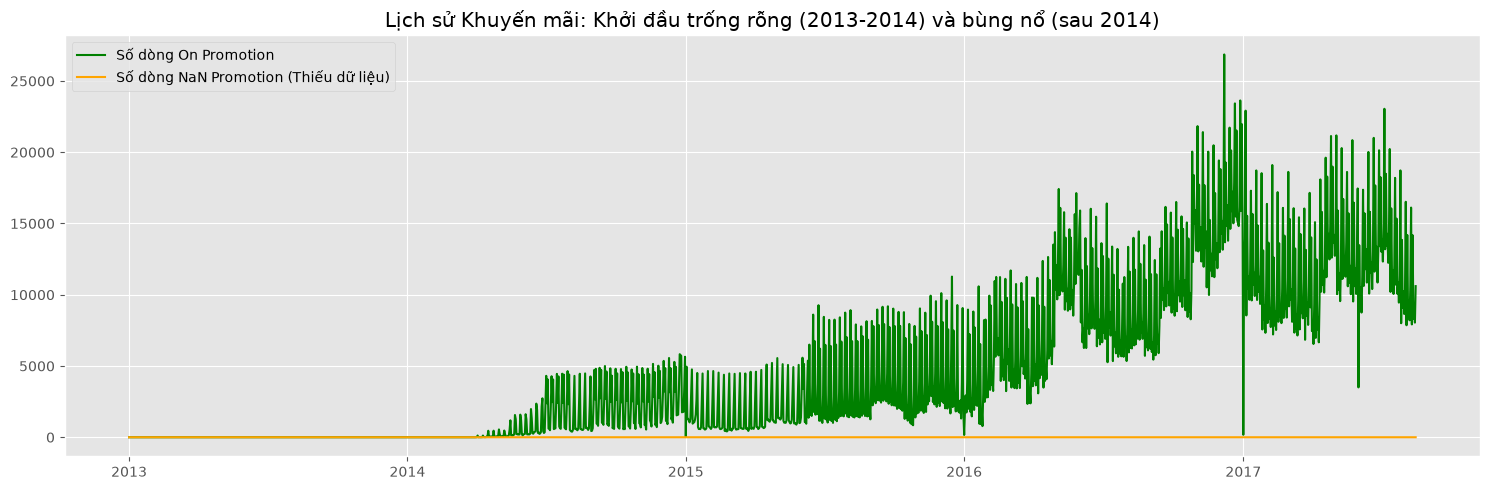

In [60]:
# Xem sự gia tăng của số dòng có promo=True theo thời gian
plt.figure(figsize=(15, 5))
plt.plot(df_daily.index, df_daily['n_promo_true'], color='green', label='Số dòng On Promotion')
plt.plot(df_daily.index, df_daily['n_promo_nan'], color='orange', label='Số dòng NaN Promotion (Thiếu dữ liệu)')
plt.title('Lịch sử Khuyến mãi: Khởi đầu trống rỗng (2013-2014) và bùng nổ (sau 2014)')
plt.legend()
plt.tight_layout()
plt.show()

### 3.5 Biểu đồ 4: Hiệu ứng Thứ trong tuần (Weekday Pattern)

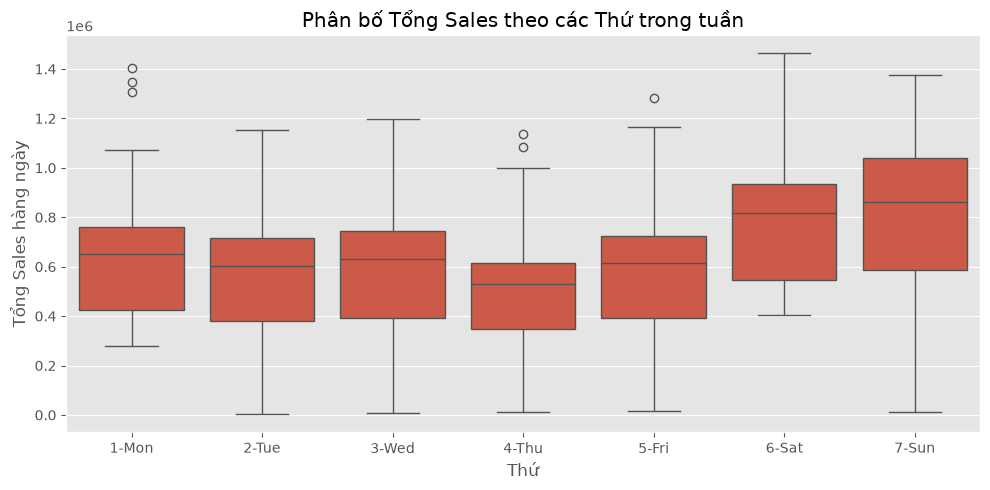

In [61]:
df_daily['weekday'] = df_daily.index.dayofweek # 0=Mon, 6=Sun
weekday_map = {0: '1-Mon', 1: '2-Tue', 2: '3-Wed', 3: '4-Thu', 4: '5-Fri', 5: '6-Sat', 6: '7-Sun'}
df_daily['weekday_name'] = df_daily['weekday'].map(weekday_map)

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_daily, x='weekday_name', y='sales_sum', order=sorted(weekday_map.values()))
plt.title('Phân bố Tổng Sales theo các Thứ trong tuần')
plt.ylabel('Tổng Sales hàng ngày')
plt.xlabel('Thứ')
plt.tight_layout()
plt.show()

### 3.6 Biểu đồ 5: Tổng Sales theo Store & Family

Đang tổng hợp doanh số từ Parquet...


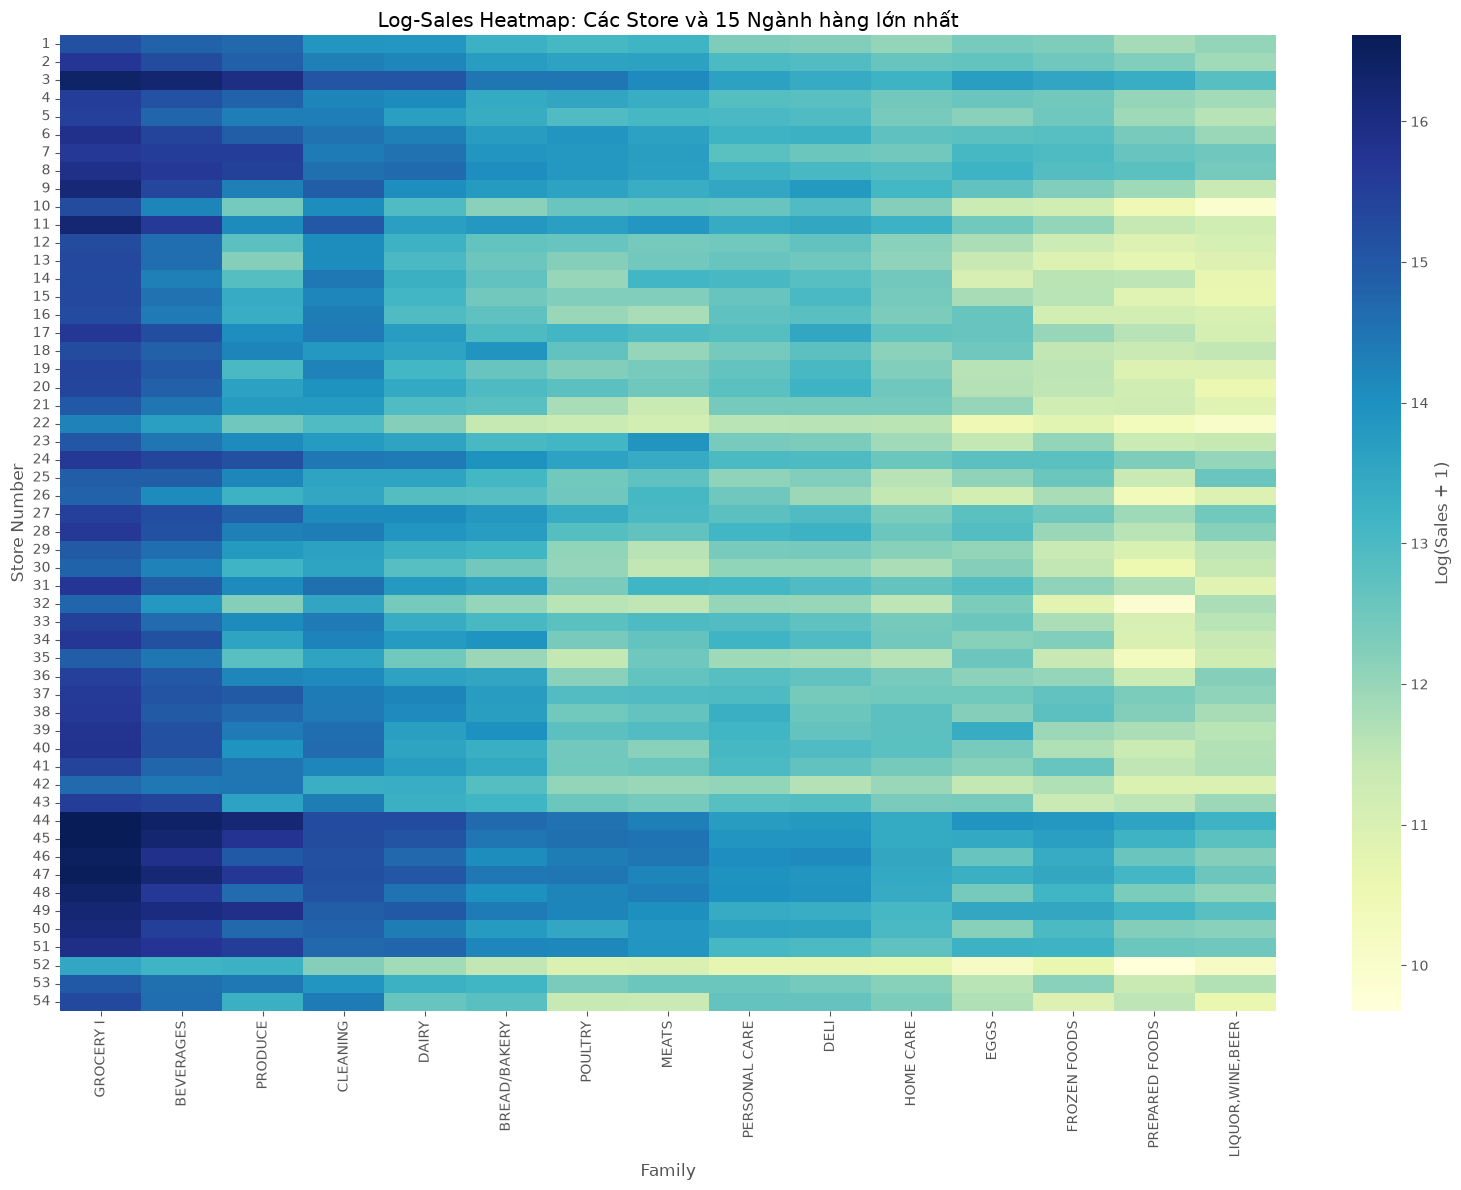

In [62]:
import pyarrow.parquet as pq
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Vì df_series hiện tại không chứa tổng sales, ta sẽ đọc từ train.parquet
# Sử dụng iter_batches để tránh tràn RAM (chỉ quét qua 1 lần rồi cộng dồn)
print("Đang tổng hợp doanh số từ Parquet...")
store_item_sales = {}
for batch in pq.ParquetFile("../data/processed/train.parquet").iter_batches(batch_size=2_000_000, columns=["store_nbr", "item_nbr", "unit_sales"]):
    df_batch = batch.to_pandas()
    # Cộng dồn doanh số cho từng (store_nbr, item_nbr)
    grouped = df_batch.groupby(["store_nbr", "item_nbr"])["unit_sales"].sum()
    for (store, item), sales in grouped.items():
        store_item_sales[(store, item)] = store_item_sales.get((store, item), 0) + sales

# Chuyển đổi kết quả đếm thành DataFrame
df_store_item = pd.DataFrame(
    [(store, item, sales) for (store, item), sales in store_item_sales.items()],
    columns=["store_nbr", "item_nbr", "sales_sum"]
)

# Kết hợp với bảng items.csv để lấy tên ngành hàng (family)
df_store_item = df_store_item.merge(df_items[["item_nbr", "family"]], on="item_nbr", how="left")

# Tính tổng doanh số và reshape thành ma trận Heatmap Store vs Top 15 Family
store_family_sales = df_store_item.groupby(["store_nbr", "family"])["sales_sum"].sum().unstack()
top_families = store_family_sales.sum().sort_values(ascending=False).head(15).index
heatmap_data = store_family_sales[top_families]

# Vẽ biểu đồ
plt.figure(figsize=(16, 12))
sns.heatmap(np.log1p(heatmap_data), cmap="YlGnBu", cbar_kws={"label": "Log(Sales + 1)"})
plt.title("Log-Sales Heatmap: Các Store và 15 Ngành hàng lớn nhất")
plt.ylabel("Store Number")
plt.xlabel("Family")
plt.tight_layout()
plt.show()


### 3.7 Biểu đồ 6: Tác động của Ngày Lễ (Holidays)

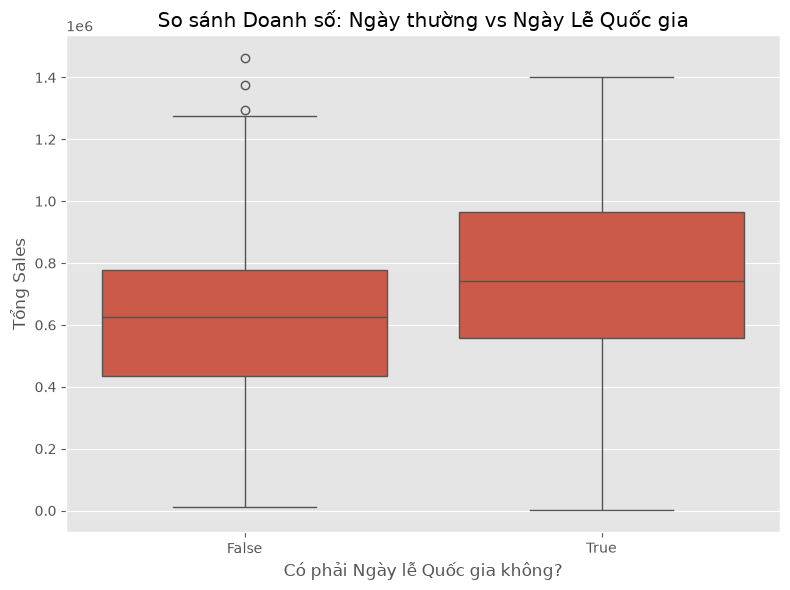

In [63]:
# Lọc ngày lễ Quốc gia (National) và không phải ngày chuyển đổi (transferred)
national_holidays = df_holidays[
    (df_holidays['locale'] == 'National') & 
    (df_holidays['transferred'] == False)
    # Note: thực tế phức tạp hơn (Transfer, Bridge, Work Day), ở đây làm minh họa cơ bản
]['date'].dt.date.unique()

df_daily['is_national_holiday'] = df_daily.index.date
df_daily['is_national_holiday'] = df_daily['is_national_holiday'].isin(national_holidays)

plt.figure(figsize=(8, 6))
sns.boxplot(data=df_daily, x='is_national_holiday', y='sales_sum')
plt.title('So sánh Doanh số: Ngày thường vs Ngày Lễ Quốc gia')
plt.ylabel('Tổng Sales')
plt.xlabel('Có phải Ngày lễ Quốc gia không?')
plt.tight_layout()
plt.show()